In [ ]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU: Tesla T4


In [ ]:
import os
os.chdir('/content')
!git clone https://github.com/TrustMedia-zju/Lastde_Detector.git
os.chdir('Lastde_Detector')
print("Cloned and moved into Lastde_Detector")

Cloning into 'Lastde_Detector'...
remote: Enumerating objects: 318, done.
remote: Counting objects: 100% (318/318), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 318 (delta 186), reused 265 (delta 156), pack-reused 0 (from 0)
Receiving objects: 100% (318/318), 16.88 MiB | 17.35 MiB/s, done.
Resolving deltas: 100% (186/186), done.
Cloned and moved into Lastde_Detector


In [ ]:
!pip install -q \
    transformers==4.44.1 \
    accelerate==0.33.0 \
    sentencepiece==0.2.0 \
    scikit-learn==1.3.2 \
    datasets==2.21.0 \
    safetensors==0.4.4 \
    huggingface-hub==0.24.6 \
    nltk==3.9.1 \
    tqdm==4.66.5

print("Installation complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 133.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import sys
import torch
import transformers
import os

print(f"transformers: {transformers.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Repo exists: {os.path.exists('/content/Lastde_Detector')}")
print(f"lastde_doubleplus.py exists: {os.path.exists('/content/Lastde_Detector/py_scripts/baselines/lastde_doubleplus.py')}")
print(f"fast_detect_gpt.py exists: {os.path.exists('/content/Lastde_Detector/py_scripts/baselines/fast_detect_gpt.py')}")

transformers: 4.44.1
CUDA available: True
Repo exists: True
lastde_doubleplus.py exists: True
fast_detect_gpt.py exists: True


In [ ]:
import os

os.chdir('/content/Lastde_Detector')

from huggingface_hub import snapshot_download

model_dir = '/content/Lastde_Detector/pretrain_models/gpt2-xl'
os.makedirs(model_dir, exist_ok=True)

print("Downloading gpt2-xl (3-5 minutes)...")
snapshot_download(
    repo_id='openai-community/gpt2-xl',
    local_dir=model_dir,
    ignore_patterns=['*.msgpack', '*.h5', 'flax_model*', 'tf_model*', 'rust_model*', '*.bin']  # skip the .bin duplicate this time, only need safetensors
)

print("\nDownload complete. Contents:")
for f in sorted(os.listdir(model_dir)):
    size = os.path.getsize(os.path.join(model_dir, f))
    print(f"  {f:40s} {size/1e6:.1f} MB")

# Create the symlink immediately
symlink_target = '/pretrain_models'
symlink_source = '/content/Lastde_Detector/pretrain_models'

if os.path.islink(symlink_target) or os.path.exists(symlink_target):
    print(f"\n{symlink_target} already exists.")
else:
    os.symlink(symlink_source, symlink_target)
    print(f"\nSymlink created: {symlink_target} -> {symlink_source}")

print(f"\nVerification: /pretrain_models/gpt2-xl exists: {os.path.exists('/pretrain_models/gpt2-xl')}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

(…)neration_config_for_text_generation.json:   0%|          | 0.00/165 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]


Download complete. Contents:
  .cache                                   0.0 MB
  .gitattributes                           0.0 MB
  README.md                                0.0 MB
  config.json                              0.0 MB
  generation_config.json                   0.0 MB
  generation_config_for_text_generation.json 0.0 MB
  merges.txt                               0.5 MB
  model.safetensors                        6431.8 MB
  tokenizer.json                           1.4 MB
  tokenizer_config.json                    0.0 MB
  vocab.json                               1.0 MB

Symlink created: /pretrain_models -> /content/Lastde_Detector/pretrain_models

Verification: /pretrain_models/gpt2-xl exists: True


In [ ]:
import os
print(f"gpt2-xl folder exists: {os.path.exists('/content/Lastde_Detector/pretrain_models/gpt2-xl')}")
print(f"model.safetensors exists: {os.path.exists('/content/Lastde_Detector/pretrain_models/gpt2-xl/model.safetensors')}")
print(f"/pretrain_models symlink exists: {os.path.exists('/pretrain_models/gpt2-xl')}")

gpt2-xl folder exists: True
model.safetensors exists: True
/pretrain_models symlink exists: True


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/xsum_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4',
    '--epsilon', '8',
    '--tau_prime', '15',
    '--seed', '0'
]

result = subprocess.run(cmd, capture_output=True, text=True)
print("STDOUT (last 2000 chars):", result.stdout[-2000:])
print("\nSTDERR (last 1000 chars):", result.stderr[-1000:] if result.stderr else "(none)")
print(f"\nReturn code: {result.returncode}")

# Read the result
import json
fpath = '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/xsum_gpt2_xl_white_colab.lastde_doubleplus.json'
if os.path.exists(fpath):
    with open(fpath) as f:
        r = json.load(f)
    print(f"\nLastde++ AUROC: {r['metrics']['roc_auc']:.4f}")
else:
    print(f"\nFile not created: {fpath}")

STDOUT (last 2000 chars): Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b.raw_data.json
Real mean/std: 0.21/1.06, Samples mean/std: 3.75/1.64
Criterion lastde_doubleplus_threshold ROC AUC: 0.9589, PR AUC: 0.9689
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/xsum_gpt2_xl_white_colab.lastde_doubleplus.json


STDERR (last 1000 chars): 17<00:05,  1.86it/s]
Computing lastde_doubleplus criterion: 100%|██████████| 150/150 [01:22<00:00,  1.81it/s]


Return code: 0

Lastde++ AUROC: 0.9589


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

backup_dir = '/content/drive/MyDrive/lastde_backup'
os.makedirs(backup_dir, exist_ok=True)

results_path = '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/xsum_gpt2_xl_white_colab.lastde_doubleplus.json'
shutil.copy(results_path, backup_dir)
print(f"Backed up: {results_path}")
print(f"\nContents of backup folder: {os.listdir(backup_dir)}")

Mounted at /content/drive
Backed up: /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/xsum_gpt2_xl_white_colab.lastde_doubleplus.json

Contents of backup folder: ['xsum_gpt2_xl_white_colab.lastde_doubleplus.json']


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/xsum_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]

# Make sure the output directory exists first
os.makedirs('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results', exist_ok=True)

result = subprocess.run(cmd, capture_output=True, text=True)
print("STDOUT (last 2000 chars):")
print(result.stdout[-2000:])
print("\nSTDERR (last 2000 chars):")
print(result.stderr[-2000:] if result.stderr else "(none)")
print(f"\nReturn code: {result.returncode}")

STDOUT (last 2000 chars):
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b.raw_data.json
Real mean/std: -0.28/1.12, Samples mean/std: 3.94/1.53
Criterion sampling_discrepancy_threshold ROC AUC: 0.9873, PR AUC: 0.9892
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/xsum_gpt2_xl_white_colab.sampling_discrepancy.json


STDERR (last 2000 chars):
Computing sampling_discrepancy criterion: 100%|██████████| 150/150 [01:06<00:00,  2.26it/s]


Return code: 0


In [ ]:
import shutil, json
import numpy as np
from sklearn.metrics import roc_auc_score

# Backup
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/xsum_gpt2_xl_white_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up Fast-DetectGPT result.")

# Load Lastde++ results
with open('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/xsum_gpt2_xl_white_colab.lastde_doubleplus.json') as f:
    lastde_data = json.load(f)
lastde_raw = lastde_data['raw_results']
lastde_human = [r['original_crit'] for r in lastde_raw]
lastde_llm = [r['sampled_crit'] for r in lastde_raw]

# Load Fast-DetectGPT results
with open('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/xsum_gpt2_xl_white_colab.sampling_discrepancy.json') as f:
    fdgpt_data = json.load(f)
fdgpt_raw = fdgpt_data['raw_results']
fdgpt_human = [r['original_crit'] for r in fdgpt_raw]
fdgpt_llm = [r['sampled_crit'] for r in fdgpt_raw]

def minmax_normalize(scores):
    scores = np.array(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

labels = [0]*150 + [1]*150

lastde_norm = minmax_normalize(np.array(lastde_human + lastde_llm))
fdgpt_norm = minmax_normalize(np.array(fdgpt_human + fdgpt_llm))

ensemble = (lastde_norm + fdgpt_norm) / 2

auroc_lastde = roc_auc_score(labels, lastde_human + lastde_llm)
auroc_fdgpt = roc_auc_score(labels, fdgpt_human + fdgpt_llm)
auroc_ensemble = roc_auc_score(labels, ensemble)

print(f"\n=== COMBINATION TEST (Original text) ===")
print(f"Lastde++ alone:        {auroc_lastde:.4f}")
print(f"Fast-DetectGPT alone:  {auroc_fdgpt:.4f}")
print(f"Ensemble (averaged):   {auroc_ensemble:.4f}")

Backed up Fast-DetectGPT result.

=== COMBINATION TEST (Original text) ===
Lastde++ alone:        0.9589
Fast-DetectGPT alone:  0.9873
Ensemble (averaged):   0.9763


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b_paraphrased',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/xsum_gpt2_xl_paraphrased_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]

result = subprocess.run(cmd, capture_output=True, text=True)
print("STDOUT (last 1500 chars):")
print(result.stdout[-1500:])
print(f"\nReturn code: {result.returncode}")

STDOUT (last 1500 chars):
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)


Return code: 1


In [ ]:
!pip install -q groq

from groq import Groq

GROQ_API_KEY = "YOUR_GROQ_API_KEY_HERE"
client = Groq(api_key=GROQ_API_KEY)

test_response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": "Say 'connected' and nothing else."}],
)
print(test_response.choices[0].message.content)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.7 MB/s eta 0:00:00
connected


In [ ]:
import json

PARAPHRASE_PROMPT = "Paraphrase the following text. Preserve its exact meaning, but use substantially different wording and sentence structure. Output only the paraphrased text, nothing else."

def paraphrase_text(text, model="llama-3.1-8b-instant"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You are a paraphrasing tool. You only output the paraphrased text itself, with no preamble, no explanation, and no commentary of any kind."},
            {"role": "user", "content": f"{PARAPHRASE_PROMPT}\n\nText:\n{text}"}
        ],
        temperature=0.7,
    )
    return response.choices[0].message.content.strip()

# Load the original XSum data
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b.raw_data.json') as f:
    xsum_data = json.load(f)

print(f"Human samples: {len(xsum_data['original'])}")
print(f"LLM samples: {len(xsum_data['sampled'])}")

# Quick test on one sample before running all 300
test_paraphrase = paraphrase_text(xsum_data['original'][0])
print(f"\nOriginal: {xsum_data['original'][0][:150]}")
print(f"\nParaphrased: {test_paraphrase[:150]}")

Human samples: 150
LLM samples: 150

Original: Spain's Christmas lottery, known as "El Gordo" or "the fat one", is a national event. It has been going since 1812 and an estimated three-quarters of 

Paraphrased: Every year, Spain's highly anticipated Christmas lottery, informally referred to as "El Gordo," or "the fat one," gains immense popularity across the 


In [ ]:
import json
import time

def generate_paraphrases(samples, output_path, checkpoint_every=10):
    try:
        with open(output_path, "r") as f:
            results = json.load(f)
        print(f"Resuming from checkpoint: {len(results)} already done")
    except FileNotFoundError:
        results = []

    already_done = len(results)

    for i, sample in enumerate(samples[already_done:], start=already_done):
        print(f"Paraphrasing {i+1}/{len(samples)}: {sample['id']}...")
        try:
            paraphrased = paraphrase_text(sample["text"])
            results.append({
                "id": sample["id"],
                "label": sample["label"],
                "original_text": sample["text"],
                "paraphrased_text": paraphrased,
            })
        except Exception as e:
            print(f"  FAILED: {e}")
            time.sleep(3)
            continue

        if (i + 1) % checkpoint_every == 0:
            with open(output_path, "w") as f:
                json.dump(results, f, indent=2)
            print(f"  Checkpoint saved ({len(results)} done)")

    with open(output_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nDone. {len(results)} total saved.")
    return results


all_samples = (
    [{"id": f"human_{i}", "text": t, "label": "human"} for i, t in enumerate(xsum_data["original"])] +
    [{"id": f"llm_{i}", "text": t, "label": "llm"} for i, t in enumerate(xsum_data["sampled"])]
)

paraphrase_results = generate_paraphrases(
    all_samples,
    output_path="/content/paraphrased_xsum_300.json",
    checkpoint_every=10
)

Paraphrasing 1/300: human_0...
Paraphrasing 2/300: human_1...
Paraphrasing 3/300: human_2...
Paraphrasing 4/300: human_3...
Paraphrasing 5/300: human_4...
Paraphrasing 6/300: human_5...
Paraphrasing 7/300: human_6...
Paraphrasing 8/300: human_7...
Paraphrasing 9/300: human_8...
Paraphrasing 10/300: human_9...
  Checkpoint saved (10 done)
Paraphrasing 11/300: human_10...
Paraphrasing 12/300: human_11...
Paraphrasing 13/300: human_12...
Paraphrasing 14/300: human_13...
Paraphrasing 15/300: human_14...
Paraphrasing 16/300: human_15...
Paraphrasing 17/300: human_16...
Paraphrasing 18/300: human_17...
Paraphrasing 19/300: human_18...
Paraphrasing 20/300: human_19...
  Checkpoint saved (20 done)
Paraphrasing 21/300: human_20...
Paraphrasing 22/300: human_21...
Paraphrasing 23/300: human_22...
Paraphrasing 24/300: human_23...
Paraphrasing 25/300: human_24...
Paraphrasing 26/300: human_25...
Paraphrasing 27/300: human_26...
Paraphrasing 28/300: human_27...
Paraphrasing 29/300: human_28...
Para

In [ ]:
import shutil, json, os

# Backup the paraphrase data immediately
shutil.copy("/content/paraphrased_xsum_300.json", "/content/drive/MyDrive/lastde_backup")
print("Paraphrase data backed up.")

# Convert into the format the detection scripts expect
with open("/content/paraphrased_xsum_300.json") as f:
    paraphrase_data = json.load(f)

human_paraphrased = [None] * 150
llm_paraphrased = [None] * 150

for item in paraphrase_data:
    idx = int(item["id"].split("_")[1])
    if item["label"] == "human":
        human_paraphrased[idx] = item["paraphrased_text"]
    else:
        llm_paraphrased[idx] = item["paraphrased_text"]

print(f"Human filled: {sum(1 for x in human_paraphrased if x is not None)}/150")
print(f"LLM filled: {sum(1 for x in llm_paraphrased if x is not None)}/150")

lastde_format_data = {"original": human_paraphrased, "sampled": llm_paraphrased}

dataset_output_path = "/content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b_paraphrased.raw_data.json"
with open(dataset_output_path, "w") as f:
    json.dump(lastde_format_data, f)
print(f"Saved dataset file: {dataset_output_path}")

# Now run Fast-DetectGPT on this paraphrased data
import subprocess, sys
os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b_paraphrased',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/xsum_gpt2_xl_paraphrased_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]

result = subprocess.run(cmd, capture_output=True, text=True)
print("\nSTDOUT (last 1500 chars):")
print(result.stdout[-1500:])
print(f"\nReturn code: {result.returncode}")

Paraphrase data backed up.
Human filled: 150/150
LLM filled: 150/150
Saved dataset file: /content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b_paraphrased.raw_data.json

STDOUT (last 1500 chars):
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b_paraphrased.raw_data.json
Real mean/std: -0.03/1.04, Samples mean/std: 1.25/1.04
Criterion sampling_discrepancy_threshold ROC AUC: 0.8104, PR AUC: 0.8260
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/xsum_gpt2_xl_paraphrased_colab.sampling_discrepancy.json


Return code: 0


In [ ]:
import subprocess, sys, os, json
import numpy as np
from sklearn.metrics import roc_auc_score

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b_paraphrased',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/xsum_gpt2_xl_paraphrased_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4',
    '--epsilon', '8',
    '--tau_prime', '15',
    '--seed', '0'
]

result = subprocess.run(cmd, capture_output=True, text=True)
print("Lastde++ on paraphrased text:")
print(result.stdout[-500:])
print(f"Return code: {result.returncode}")

# Backup everything
import shutil
shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/xsum_gpt2_xl_paraphrased_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/xsum_gpt2_xl_paraphrased_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("\nBacked up both paraphrased results.")

# Load all four result files
with open('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/xsum_gpt2_xl_white_colab.lastde_doubleplus.json') as f:
    lastde_orig = json.load(f)
with open('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/xsum_gpt2_xl_paraphrased_colab.lastde_doubleplus.json') as f:
    lastde_para = json.load(f)
with open('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/xsum_gpt2_xl_white_colab.sampling_discrepancy.json') as f:
    fdgpt_orig = json.load(f)
with open('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/xsum_gpt2_xl_paraphrased_colab.sampling_discrepancy.json') as f:
    fdgpt_para = json.load(f)

def get_scores(data):
    raw = data['raw_results']
    human = [r['original_crit'] for r in raw]
    llm = [r['sampled_crit'] for r in raw]
    return human, llm

def minmax_normalize(scores):
    scores = np.array(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

labels = [0]*150 + [1]*150

lastde_orig_h, lastde_orig_l = get_scores(lastde_orig)
lastde_para_h, lastde_para_l = get_scores(lastde_para)
fdgpt_orig_h, fdgpt_orig_l = get_scores(fdgpt_orig)
fdgpt_para_h, fdgpt_para_l = get_scores(fdgpt_para)

lastde_orig_norm = minmax_normalize(np.array(lastde_orig_h + lastde_orig_l))
lastde_para_norm = minmax_normalize(np.array(lastde_para_h + lastde_para_l))
fdgpt_orig_norm = minmax_normalize(np.array(fdgpt_orig_h + fdgpt_orig_l))
fdgpt_para_norm = minmax_normalize(np.array(fdgpt_para_h + fdgpt_para_l))

ensemble_orig = (lastde_orig_norm + fdgpt_orig_norm) / 2
ensemble_para = (lastde_para_norm + fdgpt_para_norm) / 2

print(f"\n{'Condition':<15} {'Lastde++':<12} {'Fast-DetectGPT':<16} {'Ensemble':<12}")
print("-" * 55)
print(f"{'Original':<15} {roc_auc_score(labels, lastde_orig_h+lastde_orig_l):<12.4f} {roc_auc_score(labels, fdgpt_orig_h+fdgpt_orig_l):<16.4f} {roc_auc_score(labels, ensemble_orig):<12.4f}")
print(f"{'Paraphrased':<15} {roc_auc_score(labels, lastde_para_h+lastde_para_l):<12.4f} {roc_auc_score(labels, fdgpt_para_h+fdgpt_para_l):<16.4f} {roc_auc_score(labels, ensemble_para):<12.4f}")

Lastde++ on paraphrased text:
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/xsum_llama3_8b_paraphrased.raw_data.json
Real mean/std: 0.46/1.05, Samples mean/std: 1.49/1.00
Criterion lastde_doubleplus_threshold ROC AUC: 0.7563, PR AUC: 0.7681
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/xsum_gpt2_xl_paraphrased_colab.lastde_doubleplus.json

Return code: 0

Backed up both paraphrased results.

Condition       Lastde++     Fast-DetectGPT   Ensemble    
-------------------------------------------------------
Original        0.9589       0.9873           0.9763      
Paraphrased     0.7563       0.8104           0.7904      


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

# Run Lastde++ on Reddit
cmd_lastde = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/reddit_llama3_8b',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/reddit_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4',
    '--epsilon', '8',
    '--tau_prime', '15',
    '--seed', '0'
]

print("=== Running Lastde++ on Reddit ===")
result1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
print(result1.stdout[-500:])
print(f"Return code: {result1.returncode}")

# Run Fast-DetectGPT on Reddit
cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/reddit_llama3_8b',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/reddit_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]

print("\n=== Running Fast-DetectGPT on Reddit ===")
result2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print(result2.stdout[-500:])
print(f"Return code: {result2.returncode}")

=== Running Lastde++ on Reddit ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/reddit_llama3_8b.raw_data.json
Real mean/std: -0.39/1.03, Samples mean/std: 3.87/1.36
Criterion lastde_doubleplus_threshold ROC AUC: 0.9955, PR AUC: 0.9958
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/reddit_gpt2_xl_white_colab.lastde_doubleplus.json

Return code: 0

=== Running Fast-DetectGPT on Reddit ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/reddit_llama3_8b.raw_data.json
Real mean/std: -0.89/1.15, Samples mean/std: 4.04/1.36
Criterion sampling_discrepancy_threshold ROC AUC: 0.9978, PR AUC: 0.9979
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/reddit_gpt2_xl_white_colab.sampling_discrepancy.json


In [ ]:
import shutil, json

# Backup original Reddit results
shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/reddit_gpt2_xl_white_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/reddit_gpt2_xl_white_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up Reddit original-text results.")

# Load Reddit data
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/reddit_llama3_8b.raw_data.json') as f:
    reddit_data = json.load(f)

print(f"Human samples: {len(reddit_data['original'])}")
print(f"LLM samples: {len(reddit_data['sampled'])}")

# Generate paraphrases for all 300 Reddit samples
all_reddit_samples = (
    [{"id": f"human_{i}", "text": t, "label": "human"} for i, t in enumerate(reddit_data["original"])] +
    [{"id": f"llm_{i}", "text": t, "label": "llm"} for i, t in enumerate(reddit_data["sampled"])]
)

paraphrase_results_reddit = generate_paraphrases(
    all_reddit_samples,
    output_path="/content/paraphrased_reddit_300.json",
    checkpoint_every=10
)

Backed up Reddit original-text results.
Human samples: 150
LLM samples: 150
Paraphrasing 1/300: human_0...
Paraphrasing 2/300: human_1...
Paraphrasing 3/300: human_2...
Paraphrasing 4/300: human_3...
Paraphrasing 5/300: human_4...
Paraphrasing 6/300: human_5...
Paraphrasing 7/300: human_6...
Paraphrasing 8/300: human_7...
Paraphrasing 9/300: human_8...
Paraphrasing 10/300: human_9...
  Checkpoint saved (10 done)
Paraphrasing 11/300: human_10...
Paraphrasing 12/300: human_11...
Paraphrasing 13/300: human_12...
Paraphrasing 14/300: human_13...
Paraphrasing 15/300: human_14...
Paraphrasing 16/300: human_15...
Paraphrasing 17/300: human_16...
Paraphrasing 18/300: human_17...
Paraphrasing 19/300: human_18...
Paraphrasing 20/300: human_19...
  Checkpoint saved (20 done)
Paraphrasing 21/300: human_20...
Paraphrasing 22/300: human_21...
Paraphrasing 23/300: human_22...
Paraphrasing 24/300: human_23...
Paraphrasing 25/300: human_24...
Paraphrasing 26/300: human_25...
Paraphrasing 27/300: human_

In [ ]:
import shutil, json, os, subprocess, sys

# Backup paraphrase data
shutil.copy("/content/paraphrased_reddit_300.json", "/content/drive/MyDrive/lastde_backup")
print("Backed up Reddit paraphrase data.")

# Convert to the format the scripts expect
with open("/content/paraphrased_reddit_300.json") as f:
    paraphrase_data_reddit = json.load(f)

human_paraphrased_r = [None] * 150
llm_paraphrased_r = [None] * 150

for item in paraphrase_data_reddit:
    idx = int(item["id"].split("_")[1])
    if item["label"] == "human":
        human_paraphrased_r[idx] = item["paraphrased_text"]
    else:
        llm_paraphrased_r[idx] = item["paraphrased_text"]

print(f"Human filled: {sum(1 for x in human_paraphrased_r if x is not None)}/150")
print(f"LLM filled: {sum(1 for x in llm_paraphrased_r if x is not None)}/150")

lastde_format_reddit = {"original": human_paraphrased_r, "sampled": llm_paraphrased_r}
dataset_path_reddit = "/content/Lastde_Detector/datasets/human_llm_data_for_experiment/reddit_llama3_8b_paraphrased.raw_data.json"
with open(dataset_path_reddit, "w") as f:
    json.dump(lastde_format_reddit, f)
print(f"Saved: {dataset_path_reddit}")

# Run Lastde++ on paraphrased Reddit
os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd_lastde_para = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/reddit_llama3_8b_paraphrased',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/reddit_gpt2_xl_paraphrased_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
print("\n=== Lastde++ on paraphrased Reddit ===")
r1 = subprocess.run(cmd_lastde_para, capture_output=True, text=True)
print(r1.stdout[-400:])
print(f"Return code: {r1.returncode}")

# Run Fast-DetectGPT on paraphrased Reddit
cmd_fdgpt_para = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/reddit_llama3_8b_paraphrased',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/reddit_gpt2_xl_paraphrased_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]
print("\n=== Fast-DetectGPT on paraphrased Reddit ===")
r2 = subprocess.run(cmd_fdgpt_para, capture_output=True, text=True)
print(r2.stdout[-400:])
print(f"Return code: {r2.returncode}")

Backed up Reddit paraphrase data.
Human filled: 150/150
LLM filled: 150/150
Saved: /content/Lastde_Detector/datasets/human_llm_data_for_experiment/reddit_llama3_8b_paraphrased.raw_data.json

=== Lastde++ on paraphrased Reddit ===
loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/reddit_llama3_8b_paraphrased.raw_data.json
Real mean/std: 1.22/0.89, Samples mean/std: 1.84/0.97
Criterion lastde_doubleplus_threshold ROC AUC: 0.6739, PR AUC: 0.7047
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/reddit_gpt2_xl_paraphrased_colab.lastde_doubleplus.json

Return code: 0

=== Fast-DetectGPT on paraphrased Reddit ===
ded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/reddit_llama3_8b_paraphrased.raw_data.json
Real mean/std: 0.87/0.95, Samples mean/std: 1.67/0.98
Criterion sampling_discrepancy_threshold ROC AUC: 0.7204, PR AUC: 0.7289
Results written into /content/Lastde_Detector/experiment_results/

In [ ]:
import shutil, json
import numpy as np
from sklearn.metrics import roc_auc_score

# Backup
shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/reddit_gpt2_xl_paraphrased_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/reddit_gpt2_xl_paraphrased_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up paraphrased Reddit results.\n")

# Load all four Reddit result files
with open('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/reddit_gpt2_xl_white_colab.lastde_doubleplus.json') as f:
    lastde_r_orig = json.load(f)
with open('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/reddit_gpt2_xl_paraphrased_colab.lastde_doubleplus.json') as f:
    lastde_r_para = json.load(f)
with open('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/reddit_gpt2_xl_white_colab.sampling_discrepancy.json') as f:
    fdgpt_r_orig = json.load(f)
with open('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/reddit_gpt2_xl_paraphrased_colab.sampling_discrepancy.json') as f:
    fdgpt_r_para = json.load(f)

def get_scores(data):
    raw = data['raw_results']
    return [r['original_crit'] for r in raw], [r['sampled_crit'] for r in raw]

def minmax_normalize(scores):
    scores = np.array(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

labels = [0]*150 + [1]*150

l_orig_h, l_orig_l = get_scores(lastde_r_orig)
l_para_h, l_para_l = get_scores(lastde_r_para)
f_orig_h, f_orig_l = get_scores(fdgpt_r_orig)
f_para_h, f_para_l = get_scores(fdgpt_r_para)

l_orig_norm = minmax_normalize(np.array(l_orig_h + l_orig_l))
l_para_norm = minmax_normalize(np.array(l_para_h + l_para_l))
f_orig_norm = minmax_normalize(np.array(f_orig_h + f_orig_l))
f_para_norm = minmax_normalize(np.array(f_para_h + f_para_l))

ens_orig = (l_orig_norm + f_orig_norm) / 2
ens_para = (l_para_norm + f_para_norm) / 2

print(f"=== REDDIT RESULTS ===")
print(f"{'Condition':<15} {'Lastde++':<12} {'Fast-DetectGPT':<16} {'Ensemble':<12}")
print("-" * 55)
print(f"{'Original':<15} {roc_auc_score(labels, l_orig_h+l_orig_l):<12.4f} {roc_auc_score(labels, f_orig_h+f_orig_l):<16.4f} {roc_auc_score(labels, ens_orig):<12.4f}")
print(f"{'Paraphrased':<15} {roc_auc_score(labels, l_para_h+l_para_l):<12.4f} {roc_auc_score(labels, f_para_h+f_para_l):<16.4f} {roc_auc_score(labels, ens_para):<12.4f}")

print(f"\n=== COMBINED SUMMARY (XSum + Reddit) ===")
print(f"{'Dataset/Condition':<25} {'Lastde++':<12} {'Fast-DetectGPT':<16} {'Ensemble':<12}")
print("-" * 65)
print(f"{'XSum - Original':<25} {'0.9589':<12} {'0.9873':<16} {'0.9763':<12}")
print(f"{'XSum - Paraphrased':<25} {'0.7563':<12} {'0.8104':<16} {'0.7904':<12}")
print(f"{'Reddit - Original':<25} {roc_auc_score(labels, l_orig_h+l_orig_l):<12.4f} {roc_auc_score(labels, f_orig_h+f_orig_l):<16.4f} {roc_auc_score(labels, ens_orig):<12.4f}")
print(f"{'Reddit - Paraphrased':<25} {roc_auc_score(labels, l_para_h+l_para_l):<12.4f} {roc_auc_score(labels, f_para_h+f_para_l):<16.4f} {roc_auc_score(labels, ens_para):<12.4f}")

Backed up paraphrased Reddit results.

=== REDDIT RESULTS ===
Condition       Lastde++     Fast-DetectGPT   Ensemble    
-------------------------------------------------------
Original        0.9955       0.9978           0.9979      
Paraphrased     0.6739       0.7204           0.7043      

=== COMBINED SUMMARY (XSum + Reddit) ===
Dataset/Condition         Lastde++     Fast-DetectGPT   Ensemble    
-----------------------------------------------------------------
XSum - Original           0.9589       0.9873           0.9763      
XSum - Paraphrased        0.7563       0.8104           0.7904      
Reddit - Original         0.9955       0.9978           0.9979      
Reddit - Paraphrased      0.6739       0.7204           0.7043      


In [ ]:
import os

backup_dir = '/content/drive/MyDrive/lastde_backup'
print("Contents of your Google Drive backup folder:")
for f in sorted(os.listdir(backup_dir)):
    size = os.path.getsize(os.path.join(backup_dir, f))
    print(f"  {f} ({size/1000:.1f} KB)")

Contents of your Google Drive backup folder:
  paraphrased_reddit_300.json (588.1 KB)
  paraphrased_xsum_300.json (607.9 KB)
  reddit_gpt2_xl_paraphrased_colab.lastde_doubleplus.json (324.1 KB)
  reddit_gpt2_xl_paraphrased_colab.sampling_discrepancy.json (324.4 KB)
  reddit_gpt2_xl_white_colab.lastde_doubleplus.json (299.5 KB)
  reddit_gpt2_xl_white_colab.sampling_discrepancy.json (298.9 KB)
  xsum_gpt2_xl_paraphrased_colab.lastde_doubleplus.json (343.7 KB)
  xsum_gpt2_xl_paraphrased_colab.sampling_discrepancy.json (343.6 KB)
  xsum_gpt2_xl_white_colab.lastde_doubleplus.json (301.7 KB)
  xsum_gpt2_xl_white_colab.sampling_discrepancy.json (300.2 KB)


In [ ]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU — go to Runtime > Change runtime type > GPU, then rerun this")

CUDA available: True
GPU: Tesla T4


In [ ]:
import os
os.chdir('/content')
!git clone https://github.com/TrustMedia-zju/Lastde_Detector.git
os.chdir('Lastde_Detector')

!pip install -q \
    transformers==4.44.1 \
    accelerate==0.33.0 \
    sentencepiece==0.2.0 \
    scikit-learn==1.3.2 \
    datasets==2.21.0 \
    safetensors==0.4.4 \
    huggingface-hub==0.24.6 \
    nltk==3.9.1 \
    tqdm==4.66.5

print("Repo cloned and dependencies installed.")

Cloning into 'Lastde_Detector'...
remote: Enumerating objects: 318, done.
remote: Counting objects: 100% (318/318), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 318 (delta 186), reused 265 (delta 156), pack-reused 0 (from 0)
Receiving objects: 100% (318/318), 16.88 MiB | 9.84 MiB/s, done.
Resolving deltas: 100% (186/186), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 129.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 42.1 MB/s eta 0:00:00
   ━━━━

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import transformers, torch, os
print(f"transformers: {transformers.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Mount Google Drive to access your backed-up results
from google.colab import drive
drive.mount('/content/drive')

print("\nYour backed-up files:")
for f in sorted(os.listdir('/content/drive/MyDrive/lastde_backup')):
    print(f"  {f}")

# Download gpt2-xl (only safetensors, skip the redundant .bin)
os.chdir('/content/Lastde_Detector')
from huggingface_hub import snapshot_download

model_dir = '/content/Lastde_Detector/pretrain_models/gpt2-xl'
os.makedirs(model_dir, exist_ok=True)

print("\nDownloading gpt2-xl (3-5 minutes)...")
snapshot_download(
    repo_id='openai-community/gpt2-xl',
    local_dir=model_dir,
    ignore_patterns=['*.msgpack', '*.h5', 'flax_model*', 'tf_model*', 'rust_model*', '*.bin']
)

# Create symlink
symlink_target = '/pretrain_models'
symlink_source = '/content/Lastde_Detector/pretrain_models'
if not os.path.exists(symlink_target):
    os.symlink(symlink_source, symlink_target)
    print(f"\nSymlink created: {symlink_target} -> {symlink_source}")

print(f"\nVerification: /pretrain_models/gpt2-xl exists: {os.path.exists('/pretrain_models/gpt2-xl')}")

transformers: 4.44.1
CUDA available: True
Mounted at /content/drive

Your backed-up files:
  paraphrased_reddit_300.json
  paraphrased_xsum_300.json
  reddit_gpt2_xl_paraphrased_colab.lastde_doubleplus.json
  reddit_gpt2_xl_paraphrased_colab.sampling_discrepancy.json
  reddit_gpt2_xl_white_colab.lastde_doubleplus.json
  reddit_gpt2_xl_white_colab.sampling_discrepancy.json
  xsum_gpt2_xl_paraphrased_colab.lastde_doubleplus.json
  xsum_gpt2_xl_paraphrased_colab.sampling_discrepancy.json
  xsum_gpt2_xl_white_colab.lastde_doubleplus.json
  xsum_gpt2_xl_white_colab.sampling_discrepancy.json



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/445 [00:00<?, ?B/s]

(…)neration_config_for_text_generation.json:   0%|          | 0.00/165 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]


Symlink created: /pretrain_models -> /content/Lastde_Detector/pretrain_models

Verification: /pretrain_models/gpt2-xl exists: True


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')
os.makedirs('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results', exist_ok=True)

# Run Lastde++ on WritingPrompts
cmd_lastde = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama3_8b',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/writing_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]

print("=== Running Lastde++ on WritingPrompts ===")
result1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
print(result1.stdout[-500:])
print(f"Return code: {result1.returncode}")

# Run Fast-DetectGPT on WritingPrompts
cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama3_8b',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/writing_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]

print("\n=== Running Fast-DetectGPT on WritingPrompts ===")
result2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print(result2.stdout[-500:])
print(f"Return code: {result2.returncode}")

=== Running Lastde++ on WritingPrompts ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)

Return code: 1

=== Running Fast-DetectGPT on WritingPrompts ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)

Return code: 1


In [ ]:
import os

data_dir = '/content/Lastde_Detector/datasets/human_llm_data_for_experiment'
writing_files = sorted([f for f in os.listdir(data_dir) if f.startswith('writing_')])
print("Available WritingPrompts files:")
for f in writing_files:
    print(f"  {f}")

Available WritingPrompts files:
  writing_bloom_7b.raw_data.json
  writing_claude3haiku.raw_data.json
  writing_falcon_7b.raw_data.json
  writing_gemma_7b.raw_data.json
  writing_gpt4o.raw_data.json
  writing_gpt4turbo.raw_data.json
  writing_gptj_6b.raw_data.json
  writing_gptneo_2.7b.raw_data.json
  writing_llama1_13b.raw_data.json
  writing_llama2_13b.raw_data.json
  writing_opt_13b.raw_data.json
  writing_opt_2.7b.raw_data.json
  writing_phi2.raw_data.json


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd_lastde = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama2_13b',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/writing_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]

print("=== Running Lastde++ on WritingPrompts (llama2_13b) ===")
result1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
print(result1.stdout[-500:])
if result1.returncode != 0:
    print("STDERR:", result1.stderr[-1000:])
print(f"Return code: {result1.returncode}")

cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama2_13b',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/writing_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]

print("\n=== Running Fast-DetectGPT on WritingPrompts (llama2_13b) ===")
result2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print(result2.stdout[-500:])
if result2.returncode != 0:
    print("STDERR:", result2.stderr[-1000:])
print(f"Return code: {result2.returncode}")

=== Running Lastde++ on WritingPrompts (llama2_13b) ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama2_13b.raw_data.json
Real mean/std: -0.19/1.08, Samples mean/std: 1.54/0.98
Criterion lastde_doubleplus_threshold ROC AUC: 0.8869, PR AUC: 0.8795
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/writing_gpt2_xl_white_colab.lastde_doubleplus.json

Return code: 0

=== Running Fast-DetectGPT on WritingPrompts (llama2_13b) ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama2_13b.raw_data.json
Real mean/std: -0.51/1.11, Samples mean/std: 0.91/1.00
Criterion sampling_discrepancy_threshold ROC AUC: 0.8360, PR AUC: 0.8179
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/writin

In [ ]:
import shutil, json

shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/writing_gpt2_xl_white_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/writing_gpt2_xl_white_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up WritingPrompts original-text results.")

with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama2_13b.raw_data.json') as f:
    writing_data = json.load(f)

print(f"Human samples: {len(writing_data['original'])}")
print(f"LLM samples: {len(writing_data['sampled'])}")

Backed up WritingPrompts original-text results.
Human samples: 150
LLM samples: 150


In [ ]:
!pip install -q groq
from groq import Groq

GROQ_API_KEY = "YOUR_GROQ_API_KEY_HERE"
client = Groq(api_key=GROQ_API_KEY)

test_response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": "Say 'connected' and nothing else."}],
)
print(test_response.choices[0].message.content)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.7 MB/s eta 0:00:00
connected


In [ ]:
import json, time

PARAPHRASE_PROMPT = "Paraphrase the following text. Preserve its exact meaning, but use substantially different wording and sentence structure. Output only the paraphrased text, nothing else."

def paraphrase_text(text, model="llama-3.1-8b-instant"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You are a paraphrasing tool. You only output the paraphrased text itself, with no preamble, no explanation, and no commentary of any kind."},
            {"role": "user", "content": f"{PARAPHRASE_PROMPT}\n\nText:\n{text}"}
        ],
        temperature=0.7,
    )
    return response.choices[0].message.content.strip()

def generate_paraphrases(samples, output_path, checkpoint_every=10):
    try:
        with open(output_path, "r") as f:
            results = json.load(f)
        print(f"Resuming from checkpoint: {len(results)} already done")
    except FileNotFoundError:
        results = []

    already_done = len(results)

    for i, sample in enumerate(samples[already_done:], start=already_done):
        print(f"Paraphrasing {i+1}/{len(samples)}: {sample['id']}...")
        try:
            paraphrased = paraphrase_text(sample["text"])
            results.append({
                "id": sample["id"],
                "label": sample["label"],
                "original_text": sample["text"],
                "paraphrased_text": paraphrased,
            })
        except Exception as e:
            print(f"  FAILED: {e}")
            time.sleep(3)
            continue

        if (i + 1) % checkpoint_every == 0:
            with open(output_path, "w") as f:
                json.dump(results, f, indent=2)
            print(f"  Checkpoint saved ({len(results)} done)")

    with open(output_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nDone. {len(results)} total saved.")
    return results


all_writing_samples = (
    [{"id": f"human_{i}", "text": t, "label": "human"} for i, t in enumerate(writing_data["original"])] +
    [{"id": f"llm_{i}", "text": t, "label": "llm"} for i, t in enumerate(writing_data["sampled"])]
)

paraphrase_results_writing = generate_paraphrases(
    all_writing_samples,
    output_path="/content/paraphrased_writing_300.json",
    checkpoint_every=10
)

Paraphrasing 1/300: human_0...
Paraphrasing 2/300: human_1...
Paraphrasing 3/300: human_2...
Paraphrasing 4/300: human_3...
Paraphrasing 5/300: human_4...
Paraphrasing 6/300: human_5...
Paraphrasing 7/300: human_6...
Paraphrasing 8/300: human_7...
Paraphrasing 9/300: human_8...
Paraphrasing 10/300: human_9...
  Checkpoint saved (10 done)
Paraphrasing 11/300: human_10...
Paraphrasing 12/300: human_11...
Paraphrasing 13/300: human_12...
Paraphrasing 14/300: human_13...
Paraphrasing 15/300: human_14...
Paraphrasing 16/300: human_15...
Paraphrasing 17/300: human_16...
Paraphrasing 18/300: human_17...
Paraphrasing 19/300: human_18...
Paraphrasing 20/300: human_19...
  Checkpoint saved (20 done)
Paraphrasing 21/300: human_20...
Paraphrasing 22/300: human_21...
Paraphrasing 23/300: human_22...
Paraphrasing 24/300: human_23...
Paraphrasing 25/300: human_24...
Paraphrasing 26/300: human_25...
Paraphrasing 27/300: human_26...
Paraphrasing 28/300: human_27...
Paraphrasing 29/300: human_28...
Para

In [ ]:
import shutil, json, os, subprocess, sys

# Backup
shutil.copy("/content/paraphrased_writing_300.json", "/content/drive/MyDrive/lastde_backup")
print("Backed up WritingPrompts paraphrase data.")

# Convert format
with open("/content/paraphrased_writing_300.json") as f:
    paraphrase_data_writing = json.load(f)

human_paraphrased_w = [None] * 150
llm_paraphrased_w = [None] * 150

for item in paraphrase_data_writing:
    idx = int(item["id"].split("_")[1])
    if item["label"] == "human":
        human_paraphrased_w[idx] = item["paraphrased_text"]
    else:
        llm_paraphrased_w[idx] = item["paraphrased_text"]

print(f"Human filled: {sum(1 for x in human_paraphrased_w if x is not None)}/150")
print(f"LLM filled: {sum(1 for x in llm_paraphrased_w if x is not None)}/150")

lastde_format_writing = {"original": human_paraphrased_w, "sampled": llm_paraphrased_w}
dataset_path_writing = "/content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama2_13b_paraphrased.raw_data.json"
with open(dataset_path_writing, "w") as f:
    json.dump(lastde_format_writing, f)
print(f"Saved: {dataset_path_writing}")

# Run Lastde++ on paraphrased WritingPrompts
os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd_lastde_para = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama2_13b_paraphrased',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/writing_gpt2_xl_paraphrased_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
print("\n=== Lastde++ on paraphrased WritingPrompts ===")
r1 = subprocess.run(cmd_lastde_para, capture_output=True, text=True)
print(r1.stdout[-400:])
print(f"Return code: {r1.returncode}")

# Run Fast-DetectGPT on paraphrased WritingPrompts
cmd_fdgpt_para = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama2_13b_paraphrased',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/writing_gpt2_xl_paraphrased_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]
print("\n=== Fast-DetectGPT on paraphrased WritingPrompts ===")
r2 = subprocess.run(cmd_fdgpt_para, capture_output=True, text=True)
print(r2.stdout[-400:])
print(f"Return code: {r2.returncode}")

Backed up WritingPrompts paraphrase data.
Human filled: 150/150
LLM filled: 150/150
Saved: /content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama2_13b_paraphrased.raw_data.json

=== Lastde++ on paraphrased WritingPrompts ===
ded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama2_13b_paraphrased.raw_data.json
Real mean/std: 1.51/1.09, Samples mean/std: 1.65/1.18
Criterion lastde_doubleplus_threshold ROC AUC: 0.5409, PR AUC: 0.5414
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/writing_gpt2_xl_paraphrased_colab.lastde_doubleplus.json

Return code: 0

=== Fast-DetectGPT on paraphrased WritingPrompts ===
 from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/writing_llama2_13b_paraphrased.raw_data.json
Real mean/std: 1.33/1.12, Samples mean/std: 1.41/1.18
Criterion sampling_discrepancy_threshold ROC AUC: 0.5206, PR AUC: 0.5173
Results written into /content/Lastde_Det

In [ ]:
import shutil, json
import numpy as np
from sklearn.metrics import roc_auc_score

shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/writing_gpt2_xl_paraphrased_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/writing_gpt2_xl_paraphrased_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up paraphrased WritingPrompts results.\n")

with open('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/writing_gpt2_xl_white_colab.lastde_doubleplus.json') as f:
    lastde_w_orig = json.load(f)
with open('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/writing_gpt2_xl_paraphrased_colab.lastde_doubleplus.json') as f:
    lastde_w_para = json.load(f)
with open('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/writing_gpt2_xl_white_colab.sampling_discrepancy.json') as f:
    fdgpt_w_orig = json.load(f)
with open('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/writing_gpt2_xl_paraphrased_colab.sampling_discrepancy.json') as f:
    fdgpt_w_para = json.load(f)

def get_scores(data):
    raw = data['raw_results']
    return [r['original_crit'] for r in raw], [r['sampled_crit'] for r in raw]

def minmax_normalize(scores):
    scores = np.array(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

labels = [0]*150 + [1]*150

l_orig_h, l_orig_l = get_scores(lastde_w_orig)
l_para_h, l_para_l = get_scores(lastde_w_para)
f_orig_h, f_orig_l = get_scores(fdgpt_w_orig)
f_para_h, f_para_l = get_scores(fdgpt_w_para)

l_orig_norm = minmax_normalize(np.array(l_orig_h + l_orig_l))
l_para_norm = minmax_normalize(np.array(l_para_h + l_para_l))
f_orig_norm = minmax_normalize(np.array(f_orig_h + f_orig_l))
f_para_norm = minmax_normalize(np.array(f_para_h + f_para_l))

ens_orig = (l_orig_norm + f_orig_norm) / 2
ens_para = (l_para_norm + f_para_norm) / 2

auroc_l_orig = roc_auc_score(labels, l_orig_h+l_orig_l)
auroc_l_para = roc_auc_score(labels, l_para_h+l_para_l)
auroc_f_orig = roc_auc_score(labels, f_orig_h+f_orig_l)
auroc_f_para = roc_auc_score(labels, f_para_h+f_para_l)
auroc_e_orig = roc_auc_score(labels, ens_orig)
auroc_e_para = roc_auc_score(labels, ens_para)

print(f"=== WRITINGPROMPTS RESULTS ===")
print(f"{'Condition':<15} {'Lastde++':<12} {'Fast-DetectGPT':<16} {'Ensemble':<12}")
print("-" * 55)
print(f"{'Original':<15} {auroc_l_orig:<12.4f} {auroc_f_orig:<16.4f} {auroc_e_orig:<12.4f}")
print(f"{'Paraphrased':<15} {auroc_l_para:<12.4f} {auroc_f_para:<16.4f} {auroc_e_para:<12.4f}")

print(f"\n=== FULL THREE-DATASET SUMMARY ===")
print(f"{'Dataset/Condition':<25} {'Lastde++':<12} {'Fast-DetectGPT':<16} {'Ensemble':<12}")
print("-" * 65)
print(f"{'XSum - Original':<25} {'0.9589':<12} {'0.9873':<16} {'0.9763':<12}")
print(f"{'XSum - Paraphrased':<25} {'0.7563':<12} {'0.8104':<16} {'0.7904':<12}")
print(f"{'Reddit - Original':<25} {'0.9955':<12} {'0.9978':<16} {'0.9979':<12}")
print(f"{'Reddit - Paraphrased':<25} {'0.6739':<12} {'0.7204':<16} {'0.7043':<12}")
print(f"{'Writing - Original':<25} {auroc_l_orig:<12.4f} {auroc_f_orig:<16.4f} {auroc_e_orig:<12.4f}")
print(f"{'Writing - Paraphrased':<25} {auroc_l_para:<12.4f} {auroc_f_para:<16.4f} {auroc_e_para:<12.4f}")

Backed up paraphrased WritingPrompts results.

=== WRITINGPROMPTS RESULTS ===
Condition       Lastde++     Fast-DetectGPT   Ensemble    
-------------------------------------------------------
Original        0.8869       0.8360           0.8708      
Paraphrased     0.5409       0.5206           0.5336      

=== FULL THREE-DATASET SUMMARY ===
Dataset/Condition         Lastde++     Fast-DetectGPT   Ensemble    
-----------------------------------------------------------------
XSum - Original           0.9589       0.9873           0.9763      
XSum - Paraphrased        0.7563       0.8104           0.7904      
Reddit - Original         0.9955       0.9978           0.9979      
Reddit - Paraphrased      0.6739       0.7204           0.7043      
Writing - Original        0.8869       0.8360           0.8708      
Writing - Paraphrased     0.5409       0.5206           0.5336      


In [ ]:
import os
import torch

print("=== Session Status Check ===")
try:
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
except Exception as e:
    print(f"GPU check failed: {e}")

print(f"\nRepo exists: {os.path.exists('/content/Lastde_Detector')}")
print(f"gpt2-xl exists: {os.path.exists('/content/Lastde_Detector/pretrain_models/gpt2-xl')}")
print(f"Drive mounted: {os.path.exists('/content/drive/MyDrive')}")

if os.path.exists('/content/drive/MyDrive/lastde_backup'):
    print(f"\nBackup folder contents:")
    for f in sorted(os.listdir('/content/drive/MyDrive/lastde_backup')):
        print(f"  {f}")
else:
    print("\nBackup folder not accessible — Drive may need remounting")

=== Session Status Check ===
CUDA available: True
GPU: Tesla T4

Repo exists: False
gpt2-xl exists: False
Drive mounted: False

Backup folder not accessible — Drive may need remounting


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
print("\nBackup folder contents:")
for f in sorted(os.listdir('/content/drive/MyDrive/lastde_backup')):
    print(f"  {f}")

Mounted at /content/drive

Backup folder contents:
  paraphrased_reddit_300.json
  paraphrased_writing_300.json
  paraphrased_xsum_300.json
  reddit_gpt2_xl_paraphrased_colab.lastde_doubleplus.json
  reddit_gpt2_xl_paraphrased_colab.sampling_discrepancy.json
  reddit_gpt2_xl_white_colab.lastde_doubleplus.json
  reddit_gpt2_xl_white_colab.sampling_discrepancy.json
  writing_gpt2_xl_paraphrased_colab.lastde_doubleplus.json
  writing_gpt2_xl_paraphrased_colab.sampling_discrepancy.json
  writing_gpt2_xl_white_colab.lastde_doubleplus.json
  writing_gpt2_xl_white_colab.sampling_discrepancy.json
  xsum_gpt2_xl_paraphrased_colab.lastde_doubleplus.json
  xsum_gpt2_xl_paraphrased_colab.sampling_discrepancy.json
  xsum_gpt2_xl_white_colab.lastde_doubleplus.json
  xsum_gpt2_xl_white_colab.sampling_discrepancy.json


In [ ]:
import os
os.chdir('/content')
!git clone https://github.com/TrustMedia-zju/Lastde_Detector.git
os.chdir('Lastde_Detector')

!pip install -q \
    transformers==4.44.1 \
    accelerate==0.33.0 \
    sentencepiece==0.2.0 \
    scikit-learn==1.3.2 \
    datasets==2.21.0 \
    safetensors==0.4.4 \
    huggingface-hub==0.24.6 \
    nltk==3.9.1 \
    tqdm==4.66.5

print("Repo cloned and dependencies installed.")

Cloning into 'Lastde_Detector'...
remote: Enumerating objects: 318, done.
remote: Counting objects: 100% (318/318), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 318 (delta 186), reused 265 (delta 156), pack-reused 0 (from 0)
Receiving objects: 100% (318/318), 16.88 MiB | 5.22 MiB/s, done.
Resolving deltas: 100% (186/186), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 122.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 43.4 MB/s eta 0:00:00
   ━━━━━

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import transformers, torch, os
print(f"transformers: {transformers.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/Lastde_Detector')
from huggingface_hub import snapshot_download

model_dir = '/content/Lastde_Detector/pretrain_models/gpt2-xl'
os.makedirs(model_dir, exist_ok=True)

print("\nDownloading gpt2-xl (3-5 minutes)...")
snapshot_download(
    repo_id='openai-community/gpt2-xl',
    local_dir=model_dir,
    ignore_patterns=['*.msgpack', '*.h5', 'flax_model*', 'tf_model*', 'rust_model*', '*.bin']
)

symlink_target = '/pretrain_models'
symlink_source = '/content/Lastde_Detector/pretrain_models'
if not os.path.exists(symlink_target):
    os.symlink(symlink_source, symlink_target)
    print(f"\nSymlink created: {symlink_target} -> {symlink_source}")

print(f"\nVerification: /pretrain_models/gpt2-xl exists: {os.path.exists('/pretrain_models/gpt2-xl')}")

transformers: 4.44.1
CUDA available: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

.gitattributes:   0%|          | 0.00/445 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]


Symlink created: /pretrain_models -> /content/Lastde_Detector/pretrain_models

Verification: /pretrain_models/gpt2-xl exists: True


In [ ]:
import os

data_dir = '/content/Lastde_Detector/datasets/human_llm_data_for_experiment'
squad_files = sorted([f for f in os.listdir(data_dir) if f.startswith('squad_')])
print("Available SQuAD files:")
for f in squad_files:
    print(f"  {f}")

Available SQuAD files:
  squad_bloom_7b.raw_data.json
  squad_falcon_7b.raw_data.json
  squad_gemma_7b.raw_data.json
  squad_gpt2_xl.raw_data.json
  squad_gptj_6b.raw_data.json
  squad_gptneo_2.7b.raw_data.json
  squad_llama1_13b.raw_data.json
  squad_llama2_13b.raw_data.json
  squad_llama3_8b.raw_data.json
  squad_opt_13b.raw_data.json
  squad_opt_2.7b.raw_data.json
  squad_phi2.raw_data.json


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')
os.makedirs('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results', exist_ok=True)

cmd_lastde = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/squad_llama3_8b',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/squad_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]

print("=== Running Lastde++ on SQuAD ===")
result1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
print(result1.stdout[-500:])
print(f"Return code: {result1.returncode}")

cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/squad_llama3_8b',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/squad_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]

print("\n=== Running Fast-DetectGPT on SQuAD ===")
result2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print(result2.stdout[-500:])
print(f"Return code: {result2.returncode}")

=== Running Lastde++ on SQuAD ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/squad_llama3_8b.raw_data.json
Real mean/std: -0.05/1.00, Samples mean/std: 4.22/1.43
Criterion lastde_doubleplus_threshold ROC AUC: 0.9920, PR AUC: 0.9940
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/squad_gpt2_xl_white_colab.lastde_doubleplus.json

Return code: 0

=== Running Fast-DetectGPT on SQuAD ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/squad_llama3_8b.raw_data.json
Real mean/std: -0.46/1.15, Samples mean/std: 4.33/1.33
Criterion sampling_discrepancy_threshold ROC AUC: 0.9956, PR AUC: 0.9968
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/squad_gpt2_xl_white_colab.sampling_discrepancy.json

Retur

In [ ]:
import shutil, os

# Backup SQuAD original results
shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/squad_gpt2_xl_white_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/squad_gpt2_xl_white_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up SQuAD original-text results.\n")

# Check what's actually available for WMT16 / Zhihu / multi-language data
data_dir = '/content/Lastde_Detector/datasets/multi_language_data'
print("Files in multi_language_data:")
for f in sorted(os.listdir(data_dir)):
    print(f"  {f}")

# Peek at the actual content of each to confirm language/domain
import json
for fname in os.listdir(data_dir):
    fpath = os.path.join(data_dir, fname)
    with open(fpath) as f:
        data = json.load(f)
    print(f"\n=== {fname} ===")
    print(f"Human samples: {len(data.get('original', []))}")
    print(f"LLM samples: {len(data.get('sampled', []))}")
    if len(data.get('original', [])) > 0:
        print(f"Sample text (first 150 chars): {data['original'][0][:150]}")

Backed up SQuAD original-text results.

Files in multi_language_data:
  economy_chinese_qwen1.5_7b.raw_data.json
  wmt16_english_mgpt.raw_data.json

=== wmt16_english_mgpt.raw_data.json ===
Human samples: 150
LLM samples: 150
Sample text (first 150 chars): I am sorry for what has happened, because I heard, or I think I heard the Commissioner say that he will keep up the dialogue and continue to regard NG

=== economy_chinese_qwen1.5_7b.raw_data.json ===
Human samples: 150
LLM samples: 150
Sample text (first 150 chars): 李嘉诚重金押注越南，其 GDP 增速冠绝亚洲，为什么会选择越南，越南有希望吗？ 越南的人口结构和劳动力素质有独特优势越南全境人口近1亿，其中0-14岁人口占比23.21%，15-64岁人口占比69.23%，年龄中位数是30.5岁，整个人口结构明显年轻化，适龄劳动人口占比非常高。同时得益于越南相对扁平


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd_lastde = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/multi_language_data/economy_chinese_qwen1.5_7b',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/economy_chinese_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]

print("=== Running Lastde++ on economy_chinese ===")
result1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
print(result1.stdout[-500:])
if result1.returncode != 0:
    print("STDERR:", result1.stderr[-1000:])
print(f"Return code: {result1.returncode}")

cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/multi_language_data/economy_chinese_qwen1.5_7b',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/economy_chinese_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]

print("\n=== Running Fast-DetectGPT on economy_chinese ===")
result2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print(result2.stdout[-500:])
if result2.returncode != 0:
    print("STDERR:", result2.stderr[-1000:])
print(f"Return code: {result2.returncode}")

=== Running Lastde++ on economy_chinese ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/multi_language_data/economy_chinese_qwen1.5_7b.raw_data.json

STDERR: dist-packages/torch/nn/modules/module.py", line 1779, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1790, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/models/gpt2/modeling_gpt2.py", line 1029, in forward
    hidden_states = inputs_embeds + position_embeds
                    ~~~~~~~~~~~~~~^~~~~~~~~~~~~~~~~
torch.AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel er

In [ ]:
import os

os.chdir('/content')

!git clone https://github.com/kristylht/Human-LLM-Paraphrase-Collection-HLPC.git

print("\nRepository contents:")
for item in sorted(os.listdir('Human-LLM-Paraphrase-Collection-HLPC')):
    print(f"  {item}")

Cloning into 'Human-LLM-Paraphrase-Collection-HLPC'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 31 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 666.68 KiB | 2.11 MiB/s, done.
Resolving deltas: 100% (7/7), done.

Repository contents:
  .git
  LICENSE
  README.md
  non-watermarked MRPC_BART.csv
  non-watermarked MRPC_DIPPER.csv
  non-watermarked PIT_BART.csv
  non-watermarked PIT_DIPPER.csv
  non-watermarked QQP_BART.csv
  non-watermarked QQP_DIPPER.csv
  non-watermarked XSUM_BART.csv
  non-watermarked XSUM_DIPPER.csv
  watermarked MRPC_BART.csv
  watermarked MRPC_DIPPER.csv
  watermarked PIT_BART.csv
  watermarked PIT_DIPPER.csv
  watermarked QQP_BART.csv
  watermarked QQP_DIPPER.csv
  watermarked XSUM_BART.csv
  watermarked XSUM_DIPPER.csv


In [ ]:
import os

os.chdir('/content/Human-LLM-Paraphrase-Collection-HLPC')

print("=" * 70)
print("FILE: README.md")
print("=" * 70)
with open('README.md', 'r') as f:
    print(f.read())

print("\n" + "=" * 70)
print("Inspecting: non-watermarked XSUM_DIPPER.csv")
print("=" * 70)
import pandas as pd
df = pd.read_csv('non-watermarked XSUM_DIPPER.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst row:")
print(df.iloc[0])

FILE: README.md
# Human & LLM Paraphrase Collection (HLPC) 

Four open-sourced datasets are used in the paper: MRPC, XSum, QQP and Multi-PIT. These datasets consist of paraphrase pairs which are used for data generation in the paper. The flow of the data generation process is shown in the below figure: 
![Flowchart](https://github.com/user-attachments/assets/53c59154-8f8f-481d-bc98-a173d251b9a7) 

This repository provides the generated datasets, which consist of
- original text from the open-sourced datasets, 
- LLM-generated text (GPT & OPT) and 
- Paraphraser-paraphrased LLM-generated text  

The files are named according to the datasets and paraphrasers used. 



Inspecting: non-watermarked XSUM_DIPPER.csv
Shape: (150, 14)
Columns: ['originalSentence1', 'originalSentence2', 'gpt_text', 'gpt_p_text_1', 'gpt_p_text_2', 'gpt_p_text_3', 'gpt_p_text_4', 'gpt_p_text_5', 'opt_text', 'opt_p_text_1', 'opt_p_text_2', 'opt_p_text_3', 'opt_p_text_4', 'opt_p_text_5']

First row:
originalSentence

In [ ]:
import pandas as pd
import json

df = pd.read_csv('/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked XSUM_DIPPER.csv')

# Build original-condition data (human vs. GPT-generated)
human_texts = df['originalSentence1'].tolist()
llm_texts_original = df['gpt_text'].tolist()

# Build paraphrased-condition data (human vs. GPT-generated-then-paraphrased, round 5)
llm_texts_paraphrased = df['gpt_p_text_5'].tolist()

print(f"Human samples: {len(human_texts)}")
print(f"LLM samples (original): {len(llm_texts_original)}")
print(f"LLM samples (paraphrased, round 5): {len(llm_texts_paraphrased)}")

# Check for any missing/NaN values before proceeding
print(f"\nMissing human texts: {df['originalSentence1'].isna().sum()}")
print(f"Missing gpt_text: {df['gpt_text'].isna().sum()}")
print(f"Missing gpt_p_text_5: {df['gpt_p_text_5'].isna().sum()}")

# Save in the format our detection scripts expect
hlpc_original_format = {"original": human_texts, "sampled": llm_texts_original}
hlpc_paraphrased_format = {"original": human_texts, "sampled": llm_texts_paraphrased}

os.makedirs('/content/Lastde_Detector/datasets/human_llm_data_for_experiment', exist_ok=True)

with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt.raw_data.json', 'w') as f:
    json.dump(hlpc_original_format, f)
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased.raw_data.json', 'w') as f:
    json.dump(hlpc_paraphrased_format, f)

print("\nSaved both files, ready for detection.")

Human samples: 150
LLM samples (original): 150
LLM samples (paraphrased, round 5): 150

Missing human texts: 0
Missing gpt_text: 0
Missing gpt_p_text_5: 0

Saved both files, ready for detection.


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd_lastde = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]

print("=== Running Lastde++ on HLPC (XSum-GPT) ===")
result1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
print(result1.stdout[-500:])
if result1.returncode != 0:
    print("STDERR:", result1.stderr[-1000:])
print(f"Return code: {result1.returncode}")

cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/hlpc_xsum_gpt2_xl_white_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]

print("\n=== Running Fast-DetectGPT on HLPC (XSum-GPT) ===")
result2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print(result2.stdout[-500:])
if result2.returncode != 0:
    print("STDERR:", result2.stderr[-1000:])
print(f"Return code: {result2.returncode}")

=== Running Lastde++ on HLPC (XSum-GPT) ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt.raw_data.json
Real mean/std: 0.17/1.04, Samples mean/std: 1.56/1.31
Criterion lastde_doubleplus_threshold ROC AUC: 0.8021, PR AUC: 0.8268
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_white_colab.lastde_doubleplus.json

Return code: 0

=== Running Fast-DetectGPT on HLPC (XSum-GPT) ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt.raw_data.json
Real mean/std: -0.17/1.09, Samples mean/std: 1.89/1.19
Criterion sampling_discrepancy_threshold ROC AUC: 0.8932, PR AUC: 0.9002
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/hlpc_xsum_gpt2_xl_white_colab.sampling_

In [ ]:
import shutil, subprocess, sys, os

shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_white_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/hlpc_xsum_gpt2_xl_white_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up HLPC original-text results.\n")

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd_lastde_para = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_paraphrased_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
print("=== Lastde++ on HLPC paraphrased (round 5) ===")
r1 = subprocess.run(cmd_lastde_para, capture_output=True, text=True)
print(r1.stdout[-400:])
if r1.returncode != 0:
    print("STDERR:", r1.stderr[-800:])
print(f"Return code: {r1.returncode}")

cmd_fdgpt_para = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/hlpc_xsum_gpt2_xl_paraphrased_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]
print("\n=== Fast-DetectGPT on HLPC paraphrased (round 5) ===")
r2 = subprocess.run(cmd_fdgpt_para, capture_output=True, text=True)
print(r2.stdout[-400:])
if r2.returncode != 0:
    print("STDERR:", r2.stderr[-800:])
print(f"Return code: {r2.returncode}")

Backed up HLPC original-text results.

=== Lastde++ on HLPC paraphrased (round 5) ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased.raw_data.json

STDERR: hods/fastMDE.py", line 95, in get_tau_multiscale_DE
    value = get_tau_scale_DE(ori_data, embed_size, epsilon, temp_tau)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 74, in get_tau_scale_DE
    de = calculate_DE(tau_scale_sequence, embed_size, epsilon)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE
    orbits = ori_data.unfold(1, embed_size, 1)  # [1, token_length, samples_size]---> [1, token_length-embed_size+1, samples_size, embed_size]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked XSUM_DIPPER.csv')

lengths_round5 = df['gpt_p_text_5'].str.split().str.len()
print(f"Round 5 paraphrase word counts:")
print(f"  Min: {lengths_round5.min()}")
print(f"  Max: {lengths_round5.max()}")
print(f"  Mean: {lengths_round5.mean():.1f}")
print(f"  How many under 5 words: {(lengths_round5 < 5).sum()}")
print(f"  How many under 10 words: {(lengths_round5 < 10).sum()}")

Round 5 paraphrase word counts:
  Min: 3
  Max: 31
  Mean: 14.3
  How many under 5 words: 2
  How many under 10 words: 39


In [ ]:
import pandas as pd
import json

df = pd.read_csv('/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked XSUM_DIPPER.csv')

# Keep only samples where round-5 paraphrase has at least 5 words
lengths_round5 = df['gpt_p_text_5'].str.split().str.len()
df_filtered = df[lengths_round5 >= 5].reset_index(drop=True)

print(f"Original samples: {len(df)}")
print(f"After filtering: {len(df_filtered)}")

human_texts_f = df_filtered['originalSentence1'].tolist()
llm_texts_para_f = df_filtered['gpt_p_text_5'].tolist()

hlpc_paraphrased_filtered = {"original": human_texts_f, "sampled": llm_texts_para_f}

with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased_filtered.raw_data.json', 'w') as f:
    json.dump(hlpc_paraphrased_filtered, f)

print("Saved filtered dataset.")

# Rerun Lastde++ on the filtered version
import subprocess, sys, os
os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased_filtered',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_paraphrased_filtered_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]

print("\n=== Retrying Lastde++ on filtered HLPC paraphrased data ===")
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout[-500:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-800:])
print(f"Return code: {result.returncode}")

Original samples: 150
After filtering: 148
Saved filtered dataset.

=== Retrying Lastde++ on filtered HLPC paraphrased data ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased_filtered.raw_data.json

STDERR: hods/fastMDE.py", line 95, in get_tau_multiscale_DE
    value = get_tau_scale_DE(ori_data, embed_size, epsilon, temp_tau)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 74, in get_tau_scale_DE
    de = calculate_DE(tau_scale_sequence, embed_size, epsilon)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE
    orbits = ori_data.unfold(1, embed_size, 1)  # [1, token_length, samples_size]---> [1, token_length-embed_size+1, samples_size, 

In [ ]:
import pandas as pd
import json, subprocess, sys, os

df = pd.read_csv('/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked XSUM_DIPPER.csv')

# Check actual token counts using the same tokenizer the script uses
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('/pretrain_models/gpt2-xl')

token_counts = df['gpt_p_text_5'].apply(lambda x: len(tokenizer(x)['input_ids']))
print("Token count distribution for gpt_p_text_5:")
print(f"  Min: {token_counts.min()}")
print(f"  Samples with under 10 tokens: {(token_counts < 10).sum()}")
print(f"  Samples with under 15 tokens: {(token_counts < 15).sum()}")
print(f"\nThe 5 shortest samples (by token count):")
shortest = df.loc[token_counts.nsmallest(5).index, 'gpt_p_text_5']
for idx, text in shortest.items():
    print(f"  [{token_counts[idx]} tokens] {text}")

Token count distribution for gpt_p_text_5:
  Min: 7
  Samples with under 10 tokens: 9
  Samples with under 15 tokens: 34

The 5 shortest samples (by token count):
  [7 tokens] He is a satirical hack. 
  [7 tokens] The first game was lost. 
  [7 tokens] The shaved skin is tender. 
  [8 tokens] He was sitting at my desk. 
  [8 tokens] This message has been retorted. 


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
human_token_counts = df['originalSentence1'].apply(lambda x: len(tokenizer(x)['input_ids']))
print(f"Human text token counts - Min: {human_token_counts.min()}, under 15: {(human_token_counts < 15).sum()}")

# Filter to keep only samples where BOTH human and paraphrased-LLM text have at least 15 tokens
safe_mask = (token_counts >= 15) & (human_token_counts >= 15)
df_safe = df[safe_mask].reset_index(drop=True)
print(f"\nSamples remaining after filtering both sides to >=15 tokens: {len(df_safe)}")

human_texts_safe = df_safe['originalSentence1'].tolist()
llm_texts_para_safe = df_safe['gpt_p_text_5'].tolist()

hlpc_paraphrased_safe = {"original": human_texts_safe, "sampled": llm_texts_para_safe}
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased_safe.raw_data.json', 'w') as f:
    json.dump(hlpc_paraphrased_safe, f)
print("Saved.")

# Retry Lastde++
os.chdir('/content/Lastde_Detector/py_scripts/baselines')
cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased_safe',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_paraphrased_safe_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout[-500:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-800:])
print(f"Return code: {result.returncode}")

Human text token counts - Min: 56, under 15: 0

Samples remaining after filtering both sides to >=15 tokens: 116
Saved.
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased_safe.raw_data.json

STDERR: hods/fastMDE.py", line 95, in get_tau_multiscale_DE
    value = get_tau_scale_DE(ori_data, embed_size, epsilon, temp_tau)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 74, in get_tau_scale_DE
    de = calculate_DE(tau_scale_sequence, embed_size, epsilon)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE
    orbits = ori_data.unfold(1, embed_size, 1)  # [1, token_length, samples_size]---> [1, token_length-embed_size+1, samples_size, embed_size]


In [ ]:
import pandas as pd
import json, subprocess, sys, os

df = pd.read_csv('/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked XSUM_DIPPER.csv')

human_texts = df['originalSentence1'].tolist()
llm_texts_para_r1 = df['gpt_p_text_1'].tolist()

hlpc_paraphrased_r1 = {"original": human_texts, "sampled": llm_texts_para_r1}
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased_r1.raw_data.json', 'w') as f:
    json.dump(hlpc_paraphrased_r1, f)
print("Saved round-1 paraphrased dataset.")

os.chdir('/content/Lastde_Detector/py_scripts/baselines')
cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased_r1',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_paraphrased_r1_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout[-500:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-800:])
print(f"Return code: {result.returncode}")

Saved round-1 paraphrased dataset.
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_paraphrased_r1.raw_data.json

STDERR: hods/fastMDE.py", line 95, in get_tau_multiscale_DE
    value = get_tau_scale_DE(ori_data, embed_size, epsilon, temp_tau)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 74, in get_tau_scale_DE
    de = calculate_DE(tau_scale_sequence, embed_size, epsilon)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE
    orbits = ori_data.unfold(1, embed_size, 1)  # [1, token_length, samples_size]---> [1, token_length-embed_size+1, samples_size, embed_size]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: maximum size for tensor at

In [ ]:
with open('/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py', 'r') as f:
    print(f.read())

import argparse
import torch
from torch.nn.functional import cosine_similarity
import torch.nn.functional as F

def histcounts(data, epsilon, min_=-1, max_=1):
    """
    example: data = [0.6054744899487247, 0.6986512231376916, 0.9243823257809534, 0.9308167830778726], epsilon = 10, range(-1, 1)
             [0.6054744899487247, 0.6986512231376916, 0.9243823257809534, 0.9308167830778726] ===> [0. 0. 0. 0. 0. 0. 0. 0. 2. 2.] ===> [0. 0. 0. 0. 0. 0. 0. 0. 0.5. 0.5.]
    params:
        range(min,max)   ===> state_interval
        epsilon ===> epsilon-level split
        data    ===> orbits_cosine_similarity_sequence
    return:
        hist : a list about each interval frequence
        statistical_probabilities_sequence: statistical probabilities of epsilon intervals
    """
    data = data.float()
    hist = torch.histc(data, bins=epsilon, min=min_, max=max_)
    statistical_probabilities_sequence = hist / torch.sum(hist)
    return hist, statistical_probabilities_sequence
    
def DE(

In [ ]:
import pandas as pd
import json, subprocess, sys, os
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('/pretrain_models/gpt2-xl')
df = pd.read_csv('/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked XSUM_DIPPER.csv')

# Correctly compute token counts for round 1 specifically
r1_token_counts = df['gpt_p_text_1'].apply(lambda x: len(tokenizer(x)['input_ids']))
human_token_counts = df['originalSentence1'].apply(lambda x: len(tokenizer(x)['input_ids']))

print(f"Round 1 paraphrase token counts - Min: {r1_token_counts.min()}, under 18: {(r1_token_counts < 18).sum()}")
print(f"Human token counts - Min: {human_token_counts.min()}, under 18: {(human_token_counts < 18).sum()}")

# Filter to keep only samples where BOTH sides have at least 20 tokens (small safety margin above 18)
safe_mask = (r1_token_counts >= 20) & (human_token_counts >= 20)
df_safe = df[safe_mask].reset_index(drop=True)
print(f"\nSamples remaining: {len(df_safe)}")

human_texts_safe = df_safe['originalSentence1'].tolist()
llm_texts_r1_safe = df_safe['gpt_p_text_1'].tolist()

hlpc_r1_safe = {"original": human_texts_safe, "sampled": llm_texts_r1_safe}
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_r1_safe.raw_data.json', 'w') as f:
    json.dump(hlpc_r1_safe, f)
print("Saved.")

os.chdir('/content/Lastde_Detector/py_scripts/baselines')
cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_r1_safe',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_r1_safe_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout[-500:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-800:])
print(f"Return code: {result.returncode}")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Round 1 paraphrase token counts - Min: 12, under 18: 7
Human token counts - Min: 56, under 18: 0

Samples remaining: 132
Saved.
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_r1_safe.raw_data.json
Real mean/std: 0.11/1.07, Samples mean/std: 0.54/1.24
Criterion lastde_doubleplus_threshold ROC AUC: 0.6213, PR AUC: 0.6323
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_r1_safe_colab.lastde_doubleplus.json

Return code: 0


In [ ]:
import shutil, subprocess, sys, os, json
import numpy as np
from sklearn.metrics import roc_auc_score

shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_r1_safe_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up HLPC paraphrased Lastde++ result.\n")

os.chdir('/content/Lastde_Detector/py_scripts/baselines')
cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_r1_safe',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/hlpc_xsum_gpt2_xl_r1_safe_colab',
    '--reference_model_name', 'gpt2_xl',
    '--scoring_model_name', 'gpt2_xl',
]
result = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print("=== Fast-DetectGPT on same filtered HLPC data ===")
print(result.stdout[-500:])
print(f"Return code: {result.returncode}")

shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/hlpc_xsum_gpt2_xl_r1_safe_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up.\n")

# Now compute the ensemble using the ORIGINAL (unfiltered, 150-sample) results for the "original" condition,
# and this filtered (132-sample) result for "paraphrased" -- note the sample count mismatch, we'll address it

with open('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_white_colab.lastde_doubleplus.json') as f:
    lastde_h_orig = json.load(f)
with open('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/hlpc_xsum_gpt2_xl_white_colab.sampling_discrepancy.json') as f:
    fdgpt_h_orig = json.load(f)
with open('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_gpt2_xl_r1_safe_colab.lastde_doubleplus.json') as f:
    lastde_h_para = json.load(f)
with open('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/hlpc_xsum_gpt2_xl_r1_safe_colab.sampling_discrepancy.json') as f:
    fdgpt_h_para = json.load(f)

def get_scores(data):
    raw = data['raw_results']
    return [r['original_crit'] for r in raw], [r['sampled_crit'] for r in raw]

def minmax_normalize(scores):
    scores = np.array(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

l_orig_h, l_orig_l = get_scores(lastde_h_orig)
f_orig_h, f_orig_l = get_scores(fdgpt_h_orig)
l_para_h, l_para_l = get_scores(lastde_h_para)
f_para_h, f_para_l = get_scores(fdgpt_h_para)

n_orig = len(l_orig_h)
n_para = len(l_para_h)
labels_orig = [0]*n_orig + [1]*n_orig
labels_para = [0]*n_para + [1]*n_para

l_orig_norm = minmax_normalize(np.array(l_orig_h + l_orig_l))
f_orig_norm = minmax_normalize(np.array(f_orig_h + f_orig_l))
l_para_norm = minmax_normalize(np.array(l_para_h + l_para_l))
f_para_norm = minmax_normalize(np.array(f_para_h + f_para_l))

ens_orig = (l_orig_norm + f_orig_norm) / 2
ens_para = (l_para_norm + f_para_norm) / 2

print(f"=== HLPC RESULTS ===")
print(f"(Note: original condition n={n_orig}, paraphrased condition n={n_para} due to length filtering)")
print(f"{'Condition':<15} {'Lastde++':<12} {'Fast-DetectGPT':<16} {'Ensemble':<12}")
print("-" * 55)
print(f"{'Original':<15} {roc_auc_score(labels_orig, l_orig_h+l_orig_l):<12.4f} {roc_auc_score(labels_orig, f_orig_h+f_orig_l):<16.4f} {roc_auc_score(labels_orig, ens_orig):<12.4f}")
print(f"{'Paraphrased':<15} {roc_auc_score(labels_para, l_para_h+l_para_l):<12.4f} {roc_auc_score(labels_para, f_para_h+f_para_l):<16.4f} {roc_auc_score(labels_para, ens_para):<12.4f}")

Backed up HLPC paraphrased Lastde++ result.

=== Fast-DetectGPT on same filtered HLPC data ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_gpt_r1_safe.raw_data.json
Real mean/std: -0.23/1.10, Samples mean/std: 0.83/1.21
Criterion sampling_discrepancy_threshold ROC AUC: 0.7506, PR AUC: 0.7541
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/hlpc_xsum_gpt2_xl_r1_safe_colab.sampling_discrepancy.json

Return code: 0
Backed up.

=== HLPC RESULTS ===
(Note: original condition n=150, paraphrased condition n=132 due to length filtering)
Condition       Lastde++     Fast-DetectGPT   Ensemble    
-------------------------------------------------------
Original        0.8021       0.8932           0.8568      
Paraphrased     0.6213       0.7506           0.6912      


In [ ]:
import pandas as pd

for name in ['MRPC', 'QQP', 'PIT']:
    fpath = f'/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked {name}_DIPPER.csv'
    df = pd.read_csv(fpath)
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print()

=== MRPC ===
Shape: (150, 14)
Columns: ['originalSentence1', 'originalSentence2', 'gpt_text', 'gpt_p_text_1', 'gpt_p_text_2', 'gpt_p_text_3', 'gpt_p_text_4', 'gpt_p_text_5', 'opt_text', 'opt_p_text_1', 'opt_p_text_2', 'opt_p_text_3', 'opt_p_text_4', 'opt_p_text_5']

=== QQP ===
Shape: (150, 14)
Columns: ['originalSentence1', 'originalSentence2', 'gpt_text', 'gpt_p_text_1', 'gpt_p_text_2', 'gpt_p_text_3', 'gpt_p_text_4', 'gpt_p_text_5', 'opt_text', 'opt_p_text_1', 'opt_p_text_2', 'opt_p_text_3', 'opt_p_text_4', 'opt_p_text_5']

=== PIT ===
Shape: (150, 14)
Columns: ['originalSentence1', 'originalSentence2', 'gpt_text', 'gpt_p_text_1', 'gpt_p_text_2', 'gpt_p_text_3', 'gpt_p_text_4', 'gpt_p_text_5', 'opt_text', 'opt_p_text_1', 'opt_p_text_2', 'opt_p_text_3', 'opt_p_text_4', 'opt_p_text_5']



In [ ]:
import pandas as pd
import json, os
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('/pretrain_models/gpt2-xl')

for name in ['MRPC', 'QQP', 'PIT']:
    fpath = f'/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked {name}_DIPPER.csv'
    df = pd.read_csv(fpath)

    # Original condition (human vs gpt_text) - no filtering needed, matches XSum pattern
    human_texts = df['originalSentence1'].tolist()
    llm_orig = df['gpt_text'].tolist()

    original_format = {"original": human_texts, "sampled": llm_orig}
    with open(f'/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_{name.lower()}_gpt.raw_data.json', 'w') as f:
        json.dump(original_format, f)

    # Paraphrased condition (round 1), with the same >=20 token safety filter we needed for XSum
    r1_tokens = df['gpt_p_text_1'].apply(lambda x: len(tokenizer(x)['input_ids']))
    human_tokens = df['originalSentence1'].apply(lambda x: len(tokenizer(x)['input_ids']))
    safe_mask = (r1_tokens >= 20) & (human_tokens >= 20)
    df_safe = df[safe_mask].reset_index(drop=True)

    human_safe = df_safe['originalSentence1'].tolist()
    llm_r1_safe = df_safe['gpt_p_text_1'].tolist()

    paraphrased_format = {"original": human_safe, "sampled": llm_r1_safe}
    with open(f'/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_{name.lower()}_gpt_r1_safe.raw_data.json', 'w') as f:
        json.dump(paraphrased_format, f)

    print(f"{name}: original n={len(human_texts)}, paraphrased (filtered) n={len(df_safe)} (removed {150-len(df_safe)})")

print("\nAll files saved.")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


MRPC: original n=150, paraphrased (filtered) n=109 (removed 41)
QQP: original n=150, paraphrased (filtered) n=16 (removed 134)
PIT: original n=150, paraphrased (filtered) n=10 (removed 140)

All files saved.


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

def run_both_signals(dataset_name, label):
    cmd_lastde = [
        sys.executable, 'lastde_doubleplus.py',
        '--dataset_file', f'/content/Lastde_Detector/datasets/human_llm_data_for_experiment/{dataset_name}',
        '--output_file', f'/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/{dataset_name}_colab',
        '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
        '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
    ]
    r1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
    print(f"[{label}] Lastde++ return code: {r1.returncode}")
    if r1.returncode == 0:
        print(f"  {r1.stdout.strip().splitlines()[-2]}")
    else:
        print(f"  STDERR: {r1.stderr[-400:]}")

    cmd_fdgpt = [
        sys.executable, 'fast_detect_gpt.py',
        '--dataset_file', f'/content/Lastde_Detector/datasets/human_llm_data_for_experiment/{dataset_name}',
        '--output_file', f'/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/{dataset_name}_colab',
        '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    ]
    r2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
    print(f"[{label}] Fast-DetectGPT return code: {r2.returncode}")
    if r2.returncode == 0:
        print(f"  {r2.stdout.strip().splitlines()[-2]}")
    else:
        print(f"  STDERR: {r2.stderr[-400:]}")
    print()

run_both_signals('hlpc_mrpc_gpt', 'MRPC-Original')
run_both_signals('hlpc_mrpc_gpt_r1_safe', 'MRPC-Paraphrased')
run_both_signals('hlpc_qqp_gpt', 'QQP-Original')
run_both_signals('hlpc_pit_gpt', 'PIT-Original')

[MRPC-Original] Lastde++ return code: 1
  STDERR: ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE
    orbits = ori_data.unfold(1, embed_size, 1)  # [1, token_length, samples_size]---> [1, token_length-embed_size+1, samples_size, embed_size]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: maximum size for tensor at dimension 1 is 3 but size is 4

[MRPC-Original] Fast-DetectGPT return code: 0
  Criterion sampling_discrepancy_threshold ROC AUC: 1.0000, PR AUC: 1.0000

[MRPC-Paraphrased] Lastde++ return code: 0
  Criterion lastde_doubleplus_threshold ROC AUC: 0.8775, PR AUC: 0.9066
[MRPC-Paraphrased] Fast-DetectGPT return code: 0
  Criterion sampling_discrepancy_threshold ROC AUC: 0.9386, PR AUC: 0.9510

[QQP-Original] Lastde++ return code: 1
  STDERR: ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE


In [ ]:
import pandas as pd
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('/pretrain_models/gpt2-xl')

for name in ['MRPC', 'QQP', 'PIT']:
    fpath = f'/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked {name}_DIPPER.csv'
    df = pd.read_csv(fpath)
    gpt_tokens = df['gpt_text'].apply(lambda x: len(tokenizer(x)['input_ids']))
    human_tokens = df['originalSentence1'].apply(lambda x: len(tokenizer(x)['input_ids']))
    print(f"{name}: gpt_text tokens - min={gpt_tokens.min()}, mean={gpt_tokens.mean():.1f} | human tokens - min={human_tokens.min()}, mean={human_tokens.mean():.1f}")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


MRPC: gpt_text tokens - min=26, mean=32.4 | human tokens - min=10, mean=25.9
QQP: gpt_text tokens - min=24, mean=28.2 | human tokens - min=10, mean=14.5
PIT: gpt_text tokens - min=8, mean=20.4 | human tokens - min=10, mean=15.0


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

def run_lastde_reduced_tau(dataset_name, label, tau_prime=5):
    cmd = [
        sys.executable, 'lastde_doubleplus.py',
        '--dataset_file', f'/content/Lastde_Detector/datasets/human_llm_data_for_experiment/{dataset_name}',
        '--output_file', f'/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/{dataset_name}_tau5_colab',
        '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
        '--embed_size', '4', '--epsilon', '8', '--tau_prime', str(tau_prime), '--seed', '0'
    ]
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(f"[{label}] Return code: {r.returncode}")
    if r.returncode == 0:
        print(f"  {r.stdout.strip().splitlines()[-2]}")
    else:
        print(f"  STDERR: {r.stderr[-400:]}")
    print()

run_lastde_reduced_tau('hlpc_mrpc_gpt', 'MRPC-Original (tau_prime=5)')
run_lastde_reduced_tau('hlpc_qqp_gpt', 'QQP-Original (tau_prime=5)')
run_lastde_reduced_tau('hlpc_pit_gpt', 'PIT-Original (tau_prime=5)')

[MRPC-Original (tau_prime=5)] Return code: 0
  Criterion lastde_doubleplus_threshold ROC AUC: 0.9984, PR AUC: 0.9985

[QQP-Original (tau_prime=5)] Return code: 0
  Criterion lastde_doubleplus_threshold ROC AUC: 0.9675, PR AUC: 0.9737

[PIT-Original (tau_prime=5)] Return code: 1
  STDERR: ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE
    orbits = ori_data.unfold(1, embed_size, 1)  # [1, token_length, samples_size]---> [1, token_length-embed_size+1, samples_size, embed_size]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: maximum size for tensor at dimension 1 is 3 but size is 4




In [ ]:
run_lastde_reduced_tau('hlpc_pit_gpt', 'PIT-Original (tau_prime=3)', tau_prime=3)

[PIT-Original (tau_prime=3)] Return code: 1
  STDERR: idation.py", line 200, in assert_all_finite
    _assert_all_finite(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 122, in _assert_all_finite
    _assert_all_finite_element_wise(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 171, in _assert_all_finite_element_wise
    raise ValueError(msg_err)
ValueError: Input contains NaN.




In [ ]:
import shutil

for f in ['hlpc_mrpc_gpt_tau5_colab.lastde_doubleplus.json', 'hlpc_qqp_gpt_tau5_colab.lastde_doubleplus.json']:
    shutil.copy(f'/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/{f}', '/content/drive/MyDrive/lastde_backup')
    print(f"Backed up {f}")

print("\nHLPC testing complete. Ready to move to DetectRL.")

Backed up hlpc_mrpc_gpt_tau5_colab.lastde_doubleplus.json
Backed up hlpc_qqp_gpt_tau5_colab.lastde_doubleplus.json

HLPC testing complete. Ready to move to DetectRL.


In [ ]:
import os

os.chdir('/content')

!git clone https://github.com/NLP2CT/DetectRL.git

print("\nRepository contents:")
for item in sorted(os.listdir('DetectRL')):
    print(f"  {item}")

Cloning into 'DetectRL'...
remote: Enumerating objects: 703, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 703 (delta 42), reused 90 (delta 33), pack-reused 595 (from 1)
Receiving objects: 100% (703/703), 263.83 MiB | 18.94 MiB/s, done.
Resolving deltas: 100% (173/173), done.
Updating files: 100% (628/628), done.

Repository contents:
  .git
  Analysis
  Benchmark
  DIPPER.sh
  Data_Generation
  Detectors
  README.md
  attacks_evaluation.sh
  data_generation.sh
  domains_evaluation.sh
  human_writing_evaluation.sh
  image
  llms_evaluation.sh
  load_dataset.sh
  varying_length_evaluation.sh


In [ ]:
os.chdir('/content/DetectRL')
with open('README.md', 'r') as f:
    print(f.read())

<div align=center>
<img src="image/detectrl-svg.svg" width="200px">
</div>
<h2 align="center"> <a href="https://arxiv.org/abs/2410.23746">[NeurIPS D&B 2024] DetectRL: Benchmarking LLM-Generated Text Detection in Real-World Scenarios </a></h2>

<h5 align="center"> 

If you like our project, please give us a star ⭐ on GitHub for the latest update.  </h2>

</h5>

<div align=center>
  
[![arXiv](https://img.shields.io/badge/Arxiv-2410.23746-b31b1b.svg?logo=arXiv)](https://arxiv.org/abs/2410.23746) 
[![Home Page](https://img.shields.io/badge/Project-DetectRL-blue.svg)](https://junchaoiu.github.io/DetectEval-Home/)

This repository is the official implementation of DetectRL, a benchmark for real-world LLM-generated text detection, covers multiple realistic scenarios, including usage of various prompts, human revisions of LLM-generated text, adversarial spelling errors, taking measures to attack detectors, etc., provide real utility to researchers on the topic and practitioners looking for co

In [ ]:
import os

for folder in ['Benchmark', 'Data_Generation', 'Detectors']:
    print(f"=== {folder} ===")
    for root, dirs, files in os.walk(folder):
        level = root.replace(folder, '').count(os.sep)
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")
        for f in files[:10]:  # limit to first 10 files per folder to keep output manageable
            print(f"{indent}  {f}")
        if len(files) > 10:
            print(f"{indent}  ... and {len(files)-10} more files")
    print()

=== Benchmark ===
Benchmark/
  Benchmark_Data/
    Direct_Prompt/
      direct_prompt_test.json
      direct_prompt_train.json
    Perturbation_Attacks_Human/
      perturbation_sent_human_test.json
      perturbation_attacks_human_test.json
      perturbation_word_human_train.json
      perturbation_character_human_train.json
      perturbation_sent_human_train.json
      perturbation_word_human_test.json
      perturbation_attacks_human_train.json
      perturbation_character_human_test.json
    Perturbation_Attacks/
      perturbation_sent_llm_train.json
      perturbation_sent_llm_test.json
      perturbation_word_llm_test.json
      perturbation_character_llm_train.json
      perturbation_character_llm_test.json
      perturbation_attacks_llm_train.json
      perturbation_word_llm_train.json
      perturbation_attacks_llm_test.json
    Data_Mixing/
      multi_llm_mixing_test.json
      llm_centered_mixing_test.json
      multi_llm_mixing_train.json
      llm_centered_mixing_train

In [ ]:
import json

with open('/content/DetectRL/Benchmark/Benchmark_Data/Multi_Domain/multi_domains_xsum_test.json') as f:
    xsum_detectrl = json.load(f)

print("=== multi_domains_xsum_test.json ===")
print(f"Type: {type(xsum_detectrl)}")
if isinstance(xsum_detectrl, dict):
    print(f"Keys: {list(xsum_detectrl.keys())}")
elif isinstance(xsum_detectrl, list):
    print(f"Length: {len(xsum_detectrl)}")
    print(f"First item: {xsum_detectrl[0]}")

with open('/content/DetectRL/Benchmark/Benchmark_Data/Paraphrase_Attacks/paraphrase_dipper_llm_test.json') as f:
    dipper_llm = json.load(f)

print("\n=== paraphrase_dipper_llm_test.json ===")
print(f"Type: {type(dipper_llm)}")
if isinstance(dipper_llm, dict):
    print(f"Keys: {list(dipper_llm.keys())}")
elif isinstance(dipper_llm, list):
    print(f"Length: {len(dipper_llm)}")
    print(f"First item: {dipper_llm[0]}")

=== multi_domains_xsum_test.json ===
Type: <class 'list'>
Length: 2008
First item: {'text': 'Ewan McGregor, Ewen Bremner, Jonny Lee Miller and Robert Carlyle are all set to reprise the roles they first played two decades ago.An online trailer with footage from the original movie sets a release date of 27 January 2017.Trainspotting is based on Irvine Welsh\'s tale of Edinburgh drug addicts.The trailer comes as filming of T2 is getting under way, with Bremner spotted in character as Daniel "Spud" Murphy during pre-production in Edinburgh last week.Carlyle, who will return to the part of "psycho" Begbie, has said that the script for the new film is "absolutely fantastic" and stronger than the first film.The actor joined Welsh at The Usher Hall in Edinburgh earlier this year to mark 20 years since the release of the original movie, where he said that filming will take place "pretty much 50-50" between Edinburgh and Glasgow.He said: "I\'m basing this on nothing other than the fact that the 

In [ ]:
import json

with open('/content/DetectRL/Benchmark/Benchmark_Data/Multi_Domain/multi_domains_xsum_test.json') as f:
    xsum_detectrl = json.load(f)

human_texts = [item['text'] for item in xsum_detectrl if item['label'] == 'human']
llm_texts = [item['text'] for item in xsum_detectrl if item['label'] != 'human']

print(f"Human samples: {len(human_texts)}")
print(f"LLM samples: {len(llm_texts)}")

# Check what non-human labels actually look like
labels_seen = set(item['label'] for item in xsum_detectrl)
print(f"All labels seen: {labels_seen}")

Human samples: 1000
LLM samples: 1008
All labels seen: {'human', 'llm'}


In [ ]:
import json

human_subsample = human_texts[:150]
llm_subsample = llm_texts[:150]

detectrl_xsum_format = {"original": human_subsample, "sampled": llm_subsample}

with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_xsum.raw_data.json', 'w') as f:
    json.dump(detectrl_xsum_format, f)

print(f"Saved DetectRL XSum dataset: {len(human_subsample)} human, {len(llm_subsample)} LLM")

# Run both signals on it
import subprocess, sys, os
os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd_lastde = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_xsum',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_xsum_gpt2_xl_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
print("\n=== Running Lastde++ on DetectRL XSum ===")
r1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
print(r1.stdout[-400:])
if r1.returncode != 0:
    print("STDERR:", r1.stderr[-500:])
print(f"Return code: {r1.returncode}")

cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_xsum',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_xsum_gpt2_xl_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
]
print("\n=== Running Fast-DetectGPT on DetectRL XSum ===")
r2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print(r2.stdout[-400:])
if r2.returncode != 0:
    print("STDERR:", r2.stderr[-500:])
print(f"Return code: {r2.returncode}")

Saved DetectRL XSum dataset: 150 human, 150 LLM

=== Running Lastde++ on DetectRL XSum ===
NE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_xsum.raw_data.json
Real mean/std: 0.26/1.00, Samples mean/std: 1.45/1.45
Criterion lastde_doubleplus_threshold ROC AUC: 0.7584, PR AUC: 0.8099
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json

Return code: 0

=== Running Fast-DetectGPT on DetectRL XSum ===
0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_xsum.raw_data.json
Real mean/std: -0.15/1.12, Samples mean/std: 1.18/1.47
Criterion sampling_discrepancy_threshold ROC AUC: 0.7763, PR AUC: 0.8159
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_xsum_gpt2_xl_colab.sampling_discrepancy.json

Return code: 0


In [ ]:
import shutil, json, subprocess, sys, os

shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_xsum_gpt2_xl_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up DetectRL XSum original results.\n")

# Load DetectRL's pre-built DIPPER paraphrase data
with open('/content/DetectRL/Benchmark/Benchmark_Data/Paraphrase_Attacks_Human/paraphrase_dipper_human_test.json') as f:
    dipper_human = json.load(f)
with open('/content/DetectRL/Benchmark/Benchmark_Data/Paraphrase_Attacks/paraphrase_dipper_llm_test.json') as f:
    dipper_llm = json.load(f)

print(f"DIPPER human entries: {len(dipper_human)}")
print(f"DIPPER llm entries: {len(dipper_llm)}")
print(f"\nSample human entry: {dipper_human[0]}")
print(f"\nSample llm entry: {dipper_llm[0]}")

Backed up DetectRL XSum original results.

DIPPER human entries: 2016
DIPPER llm entries: 2016

Sample human entry: {'text': 'The state space of the model is given by all triangulations of a sphere with n nodes, half of which are red and half of which are blue. Red nodes want to have five neighbors, blue nodes want seven. The energy of nodes with different numbers of neighbors is supposed to be positive. The dynamics is to flip the diagonal of two adjacent triangles with a temperature-dependent probability. We show that this system has an exponentially slow approach to equilibrium, and that the equilibrium is disordered. We also study the local energy landscape and show that it has the hierarchical structure known from spin glasses. Finally, we show that the evolution can be described as a rarefied gas with spontaneous generation and annihilating collisions.', 'label': 'human', 'data_type': 'paraphrase_dipper_human', 'llm_type': 'ChatGPT'}

Sample llm entry: {'text': 'We propose and st

In [ ]:
import json

# Filter each file by actual label field, not filename assumption
dipper_human_texts = [item['text'] for item in dipper_human if item['label'] == 'human']
dipper_llm_texts_from_llmfile = [item['text'] for item in dipper_llm if item['label'] == 'llm']

print(f"Confirmed human texts in human file: {len(dipper_human_texts)}")
print(f"Confirmed llm texts in llm file: {len(dipper_llm_texts_from_llmfile)}")

# Take first 150 of each for consistency with our other tests
human_para_subsample = dipper_human_texts[:150]
llm_para_subsample = dipper_llm_texts_from_llmfile[:150]

detectrl_paraphrased_format = {"original": human_para_subsample, "sampled": llm_para_subsample}
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_dipper_paraphrased.raw_data.json', 'w') as f:
    json.dump(detectrl_paraphrased_format, f)

print(f"\nSaved: {len(human_para_subsample)} human, {len(llm_para_subsample)} LLM (both DIPPER-paraphrased)")

Confirmed human texts in human file: 1008
Confirmed llm texts in llm file: 1008

Saved: 150 human, 150 LLM (both DIPPER-paraphrased)


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd_lastde = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_dipper_paraphrased',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_paraphrased_gpt2_xl_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
print("=== Lastde++ on DetectRL paraphrased (DIPPER) ===")
r1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
print(r1.stdout[-400:])
if r1.returncode != 0:
    print("STDERR:", r1.stderr[-600:])
print(f"Return code: {r1.returncode}")

cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_dipper_paraphrased',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_paraphrased_gpt2_xl_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
]
print("\n=== Fast-DetectGPT on DetectRL paraphrased (DIPPER) ===")
r2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print(r2.stdout[-400:])
if r2.returncode != 0:
    print("STDERR:", r2.stderr[-600:])
print(f"Return code: {r2.returncode}")

=== Lastde++ on DetectRL paraphrased (DIPPER) ===
oaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_dipper_paraphrased.raw_data.json
Real mean/std: 0.37/1.08, Samples mean/std: 2.45/1.42
Criterion lastde_doubleplus_threshold ROC AUC: 0.8735, PR AUC: 0.8866
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_paraphrased_gpt2_xl_colab.lastde_doubleplus.json

Return code: 0

=== Fast-DetectGPT on DetectRL paraphrased (DIPPER) ===
ed from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_dipper_paraphrased.raw_data.json
Real mean/std: 0.46/1.14, Samples mean/std: 2.50/1.43
Criterion sampling_discrepancy_threshold ROC AUC: 0.8603, PR AUC: 0.8767
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_paraphrased_gpt2_xl_colab.sampling_discrepancy.json

Return code: 0


In [ ]:
import shutil, json
import numpy as np
from sklearn.metrics import roc_auc_score

shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_paraphrased_gpt2_xl_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_paraphrased_gpt2_xl_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up.\n")

with open('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json') as f:
    l_orig = json.load(f)
with open('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_xsum_gpt2_xl_colab.sampling_discrepancy.json') as f:
    f_orig = json.load(f)
with open('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_paraphrased_gpt2_xl_colab.lastde_doubleplus.json') as f:
    l_para = json.load(f)
with open('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_paraphrased_gpt2_xl_colab.sampling_discrepancy.json') as f:
    f_para = json.load(f)

def get_scores(d):
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(s):
    s = np.array(s)
    return (s - s.min()) / (s.max() - s.min())

labels = [0]*150 + [1]*150

lo_h, lo_l = get_scores(l_orig)
fo_h, fo_l = get_scores(f_orig)
lp_h, lp_l = get_scores(l_para)
fp_h, fp_l = get_scores(f_para)

ens_orig = (norm(np.array(lo_h+lo_l)) + norm(np.array(fo_h+fo_l))) / 2
ens_para = (norm(np.array(lp_h+lp_l)) + norm(np.array(fp_h+fp_l))) / 2

print("=== DETECTRL RESULTS ===")
print("(Note: 'Original' = DetectRL Multi-Domain XSum subset; 'Paraphrased' = DetectRL's general DIPPER paraphrase-attack pool, NOT the same matched samples)")
print(f"{'Condition':<15} {'Lastde++':<12} {'Fast-DetectGPT':<16} {'Ensemble':<12}")
print("-"*55)
print(f"{'Original':<15} {roc_auc_score(labels,lo_h+lo_l):<12.4f} {roc_auc_score(labels,fo_h+fo_l):<16.4f} {roc_auc_score(labels,ens_orig):<12.4f}")
print(f"{'Paraphrase-pool':<15} {roc_auc_score(labels,lp_h+lp_l):<12.4f} {roc_auc_score(labels,fp_h+fp_l):<16.4f} {roc_auc_score(labels,ens_para):<12.4f}")

Backed up.

=== DETECTRL RESULTS ===
(Note: 'Original' = DetectRL Multi-Domain XSum subset; 'Paraphrased' = DetectRL's general DIPPER paraphrase-attack pool, NOT the same matched samples)
Condition       Lastde++     Fast-DetectGPT   Ensemble    
-------------------------------------------------------
Original        0.7584       0.7763           0.7690      
Paraphrase-pool 0.8735       0.8603           0.8698      


In [ ]:
import os
os.chdir('/content')
!git clone https://github.com/TrustMedia-zju/Lastde_Detector.git
os.chdir('Lastde_Detector')

!pip install -q \
    transformers==4.44.1 \
    accelerate==0.33.0 \
    sentencepiece==0.2.0 \
    scikit-learn==1.3.2 \
    datasets==2.21.0 \
    safetensors==0.4.4 \
    huggingface-hub==0.24.6 \
    nltk==3.9.1 \
    tqdm==4.66.5

print("Repo cloned and dependencies installed.")

Cloning into 'Lastde_Detector'...
remote: Enumerating objects: 318, done.
remote: Counting objects: 100% (318/318), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 318 (delta 186), reused 265 (delta 156), pack-reused 0 (from 0)
Receiving objects: 100% (318/318), 16.88 MiB | 5.74 MiB/s, done.
Resolving deltas: 100% (186/186), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 24.6 MB/s eta 0:00:00
   ━━━━━━

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import transformers, torch, os
print(f"transformers: {transformers.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

from google.colab import drive
drive.mount('/content/drive')

# Download gpt2-xl
os.chdir('/content/Lastde_Detector')
from huggingface_hub import snapshot_download

model_dir = '/content/Lastde_Detector/pretrain_models/gpt2-xl'
os.makedirs(model_dir, exist_ok=True)

print("\nDownloading gpt2-xl (3-5 minutes)...")
snapshot_download(
    repo_id='openai-community/gpt2-xl',
    local_dir=model_dir,
    ignore_patterns=['*.msgpack', '*.h5', 'flax_model*', 'tf_model*', 'rust_model*', '*.bin']
)

symlink_target = '/pretrain_models'
symlink_source = '/content/Lastde_Detector/pretrain_models'
if not os.path.exists(symlink_target):
    os.symlink(symlink_source, symlink_target)
    print(f"Symlink created: {symlink_target} -> {symlink_source}")

print(f"gpt2-xl ready: {os.path.exists('/pretrain_models/gpt2-xl')}")

# Clone DetectRL
os.chdir('/content')
print("\nCloning DetectRL (263MB, may take a minute)...")
!git clone https://github.com/NLP2CT/DetectRL.git
print(f"\nDetectRL cloned: {os.path.exists('/content/DetectRL')}")

transformers: 4.44.1
CUDA available: True
Mounted at /content/drive



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

(…)neration_config_for_text_generation.json:   0%|          | 0.00/165 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

Symlink created: /pretrain_models -> /content/Lastde_Detector/pretrain_models
gpt2-xl ready: True

Cloning DetectRL (263MB, may take a minute)...
Cloning into 'DetectRL'...
remote: Enumerating objects: 703, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 703 (delta 42), reused 90 (delta 33), pack-reused 595 (from 1)
Receiving objects: 100% (703/703), 263.83 MiB | 18.31 MiB/s, done.
Resolving deltas: 100% (173/173), done.
Updating files: 100% (628/628), done.

DetectRL cloned: True


In [ ]:
import json, subprocess, sys, os

def build_and_run(domain_file, domain_name):
    with open(f'/content/DetectRL/Benchmark/Benchmark_Data/Multi_Domain/{domain_file}') as f:
        data = json.load(f)

    human_texts = [item['text'] for item in data if item['label'] == 'human'][:150]
    llm_texts = [item['text'] for item in data if item['label'] == 'llm'][:150]

    print(f"{domain_name}: {len(human_texts)} human, {len(llm_texts)} llm")

    dataset_format = {"original": human_texts, "sampled": llm_texts}
    dataset_path = f'/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_{domain_name}'
    with open(f'{dataset_path}.raw_data.json', 'w') as f:
        json.dump(dataset_format, f)

    os.chdir('/content/Lastde_Detector/py_scripts/baselines')

    cmd_lastde = [
        sys.executable, 'lastde_doubleplus.py',
        '--dataset_file', dataset_path,
        '--output_file', f'/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_{domain_name}_gpt2_xl_colab',
        '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
        '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
    ]
    r1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
    print(f"  Lastde++ return code: {r1.returncode}")
    if r1.returncode == 0:
        print(f"    {r1.stdout.strip().splitlines()[-2]}")
    else:
        print(f"    STDERR: {r1.stderr[-400:]}")

    cmd_fdgpt = [
        sys.executable, 'fast_detect_gpt.py',
        '--dataset_file', dataset_path,
        '--output_file', f'/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_{domain_name}_gpt2_xl_colab',
        '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    ]
    r2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
    print(f"  Fast-DetectGPT return code: {r2.returncode}")
    if r2.returncode == 0:
        print(f"    {r2.stdout.strip().splitlines()[-2]}")
    else:
        print(f"    STDERR: {r2.stderr[-400:]}")
    print()

build_and_run('multi_domains_arxiv_test.json', 'arxiv')
build_and_run('multi_domains_writing_prompt_test.json', 'writingprompt')
build_and_run('multi_domains_yelp_review_test.json', 'yelp')

arxiv: 150 human, 150 llm
  Lastde++ return code: 0
    Criterion lastde_doubleplus_threshold ROC AUC: 0.9252, PR AUC: 0.9441
  Fast-DetectGPT return code: 0
    Criterion sampling_discrepancy_threshold ROC AUC: 0.9223, PR AUC: 0.9417

writingprompt: 150 human, 150 llm
  Lastde++ return code: 0
    Criterion lastde_doubleplus_threshold ROC AUC: 0.8096, PR AUC: 0.8565
  Fast-DetectGPT return code: 0
    Criterion sampling_discrepancy_threshold ROC AUC: 0.8455, PR AUC: 0.8910

yelp: 150 human, 150 llm
  Lastde++ return code: 0
    Criterion lastde_doubleplus_threshold ROC AUC: 0.8620, PR AUC: 0.9170
  Fast-DetectGPT return code: 0
    Criterion sampling_discrepancy_threshold ROC AUC: 0.8791, PR AUC: 0.9243



In [ ]:
import shutil

files_to_backup = [
    'detectrl_arxiv_gpt2_xl_colab.lastde_doubleplus.json',
    'detectrl_arxiv_gpt2_xl_colab.sampling_discrepancy.json',
    'detectrl_writingprompt_gpt2_xl_colab.lastde_doubleplus.json',
    'detectrl_writingprompt_gpt2_xl_colab.sampling_discrepancy.json',
    'detectrl_yelp_gpt2_xl_colab.lastde_doubleplus.json',
    'detectrl_yelp_gpt2_xl_colab.sampling_discrepancy.json',
]

for fname in files_to_backup:
    result_type = 'lastde_doubleplus_detection_results' if 'lastde' in fname else 'fast_detectgpt_detection_results'
    src = f'/content/Lastde_Detector/experiment_results/{result_type}/{fname}'
    shutil.copy(src, '/content/drive/MyDrive/lastde_backup')
    print(f"Backed up: {fname}")

# Now check if paraphrase data has any identifiable field to match back to XSum
import json

with open('/content/DetectRL/Benchmark/Benchmark_Data/Paraphrase_Attacks_Human/paraphrase_dipper_human_test.json') as f:
    dipper_human = json.load(f)

data_types_seen = set(item.get('data_type', 'MISSING') for item in dipper_human)
print(f"\ndata_type values in DIPPER human file: {data_types_seen}")

Backed up: detectrl_arxiv_gpt2_xl_colab.lastde_doubleplus.json
Backed up: detectrl_arxiv_gpt2_xl_colab.sampling_discrepancy.json
Backed up: detectrl_writingprompt_gpt2_xl_colab.lastde_doubleplus.json
Backed up: detectrl_writingprompt_gpt2_xl_colab.sampling_discrepancy.json
Backed up: detectrl_yelp_gpt2_xl_colab.lastde_doubleplus.json
Backed up: detectrl_yelp_gpt2_xl_colab.sampling_discrepancy.json

data_type values in DIPPER human file: {'paraphrase_dipper_human', 'direct_prompt'}


In [ ]:
import json
import numpy as np
from sklearn.metrics import roc_auc_score

def get_scores(path):
    with open(path) as f:
        d = json.load(f)
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(s):
    s = np.array(s)
    return (s - s.min()) / (s.max() - s.min())

def compute_ensemble(lastde_path, fdgpt_path, label):
    lh, ll = get_scores(lastde_path)
    fh, fl = get_scores(fdgpt_path)
    n = len(lh)
    labels = [0]*n + [1]*n
    ens = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2
    auroc_l = roc_auc_score(labels, lh+ll)
    auroc_f = roc_auc_score(labels, fh+fl)
    auroc_e = roc_auc_score(labels, ens)
    print(f"{label:<20} {auroc_l:<12.4f} {auroc_f:<16.4f} {auroc_e:<12.4f}")
    return auroc_l, auroc_f, auroc_e

base = '/content/Lastde_Detector/experiment_results'
print(f"{'Domain':<20} {'Lastde++':<12} {'Fast-DetectGPT':<16} {'Ensemble':<12}")
print("-"*60)

compute_ensemble(
    f'{base}/lastde_doubleplus_detection_results/detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json',
    f'{base}/fast_detectgpt_detection_results/detectrl_xsum_gpt2_xl_colab.sampling_discrepancy.json',
    'XSum'
)
compute_ensemble(
    f'{base}/lastde_doubleplus_detection_results/detectrl_arxiv_gpt2_xl_colab.lastde_doubleplus.json',
    f'{base}/fast_detectgpt_detection_results/detectrl_arxiv_gpt2_xl_colab.sampling_discrepancy.json',
    'ArXiv'
)
compute_ensemble(
    f'{base}/lastde_doubleplus_detection_results/detectrl_writingprompt_gpt2_xl_colab.lastde_doubleplus.json',
    f'{base}/fast_detectgpt_detection_results/detectrl_writingprompt_gpt2_xl_colab.sampling_discrepancy.json',
    'WritingPrompts'
)
compute_ensemble(
    f'{base}/lastde_doubleplus_detection_results/detectrl_yelp_gpt2_xl_colab.lastde_doubleplus.json',
    f'{base}/fast_detectgpt_detection_results/detectrl_yelp_gpt2_xl_colab.sampling_discrepancy.json',
    'Yelp Review'
)
compute_ensemble(
    f'{base}/lastde_doubleplus_detection_results/detectrl_paraphrased_gpt2_xl_colab.lastde_doubleplus.json',
    f'{base}/fast_detectgpt_detection_results/detectrl_paraphrased_gpt2_xl_colab.sampling_discrepancy.json',
    'Paraphrase-pool'
)

Domain               Lastde++     Fast-DetectGPT   Ensemble    
------------------------------------------------------------


FileNotFoundError: [Errno 2] No such file or directory: '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json'

In [ ]:
import shutil, os

files_to_restore = [
    ('detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json', 'lastde_doubleplus_detection_results'),
    ('detectrl_xsum_gpt2_xl_colab.sampling_discrepancy.json', 'fast_detectgpt_detection_results'),
    ('detectrl_paraphrased_gpt2_xl_colab.lastde_doubleplus.json', 'lastde_doubleplus_detection_results'),
    ('detectrl_paraphrased_gpt2_xl_colab.sampling_discrepancy.json', 'fast_detectgpt_detection_results'),
]

for fname, result_type in files_to_restore:
    src = f'/content/drive/MyDrive/lastde_backup/{fname}'
    dst = f'/content/Lastde_Detector/experiment_results/{result_type}/{fname}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Restored: {fname}")
    else:
        print(f"NOT FOUND in backup: {fname}")

Restored: detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json
Restored: detectrl_xsum_gpt2_xl_colab.sampling_discrepancy.json
Restored: detectrl_paraphrased_gpt2_xl_colab.lastde_doubleplus.json
Restored: detectrl_paraphrased_gpt2_xl_colab.sampling_discrepancy.json


In [ ]:
import json
import numpy as np
from sklearn.metrics import roc_auc_score

def get_scores(path):
    with open(path) as f:
        d = json.load(f)
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(s):
    s = np.array(s)
    return (s - s.min()) / (s.max() - s.min())

def compute_ensemble(lastde_path, fdgpt_path, label):
    lh, ll = get_scores(lastde_path)
    fh, fl = get_scores(fdgpt_path)
    n = len(lh)
    labels = [0]*n + [1]*n
    ens = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2
    auroc_l = roc_auc_score(labels, lh+ll)
    auroc_f = roc_auc_score(labels, fh+fl)
    auroc_e = roc_auc_score(labels, ens)
    print(f"{label:<20} {auroc_l:<12.4f} {auroc_f:<16.4f} {auroc_e:<12.4f}")

base = '/content/Lastde_Detector/experiment_results'
print(f"{'Domain':<20} {'Lastde++':<12} {'Fast-DetectGPT':<16} {'Ensemble':<12}")
print("-"*60)

compute_ensemble(
    f'{base}/lastde_doubleplus_detection_results/detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json',
    f'{base}/fast_detectgpt_detection_results/detectrl_xsum_gpt2_xl_colab.sampling_discrepancy.json',
    'XSum'
)
compute_ensemble(
    f'{base}/lastde_doubleplus_detection_results/detectrl_arxiv_gpt2_xl_colab.lastde_doubleplus.json',
    f'{base}/fast_detectgpt_detection_results/detectrl_arxiv_gpt2_xl_colab.sampling_discrepancy.json',
    'ArXiv'
)
compute_ensemble(
    f'{base}/lastde_doubleplus_detection_results/detectrl_writingprompt_gpt2_xl_colab.lastde_doubleplus.json',
    f'{base}/fast_detectgpt_detection_results/detectrl_writingprompt_gpt2_xl_colab.sampling_discrepancy.json',
    'WritingPrompts'
)
compute_ensemble(
    f'{base}/lastde_doubleplus_detection_results/detectrl_yelp_gpt2_xl_colab.lastde_doubleplus.json',
    f'{base}/fast_detectgpt_detection_results/detectrl_yelp_gpt2_xl_colab.sampling_discrepancy.json',
    'Yelp Review'
)
compute_ensemble(
    f'{base}/lastde_doubleplus_detection_results/detectrl_paraphrased_gpt2_xl_colab.lastde_doubleplus.json',
    f'{base}/fast_detectgpt_detection_results/detectrl_paraphrased_gpt2_xl_colab.sampling_discrepancy.json',
    'Paraphrase-pool'
)

Domain               Lastde++     Fast-DetectGPT   Ensemble    
------------------------------------------------------------
XSum                 0.7584       0.7763           0.7690      
ArXiv                0.9252       0.9223           0.9257      
WritingPrompts       0.8096       0.8455           0.8303      
Yelp Review          0.8620       0.8791           0.8694      
Paraphrase-pool      0.8735       0.8603           0.8698      


In [ ]:
import os

os.chdir('/content')

!git clone https://github.com/happy-Moer/EvoBench.git

print("\nRepository contents:")
for item in sorted(os.listdir('EvoBench')):
    print(f"  {item}")

Cloning into 'EvoBench'...
remote: Enumerating objects: 414, done.
remote: Counting objects: 100% (414/414), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 414 (delta 340), reused 414 (delta 340), pack-reused 0 (from 0)
Receiving objects: 100% (414/414), 7.28 MiB | 6.36 MiB/s, done.
Resolving deltas: 100% (340/340), done.

Repository contents:
  .git
  Claude
  GPT4
  GPT4o
  Gemini
  LlaMA-2-7B
  LlaMA3
  Qwen
  README.md


In [ ]:
import os

os.chdir('/content/EvoBench')

with open('README.md', 'r') as f:
    print(f.read())

print("\n" + "="*70)
print("Structure of one folder (LlaMA3):")
print("="*70)
for root, dirs, files in os.walk('LlaMA3'):
    level = root.replace('LlaMA3', '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:10]:
        print(f"{indent}  {f}")
    if len(files) > 10:
        print(f"{indent}  ... and {len(files)-10} more")

# LLM-Generated Text Detection Benchmarking for Evolving Large Language Models
<!-- 
| Detection Method | GPT-3.5 | GPT-4 | Claude | LLaMA | Performance Drop (%) |
|------------------|---------|-------|--------|-------|---------------------|
| Method A         | 92.3%   | 78.6% | 82.1%  | 81.5% | -13.7%              |
| Method B         | 89.8%   | 75.2% | 80.3%  | 77.6% | -14.6%              |
| Method C         | 94.1%   | 81.2% | 84.7%  | 80.3% | -12.9%              |
| Method D         | 90.5%   | 76.8% | 79.5%  | 75.2% | -15.3%              |
| Watermarking     | 96.2%   | 68.7% | 72.1%  | 67.5% | -27.5%              | -->

## 💡 Introduction
We introduce **EvoBench**, a dynamic benchmark considering a new dimension of generalization across continuously evolving LLMs. EvoBench categorizes the evolving LLMs into (1) **updates over time** and (2) **developments like finetuning and pruning**, covering 7 LLM families (Claude, Gemini, GPT4, GPT4o, LlaMA-2-7B, LlaMA3, and Qwen) and their

In [ ]:
import json

with open('/content/EvoBench/LlaMA3/harmful_Meta-Llama-3.2-3B-Instruct.raw_data.json') as f:
    harmful_data = json.load(f)

print(f"Keys: {list(harmful_data.keys())}")
for key in harmful_data.keys():
    if isinstance(harmful_data[key], list):
        print(f"  {key}: {len(harmful_data[key])} items")
        print(f"    First item: {harmful_data[key][0][:150] if isinstance(harmful_data[key][0], str) else harmful_data[key][0]}")

Keys: ['original', 'sampled']
  original: 150 items
    First item: All seven COVID-19 vaccines that have completed large efficacy clinical trials are very effective in preventing severe COVID. Not one vaccinated perso
  sampled: 150 items
    First item: The seven COVID-19 vaccines that have undergone rigorous efficacy testing have proven to be highly effective in shielding against severe COVID-19 case


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd_lastde = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/EvoBench/LlaMA3/harmful_Meta-Llama-3.2-3B-Instruct',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_harmful_llama3_gpt2_xl_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
print("=== Lastde++ on EvoBench SocialMedia (LlaMA3) ===")
r1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
print(r1.stdout[-400:])
if r1.returncode != 0:
    print("STDERR:", r1.stderr[-600:])
print(f"Return code: {r1.returncode}")

cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/EvoBench/LlaMA3/harmful_Meta-Llama-3.2-3B-Instruct',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_harmful_llama3_gpt2_xl_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
]
print("\n=== Fast-DetectGPT on EvoBench SocialMedia (LlaMA3) ===")
r2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print(r2.stdout[-400:])
if r2.returncode != 0:
    print("STDERR:", r2.stderr[-600:])
print(f"Return code: {r2.returncode}")

=== Lastde++ on EvoBench SocialMedia (LlaMA3) ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/EvoBench/LlaMA3/harmful_Meta-Llama-3.2-3B-Instruct.raw_data.json

STDERR: /content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 74, in get_tau_scale_DE
    de = calculate_DE(tau_scale_sequence, embed_size, epsilon)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE
    orbits = ori_data.unfold(1, embed_size, 1)  # [1, token_length, samples_size]---> [1, token_length-embed_size+1, samples_size, embed_size]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: maximum size for tensor at dimension 1 is 3 but size is 4

Return code: 1

=== Fast-DetectGPT on EvoBench SocialMedia (LlaMA3) ===
.DONE (0.00s)
Raw data loaded from /content/EvoBench/LlaMA3/harmful_Meta-Llama-3.2-3B-Instruct.raw_data.json
Real

In [ ]:
import json
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('/pretrain_models/gpt2-xl')

with open('/content/EvoBench/LlaMA3/harmful_Meta-Llama-3.2-3B-Instruct.raw_data.json') as f:
    harmful_data = json.load(f)

orig_tokens = [len(tokenizer(t)['input_ids']) for t in harmful_data['original']]
sampled_tokens = [len(tokenizer(t)['input_ids']) for t in harmful_data['sampled']]

print(f"Original text tokens - min: {min(orig_tokens)}, mean: {sum(orig_tokens)/len(orig_tokens):.1f}")
print(f"Sampled text tokens - min: {min(sampled_tokens)}, mean: {sum(sampled_tokens)/len(sampled_tokens):.1f}")

# Try tau_prime=5 (worked for HLPC's MRPC/QQP)
import subprocess, sys, os
os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/EvoBench/LlaMA3/harmful_Meta-Llama-3.2-3B-Instruct',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_harmful_llama3_tau5_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '5', '--seed', '0'
]
print("\n=== Retry with tau_prime=5 ===")
r = subprocess.run(cmd, capture_output=True, text=True)
print(r.stdout[-400:])
if r.returncode != 0:
    print("STDERR:", r.stderr[-500:])
print(f"Return code: {r.returncode}")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Original text tokens - min: 19, mean: 52.1
Sampled text tokens - min: 6, mean: 42.2

=== Retry with tau_prime=5 ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/EvoBench/LlaMA3/harmful_Meta-Llama-3.2-3B-Instruct.raw_data.json

STDERR: _DE
    de = calculate_DE(tau_scale_sequence, embed_size, epsilon)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE
    orbits = ori_data.unfold(1, embed_size, 1)  # [1, token_length, samples_size]---> [1, token_length-embed_size+1, samples_size, embed_size]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: maximum size for tensor at dimension 1 is 3 but size is 4

Return code: 1


In [ ]:
import subprocess, sys, os
os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/EvoBench/LlaMA3/harmful_Meta-Llama-3.2-3B-Instruct',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_harmful_llama3_tau3_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '3', '--seed', '0'
]
r = subprocess.run(cmd, capture_output=True, text=True)
print(r.stdout[-400:])
if r.returncode != 0:
    print("STDERR:", r.stderr[-500:])
print(f"Return code: {r.returncode}")

Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/EvoBench/LlaMA3/harmful_Meta-Llama-3.2-3B-Instruct.raw_data.json

STDERR: _DE
    de = calculate_DE(tau_scale_sequence, embed_size, epsilon)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE
    orbits = ori_data.unfold(1, embed_size, 1)  # [1, token_length, samples_size]---> [1, token_length-embed_size+1, samples_size, embed_size]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: maximum size for tensor at dimension 1 is 3 but size is 4

Return code: 1


In [ ]:
import json

with open('/content/EvoBench/LlaMA3/harmful_Meta-Llama-3.2-3B-Instruct.raw_data.json') as f:
    harmful_data = json.load(f)

orig_tokens = [len(tokenizer(t)['input_ids']) for t in harmful_data['original']]
sampled_tokens = [len(tokenizer(t)['input_ids']) for t in harmful_data['sampled']]

# Filter to keep only samples where both sides have at least 20 tokens (same safe threshold as HLPC)
safe_indices = [i for i in range(150) if orig_tokens[i] >= 20 and sampled_tokens[i] >= 20]
print(f"Samples remaining after filtering: {len(safe_indices)}")

filtered_original = [harmful_data['original'][i] for i in safe_indices]
filtered_sampled = [harmful_data['sampled'][i] for i in safe_indices]

filtered_format = {"original": filtered_original, "sampled": filtered_sampled}
with open('/content/EvoBench/LlaMA3/harmful_llama3_filtered.raw_data.json', 'w') as f:
    json.dump(filtered_format, f)
print("Saved filtered dataset.")

import subprocess, sys, os
os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/EvoBench/LlaMA3/harmful_llama3_filtered',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_harmful_filtered_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
r = subprocess.run(cmd, capture_output=True, text=True)
print(r.stdout[-400:])
if r.returncode != 0:
    print("STDERR:", r.stderr[-500:])
print(f"Return code: {r.returncode}")

Samples remaining after filtering: 145
Saved filtered dataset.
oving model to GPU...DONE (0.00s)
Raw data loaded from /content/EvoBench/LlaMA3/harmful_llama3_filtered.raw_data.json
Real mean/std: -1.77/1.07, Samples mean/std: -0.68/0.98
Criterion lastde_doubleplus_threshold ROC AUC: 0.7843, PR AUC: 0.7775
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_harmful_filtered_colab.lastde_doubleplus.json

Return code: 0


In [ ]:
import subprocess, sys, os, shutil, json
import numpy as np
from sklearn.metrics import roc_auc_score

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/EvoBench/LlaMA3/harmful_llama3_filtered',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_harmful_filtered_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
]
r = subprocess.run(cmd, capture_output=True, text=True)
print(r.stdout[-400:])
print(f"Return code: {r.returncode}")

# Backup everything from EvoBench
for fname, rtype in [
    ('evobench_harmful_filtered_colab.lastde_doubleplus.json', 'lastde_doubleplus_detection_results'),
    ('evobench_harmful_filtered_colab.sampling_discrepancy.json', 'fast_detectgpt_detection_results'),
    ('evobench_harmful_llama3_gpt2_xl_colab.sampling_discrepancy.json', 'fast_detectgpt_detection_results'),
]:
    src = f'/content/Lastde_Detector/experiment_results/{rtype}/{fname}'
    if os.path.exists(src):
        shutil.copy(src, '/content/drive/MyDrive/lastde_backup')
        print(f"Backed up: {fname}")

# Compute ensemble
def get_scores(path):
    with open(path) as f:
        d = json.load(f)
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(s):
    s = np.array(s)
    return (s - s.min()) / (s.max() - s.min())

lh, ll = get_scores('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_harmful_filtered_colab.lastde_doubleplus.json')
fh, fl = get_scores('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_harmful_filtered_colab.sampling_discrepancy.json')

n = len(lh)
labels = [0]*n + [1]*n
ens = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2

print(f"\n=== EVOBENCH SOCIALMEDIA (LlaMA3, filtered n={n}) ===")
print(f"Lastde++:        {roc_auc_score(labels, lh+ll):.4f}")
print(f"Fast-DetectGPT:  {roc_auc_score(labels, fh+fl):.4f}")
print(f"Ensemble:        {roc_auc_score(labels, ens):.4f}")

ng model to GPU...DONE (0.00s)
Raw data loaded from /content/EvoBench/LlaMA3/harmful_llama3_filtered.raw_data.json
Real mean/std: -2.15/1.08, Samples mean/std: -0.89/0.93
Criterion sampling_discrepancy_threshold ROC AUC: 0.8123, PR AUC: 0.7988
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_harmful_filtered_colab.sampling_discrepancy.json

Return code: 0
Backed up: evobench_harmful_filtered_colab.lastde_doubleplus.json
Backed up: evobench_harmful_filtered_colab.sampling_discrepancy.json
Backed up: evobench_harmful_llama3_gpt2_xl_colab.sampling_discrepancy.json

=== EVOBENCH SOCIALMEDIA (LlaMA3, filtered n=145) ===
Lastde++:        0.7843
Fast-DetectGPT:  0.8123
Ensemble:        0.8111


In [ ]:
import json

with open('/content/DetectRL/Benchmark/Benchmark_Data/Varying_Length/cross_length_20_test.json') as f:
    length20 = json.load(f)

print(f"Type: {type(length20)}")
print(f"Length: {len(length20)}")
print(f"First item: {length20[0]}")

labels_seen = set(item.get('label', 'MISSING') for item in length20)
print(f"\nLabels: {labels_seen}")

Type: <class 'list'>
Length: 900
First item: {'text': 'As I watched the events unfold, the music continued to be silent.', 'data_type': 'story', 'label': 'human', 'text_length': 12}

Labels: {'human', 'llm'}


In [ ]:
import json, subprocess, sys, os

with open('/content/DetectRL/Benchmark/Benchmark_Data/Varying_Length/cross_length_20_test.json') as f:
    length20 = json.load(f)

human_texts = [item['text'] for item in length20 if item['label'] == 'human'][:150]
llm_texts = [item['text'] for item in length20 if item['label'] == 'llm'][:150]

print(f"Human: {len(human_texts)}, LLM: {len(llm_texts)}")

dataset_format = {"original": human_texts, "sampled": llm_texts}
dataset_path = '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length20'
with open(f'{dataset_path}.raw_data.json', 'w') as f:
    json.dump(dataset_format, f)

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd_lastde = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', dataset_path,
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_length20_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
print("=== Lastde++ on DetectRL length-20 bin ===")
r1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
print(r1.stdout[-400:])
if r1.returncode != 0:
    print("STDERR:", r1.stderr[-500:])
print(f"Return code: {r1.returncode}")

cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', dataset_path,
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_length20_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
]
print("\n=== Fast-DetectGPT on DetectRL length-20 bin ===")
r2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print(r2.stdout[-400:])
if r2.returncode != 0:
    print("STDERR:", r2.stderr[-500:])
print(f"Return code: {r2.returncode}")

Human: 150, LLM: 150
=== Lastde++ on DetectRL length-20 bin ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length20.raw_data.json

STDERR: _DE
    de = calculate_DE(tau_scale_sequence, embed_size, epsilon)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE
    orbits = ori_data.unfold(1, embed_size, 1)  # [1, token_length, samples_size]---> [1, token_length-embed_size+1, samples_size, embed_size]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: maximum size for tensor at dimension 1 is 3 but size is 4

Return code: 1

=== Fast-DetectGPT on DetectRL length-20 bin ===
0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length20.raw_data.json
Real mean/std: -0.12/0.99, Samples mean/std: 0.52/0.91
Crite

In [ ]:
import json
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('/pretrain_models/gpt2-xl')

human_tok = [len(tokenizer(t)['input_ids']) for t in human_texts]
llm_tok = [len(tokenizer(t)['input_ids']) for t in llm_texts]

print(f"Human tokens - min: {min(human_tok)}, mean: {sum(human_tok)/len(human_tok):.1f}")
print(f"LLM tokens - min: {min(llm_tok)}, mean: {sum(llm_tok)/len(llm_tok):.1f}")

safe_indices = [i for i in range(150) if human_tok[i] >= 20 and llm_tok[i] >= 20]
print(f"Samples remaining after filtering: {len(safe_indices)}")

if len(safe_indices) < 20:
    print("Too few samples survive filtering at this length bin — likely too short overall to test Lastde++ meaningfully.")
else:
    filtered_human = [human_texts[i] for i in safe_indices]
    filtered_llm = [llm_texts[i] for i in safe_indices]

    filtered_format = {"original": filtered_human, "sampled": filtered_llm}
    with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length20_filtered.raw_data.json', 'w') as f:
        json.dump(filtered_format, f)

    import subprocess, sys, os
    os.chdir('/content/Lastde_Detector/py_scripts/baselines')
    cmd = [
        sys.executable, 'lastde_doubleplus.py',
        '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length20_filtered',
        '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_length20_filtered_colab',
        '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
        '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
    ]
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stdout[-400:])
    if r.returncode != 0:
        print("STDERR:", r.stderr[-500:])
    print(f"Return code: {r.returncode}")

Human tokens - min: 2, mean: 14.4
LLM tokens - min: 2, mean: 16.7
Samples remaining after filtering: 14
Too few samples survive filtering at this length bin — likely too short overall to test Lastde++ meaningfully.


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
import json, subprocess, sys, os

with open('/content/DetectRL/Benchmark/Benchmark_Data/Varying_Length/cross_length_60_test.json') as f:
    length60 = json.load(f)

human_texts_60 = [item['text'] for item in length60 if item['label'] == 'human'][:150]
llm_texts_60 = [item['text'] for item in length60 if item['label'] == 'llm'][:150]

human_tok_60 = [len(tokenizer(t)['input_ids']) for t in human_texts_60]
llm_tok_60 = [len(tokenizer(t)['input_ids']) for t in llm_texts_60]

print(f"Length-60 bin - Human tokens min: {min(human_tok_60)}, LLM tokens min: {min(llm_tok_60)}")

dataset_format_60 = {"original": human_texts_60, "sampled": llm_texts_60}
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length60.raw_data.json', 'w') as f:
    json.dump(dataset_format_60, f)

os.chdir('/content/Lastde_Detector/py_scripts/baselines')
cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length60',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_length60_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
r1 = subprocess.run(cmd, capture_output=True, text=True)
print("\n=== Lastde++ on length-60 bin ===")
print(r1.stdout[-400:])
if r1.returncode != 0:
    print("STDERR:", r1.stderr[-500:])
print(f"Return code: {r1.returncode}")

cmd2 = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length60',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_length60_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
]
r2 = subprocess.run(cmd2, capture_output=True, text=True)
print("\n=== Fast-DetectGPT on length-60 bin ===")
print(r2.stdout[-400:])
print(f"Return code: {r2.returncode}")

Length-60 bin - Human tokens min: 47, LLM tokens min: 47

=== Lastde++ on length-60 bin ===
E (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length60.raw_data.json
Real mean/std: -0.24/1.11, Samples mean/std: 1.21/1.34
Criterion lastde_doubleplus_threshold ROC AUC: 0.7974, PR AUC: 0.8321
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_length60_colab.lastde_doubleplus.json

Return code: 0

=== Fast-DetectGPT on length-60 bin ===
0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length60.raw_data.json
Real mean/std: -0.40/1.03, Samples mean/std: 1.31/1.44
Criterion sampling_discrepancy_threshold ROC AUC: 0.8297, PR AUC: 0.8641
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_length60_colab.sampling_discrepancy.json

Return code: 0


In [ ]:
import shutil, json
import numpy as np
from sklearn.metrics import roc_auc_score

for fname, rtype in [
    ('detectrl_length60_colab.lastde_doubleplus.json', 'lastde_doubleplus_detection_results'),
    ('detectrl_length60_colab.sampling_discrepancy.json', 'fast_detectgpt_detection_results'),
    ('detectrl_length20_colab.sampling_discrepancy.json', 'fast_detectgpt_detection_results'),
]:
    src = f'/content/Lastde_Detector/experiment_results/{rtype}/{fname}'
    shutil.copy(src, '/content/drive/MyDrive/lastde_backup')
    print(f"Backed up: {fname}")

def get_scores(path):
    with open(path) as f:
        d = json.load(f)
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(s):
    s = np.array(s)
    return (s - s.min()) / (s.max() - s.min())

lh, ll = get_scores('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_length60_colab.lastde_doubleplus.json')
fh, fl = get_scores('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_length60_colab.sampling_discrepancy.json')

n = len(lh)
labels = [0]*n + [1]*n
ens = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2

print(f"\n=== LENGTH-60 BIN ENSEMBLE (n={n}) ===")
print(f"Lastde++:        {roc_auc_score(labels, lh+ll):.4f}")
print(f"Fast-DetectGPT:  {roc_auc_score(labels, fh+fl):.4f}")
print(f"Ensemble:        {roc_auc_score(labels, ens):.4f}")

Backed up: detectrl_length60_colab.lastde_doubleplus.json
Backed up: detectrl_length60_colab.sampling_discrepancy.json
Backed up: detectrl_length20_colab.sampling_discrepancy.json

=== LENGTH-60 BIN ENSEMBLE (n=150) ===
Lastde++:        0.7974
Fast-DetectGPT:  0.8297
Ensemble:        0.8193


In [ ]:
import json, subprocess, sys, os

with open('/content/DetectRL/Benchmark/Benchmark_Data/Varying_Length/cross_length_120_test.json') as f:
    length120 = json.load(f)

human_texts_120 = [item['text'] for item in length120 if item['label'] == 'human'][:150]
llm_texts_120 = [item['text'] for item in length120 if item['label'] == 'llm'][:150]

dataset_format_120 = {"original": human_texts_120, "sampled": llm_texts_120}
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length120.raw_data.json', 'w') as f:
    json.dump(dataset_format_120, f)

os.chdir('/content/Lastde_Detector/py_scripts/baselines')
cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length120',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_length120_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
r1 = subprocess.run(cmd, capture_output=True, text=True)
print("=== Lastde++ on length-120 bin ===")
print(r1.stdout[-400:])
if r1.returncode != 0:
    print("STDERR:", r1.stderr[-500:])

cmd2 = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length120',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_length120_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
]
r2 = subprocess.run(cmd2, capture_output=True, text=True)
print("\n=== Fast-DetectGPT on length-120 bin ===")
print(r2.stdout[-400:])

=== Lastde++ on length-120 bin ===
 (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length120.raw_data.json
Real mean/std: 0.07/1.07, Samples mean/std: 1.87/1.68
Criterion lastde_doubleplus_threshold ROC AUC: 0.8080, PR AUC: 0.8517
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_length120_colab.lastde_doubleplus.json


=== Fast-DetectGPT on length-120 bin ===
00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/detectrl_length120.raw_data.json
Real mean/std: -0.23/1.12, Samples mean/std: 1.91/1.98
Criterion sampling_discrepancy_threshold ROC AUC: 0.8107, PR AUC: 0.8613
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_length120_colab.sampling_discrepancy.json



In [ ]:
import shutil, json, subprocess, sys, os
import numpy as np
from sklearn.metrics import roc_auc_score

shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_length120_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_length120_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up length-120 results.\n")

def get_scores(path):
    with open(path) as f:
        d = json.load(f)
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(s):
    s = np.array(s)
    return (s - s.min()) / (s.max() - s.min())

lh, ll = get_scores('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/detectrl_length120_colab.lastde_doubleplus.json')
fh, fl = get_scores('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/detectrl_length120_colab.sampling_discrepancy.json')
n = len(lh)
labels = [0]*n + [1]*n
ens = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2
print(f"Length-120 Ensemble: {roc_auc_score(labels, ens):.4f} (Lastde++: {roc_auc_score(labels, lh+ll):.4f}, FDGPT: {roc_auc_score(labels, fh+fl):.4f})\n")

# Now EvoBench XSum (LlaMA3)
with open('/content/EvoBench/LlaMA3/xsum_Meta-Llama-3.1-8B-Instruct.raw_data.json') as f:
    evo_xsum = json.load(f)

print(f"EvoBench XSum - human: {len(evo_xsum['original'])}, llm: {len(evo_xsum['sampled'])}")

os.chdir('/content/Lastde_Detector/py_scripts/baselines')
cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/EvoBench/LlaMA3/xsum_Meta-Llama-3.1-8B-Instruct',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_xsum_llama3_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
r1 = subprocess.run(cmd, capture_output=True, text=True)
print("\n=== Lastde++ on EvoBench XSum ===")
print(r1.stdout[-400:])
if r1.returncode != 0:
    print("STDERR:", r1.stderr[-500:])

cmd2 = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/EvoBench/LlaMA3/xsum_Meta-Llama-3.1-8B-Instruct',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_xsum_llama3_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
]
r2 = subprocess.run(cmd2, capture_output=True, text=True)
print("\n=== Fast-DetectGPT on EvoBench XSum ===")
print(r2.stdout[-400:])

Backed up length-120 results.

Length-120 Ensemble: 0.8136 (Lastde++: 0.8080, FDGPT: 0.8107)

EvoBench XSum - human: 150, llm: 150

=== Lastde++ on EvoBench XSum ===
ving model to GPU...DONE (0.00s)
Raw data loaded from /content/EvoBench/LlaMA3/xsum_Meta-Llama-3.1-8B-Instruct.raw_data.json
Real mean/std: 0.13/1.03, Samples mean/std: 3.28/1.12
Criterion lastde_doubleplus_threshold ROC AUC: 0.9799, PR AUC: 0.9818
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_xsum_llama3_colab.lastde_doubleplus.json


=== Fast-DetectGPT on EvoBench XSum ===
 model to GPU...DONE (0.00s)
Raw data loaded from /content/EvoBench/LlaMA3/xsum_Meta-Llama-3.1-8B-Instruct.raw_data.json
Real mean/std: -0.38/1.07, Samples mean/std: 3.15/1.15
Criterion sampling_discrepancy_threshold ROC AUC: 0.9864, PR AUC: 0.9891
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_xsum_llama3_colab.sampling_discrepan

In [ ]:
import shutil, json
import numpy as np
from sklearn.metrics import roc_auc_score

shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_xsum_llama3_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_xsum_llama3_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up EvoBench XSum results.\n")

def get_scores(path):
    with open(path) as f:
        d = json.load(f)
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(s):
    s = np.array(s)
    return (s - s.min()) / (s.max() - s.min())

lh, ll = get_scores('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_xsum_llama3_colab.lastde_doubleplus.json')
fh, fl = get_scores('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_xsum_llama3_colab.sampling_discrepancy.json')
n = len(lh)
labels = [0]*n + [1]*n
ens = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2
print(f"EvoBench XSum Ensemble: {roc_auc_score(labels, ens):.4f}\n")

# Check Claude folder structure
import os
print("Claude folder contents:")
for item in sorted(os.listdir('/content/EvoBench/Claude'))[:20]:
    print(f"  {item}")

Backed up EvoBench XSum results.

EvoBench XSum Ensemble: 0.9863

Claude folder contents:
  Claude-Haiku
  Claude-Sonnet


In [ ]:
import os

print("Claude-Haiku files:")
for item in sorted(os.listdir('/content/EvoBench/Claude/Claude-Haiku'))[:15]:
    print(f"  {item}")

Claude-Haiku files:
  args
  harmful_claude-3-5-haiku-20241022.raw_data.json
  harmful_claude-3-haiku-20240307.raw_data.json
  harmful_claude-3-opus-20240229.raw_data.json
  peerread_claude-3-5-haiku-20241022.raw_data.json
  peerread_claude-3-haiku-20240307.raw_data.json
  peerread_claude-3-opus-20240229.raw_data.json
  pubmed_claude-3-5-haiku-20241022.raw_data.json
  pubmed_claude-3-haiku-20240307.raw_data.json
  pubmed_claude-3-opus-20240229.raw_data.json
  writing_claude-3-5-haiku-20241022.raw_data.json
  writing_claude-3-haiku-20240307.raw_data.json
  writing_claude-3-opus-20240229.raw_data.json
  xsum_claude-3-5-haiku-20241022.raw_data.json
  xsum_claude-3-haiku-20240307.raw_data.json


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/EvoBench/Claude/Claude-Haiku/harmful_claude-3-5-haiku-20241022',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_harmful_claude_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
print("=== Lastde++ on EvoBench SocialMedia (Claude) ===")
r1 = subprocess.run(cmd, capture_output=True, text=True)
print(r1.stdout[-400:])
if r1.returncode != 0:
    print("STDERR:", r1.stderr[-500:])

cmd2 = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/EvoBench/Claude/Claude-Haiku/harmful_claude-3-5-haiku-20241022',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_harmful_claude_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
]
print("\n=== Fast-DetectGPT on EvoBench SocialMedia (Claude) ===")
r2 = subprocess.run(cmd2, capture_output=True, text=True)
print(r2.stdout[-400:])

=== Lastde++ on EvoBench SocialMedia (Claude) ===
Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/EvoBench/Claude/Claude-Haiku/harmful_claude-3-5-haiku-20241022.raw_data.json

STDERR: _DE
    de = calculate_DE(tau_scale_sequence, embed_size, epsilon)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Lastde_Detector/py_scripts/baselines/scoring_methods/fastMDE.py", line 48, in calculate_DE
    orbits = ori_data.unfold(1, embed_size, 1)  # [1, token_length, samples_size]---> [1, token_length-embed_size+1, samples_size, embed_size]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: maximum size for tensor at dimension 1 is 3 but size is 4


=== Fast-DetectGPT on EvoBench SocialMedia (Claude) ===
E (0.00s)
Raw data loaded from /content/EvoBench/Claude/Claude-Haiku/harmful_claude-3-5-haiku-20241022.raw_data.json
Real mean/std: -2.16/1.11, Samples mean/std: -1.97/1.11
Criterion sampling_discrepancy_threshold RO

In [ ]:
import shutil, os

shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_harmful_claude_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up Claude SocialMedia result (Fast-DetectGPT only, Lastde++ crashed as expected).\n")

print("Full backup folder contents:")
for f in sorted(os.listdir('/content/drive/MyDrive/lastde_backup')):
    print(f"  {f}")

Backed up Claude SocialMedia result (Fast-DetectGPT only, Lastde++ crashed as expected).

Full backup folder contents:
  detectrl_arxiv_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_arxiv_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_length120_colab.lastde_doubleplus.json
  detectrl_length120_colab.sampling_discrepancy.json
  detectrl_length20_colab.sampling_discrepancy.json
  detectrl_length60_colab.lastde_doubleplus.json
  detectrl_length60_colab.sampling_discrepancy.json
  detectrl_paraphrased_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_paraphrased_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_writingprompt_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_writingprompt_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_xsum_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_yelp_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_yelp_gpt2_xl_colab.sampling_discrepancy.json
  evobench_harmful_claude_colab.sampling_discr

In [ ]:
import os
os.chdir('/content')
!git clone https://github.com/TrustMedia-zju/Lastde_Detector.git
os.chdir('Lastde_Detector')

!pip install -q \
    transformers==4.44.1 \
    accelerate==0.33.0 \
    sentencepiece==0.2.0 \
    scikit-learn==1.3.2 \
    datasets==2.21.0 \
    safetensors==0.4.4 \
    huggingface-hub==0.24.6 \
    nltk==3.9.1 \
    tqdm==4.66.5

print("Repo cloned and dependencies installed.")

Cloning into 'Lastde_Detector'...
remote: Enumerating objects: 318, done.
remote: Counting objects: 100% (318/318), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 318 (delta 186), reused 265 (delta 156), pack-reused 0 (from 0)
Receiving objects: 100% (318/318), 16.88 MiB | 11.41 MiB/s, done.
Resolving deltas: 100% (186/186), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 21.3 MB/s eta 0:00:00
   ━━━━━

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import transformers, torch, os
print(f"transformers: {transformers.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/Lastde_Detector')
from huggingface_hub import snapshot_download

model_dir = '/content/Lastde_Detector/pretrain_models/gpt2-xl'
os.makedirs(model_dir, exist_ok=True)

print("\nDownloading gpt2-xl (3-5 minutes)...")
snapshot_download(
    repo_id='openai-community/gpt2-xl',
    local_dir=model_dir,
    ignore_patterns=['*.msgpack', '*.h5', 'flax_model*', 'tf_model*', 'rust_model*', '*.bin']
)

symlink_target = '/pretrain_models'
symlink_source = '/content/Lastde_Detector/pretrain_models'
if not os.path.exists(symlink_target):
    os.symlink(symlink_source, symlink_target)
    print(f"Symlink created: {symlink_target} -> {symlink_source}")

print(f"gpt2-xl ready: {os.path.exists('/pretrain_models/gpt2-xl')}")

os.chdir('/content')
print("\nCloning DetectRL...")
!git clone https://github.com/NLP2CT/DetectRL.git

print("\nCloning EvoBench...")
!git clone https://github.com/happy-Moer/EvoBench.git

print(f"\nDetectRL ready: {os.path.exists('/content/DetectRL')}")
print(f"EvoBench ready: {os.path.exists('/content/EvoBench')}")

transformers: 4.44.1
CUDA available: False
Mounted at /content/drive



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

.gitattributes:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Symlink created: /pretrain_models -> /content/Lastde_Detector/pretrain_models
gpt2-xl ready: True

Cloning DetectRL...
Cloning into 'DetectRL'...
remote: Enumerating objects: 703, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 703 (delta 42), reused 90 (delta 33), pack-reused 595 (from 1)
Receiving objects: 100% (703/703), 263.83 MiB | 13.80 MiB/s, done.
Resolving deltas: 100% (173/173), done.
Updating files: 100% (628/628), done.

Cloning EvoBench...
Cloning into 'EvoBench'...
remote: Enumerating objects: 414, done.
remote: Counting objects: 100% (414/414), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 414 (delta 340), reused 414 (delta 340), pack-reused 0 (from 0)
Receiving objects: 100% (414/414), 7.28 MiB | 20.38 MiB/s, done.
Resolving deltas: 100% (340/340), done.

DetectRL ready: True
EvoBench ready: True


In [ ]:
import os
print(f"gpt2-xl ready: {os.path.exists('/pretrain_models/gpt2-xl')}")
print(f"DetectRL ready: {os.path.exists('/content/DetectRL')}")
print(f"EvoBench ready: {os.path.exists('/content/EvoBench')}")
print(f"Drive backup accessible: {os.path.exists('/content/drive/MyDrive/lastde_backup')}")

gpt2-xl ready: True
DetectRL ready: True
EvoBench ready: True
Drive backup accessible: True


In [ ]:
import json
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('/pretrain_models/gpt2-xl')

with open('/content/EvoBench/Claude/Claude-Haiku/harmful_claude-3-5-haiku-20241022.raw_data.json') as f:
    claude_harmful = json.load(f)

orig_tok = [len(tokenizer(t)['input_ids']) for t in claude_harmful['original']]
sampled_tok = [len(tokenizer(t)['input_ids']) for t in claude_harmful['sampled']]

print(f"Original tokens - min: {min(orig_tok)}, mean: {sum(orig_tok)/len(orig_tok):.1f}")
print(f"Sampled tokens - min: {min(sampled_tok)}, mean: {sum(sampled_tok)/len(sampled_tok):.1f}")

safe_indices = [i for i in range(150) if orig_tok[i] >= 20 and sampled_tok[i] >= 20]
print(f"Samples remaining after filtering: {len(safe_indices)}")

filtered_original = [claude_harmful['original'][i] for i in safe_indices]
filtered_sampled = [claude_harmful['sampled'][i] for i in safe_indices]

filtered_format = {"original": filtered_original, "sampled": filtered_sampled}
with open('/content/EvoBench/Claude/Claude-Haiku/harmful_claude_filtered.raw_data.json', 'w') as f:
    json.dump(filtered_format, f)
print("Saved.")

import subprocess, sys, os
os.chdir('/content/Lastde_Detector/py_scripts/baselines')
cmd = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/EvoBench/Claude/Claude-Haiku/harmful_claude_filtered',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_harmful_claude_filtered_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
r = subprocess.run(cmd, capture_output=True, text=True)
print(r.stdout[-400:])
if r.returncode != 0:
    print("STDERR:", r.stderr[-500:])
print(f"Return code: {r.returncode}")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Original tokens - min: 19, mean: 52.3
Sampled tokens - min: 12, mean: 39.7
Samples remaining after filtering: 146
Saved.
.DONE (0.00s)
Raw data loaded from /content/EvoBench/Claude/Claude-Haiku/harmful_claude_filtered.raw_data.json
Real mean/std: -1.79/1.06, Samples mean/std: -1.56/1.03
Criterion lastde_doubleplus_threshold ROC AUC: 0.5599, PR AUC: 0.5520
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_harmful_claude_filtered_colab.lastde_doubleplus.json

Return code: 0


In [ ]:
import shutil, json
import numpy as np
from sklearn.metrics import roc_auc_score

shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_harmful_claude_filtered_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up.\n")

# Need Fast-DetectGPT scores on the SAME filtered indices for a fair comparison
import subprocess, sys, os
os.chdir('/content/Lastde_Detector/py_scripts/baselines')
cmd = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/EvoBench/Claude/Claude-Haiku/harmful_claude_filtered',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_harmful_claude_filtered_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
]
r = subprocess.run(cmd, capture_output=True, text=True)
print(r.stdout[-300:])

shutil.copy(
    '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_harmful_claude_filtered_colab.sampling_discrepancy.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up.\n")

def get_scores(path):
    with open(path) as f:
        d = json.load(f)
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(s):
    s = np.array(s)
    return (s - s.min()) / (s.max() - s.min())

lh, ll = get_scores('/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/evobench_harmful_claude_filtered_colab.lastde_doubleplus.json')
fh, fl = get_scores('/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_harmful_claude_filtered_colab.sampling_discrepancy.json')
n = len(lh)
labels = [0]*n + [1]*n
ens = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2

print(f"=== EVOBENCH SOCIALMEDIA - CLAUDE (n={n}) ===")
print(f"Lastde++:        {roc_auc_score(labels, lh+ll):.4f}")
print(f"Fast-DetectGPT:  {roc_auc_score(labels, fh+fl):.4f}")
print(f"Ensemble:        {roc_auc_score(labels, ens):.4f}")
print(f"\nFor comparison, LlaMA3 on same domain: Lastde++ 0.7843, FDGPT 0.8123, Ensemble 0.8111")

Backed up.

ta.json
Real mean/std: -2.16/1.09, Samples mean/std: -2.01/1.11
Criterion sampling_discrepancy_threshold ROC AUC: 0.5399, PR AUC: 0.5426
Results written into /content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/evobench_harmful_claude_filtered_colab.sampling_discrepancy.json

Backed up.

=== EVOBENCH SOCIALMEDIA - CLAUDE (n=146) ===
Lastde++:        0.5599
Fast-DetectGPT:  0.5399
Ensemble:        0.5528

For comparison, LlaMA3 on same domain: Lastde++ 0.7843, FDGPT 0.8123, Ensemble 0.8111


In [ ]:
import pandas as pd
import json

df_bart = pd.read_csv('/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked XSUM_BART.csv')
print(f"Columns: {list(df_bart.columns)}")
print(f"Shape: {df_bart.shape}")

human_texts_bart = df_bart['originalSentence1'].tolist()
llm_texts_bart = df_bart['gpt_text'].tolist()

bart_format = {"original": human_texts_bart, "sampled": llm_texts_bart}
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_bart_gpt.raw_data.json', 'w') as f:
    json.dump(bart_format, f)

print(f"\nSaved: {len(human_texts_bart)} human, {len(llm_texts_bart)} LLM")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked XSUM_BART.csv'

In [ ]:
import os
os.chdir('/content')
!git clone https://github.com/kristylht/Human-LLM-Paraphrase-Collection-HLPC.git
print(f"HLPC ready: {os.path.exists('/content/Human-LLM-Paraphrase-Collection-HLPC')}")

Cloning into 'Human-LLM-Paraphrase-Collection-HLPC'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 31 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 666.68 KiB | 4.66 MiB/s, done.
Resolving deltas: 100% (7/7), done.
HLPC ready: True


In [ ]:
import pandas as pd
import json, subprocess, sys, os

df_bart = pd.read_csv('/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked XSUM_BART.csv')
print(f"Columns: {list(df_bart.columns)}")
print(f"Shape: {df_bart.shape}")

human_texts_bart = df_bart['originalSentence1'].tolist()
llm_texts_bart = df_bart['gpt_text'].tolist()

bart_format = {"original": human_texts_bart, "sampled": llm_texts_bart}
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_bart_gpt.raw_data.json', 'w') as f:
    json.dump(bart_format, f)

print(f"Saved: {len(human_texts_bart)} human, {len(llm_texts_bart)} LLM")

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd_lastde = [
    sys.executable, 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_bart_gpt',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_bart_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]
print("\n=== Lastde++ on HLPC XSum (BART) ===")
r1 = subprocess.run(cmd_lastde, capture_output=True, text=True)
print(r1.stdout[-400:])
if r1.returncode != 0:
    print("STDERR:", r1.stderr[-500:])

cmd_fdgpt = [
    sys.executable, 'fast_detect_gpt.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_bart_gpt',
    '--output_file', '/content/Lastde_Detector/experiment_results/fast_detectgpt_detection_results/hlpc_xsum_bart_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
]
print("\n=== Fast-DetectGPT on HLPC XSum (BART) ===")
r2 = subprocess.run(cmd_fdgpt, capture_output=True, text=True)
print(r2.stdout[-400:])

Columns: ['originalSentence1', 'originalSentence2', 'gpt_text', 'gpt_p_text_1', 'gpt_p_text_2', 'gpt_p_text_3', 'gpt_p_text_4', 'gpt_p_text_5', 'opt_text', 'opt_p_text_1', 'opt_p_text_2', 'opt_p_text_3', 'opt_p_text_4', 'opt_p_text_5']
Shape: (150, 14)
Saved: 150 human, 150 LLM

=== Lastde++ on HLPC XSum (BART) ===
DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_bart_gpt.raw_data.json
Real mean/std: 0.14/1.05, Samples mean/std: 1.55/1.32
Criterion lastde_doubleplus_threshold ROC AUC: 0.8033, PR AUC: 0.8291
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_bart_colab.lastde_doubleplus.json


=== Fast-DetectGPT on HLPC XSum (BART) ===


KeyboardInterrupt: 

In [ ]:
import pandas as pd

df_bart = pd.read_csv('/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked XSUM_BART.csv')

print(f"Shape: {df_bart.shape}")
print(f"Columns: {list(df_bart.columns)}")

# Check text lengths - looking for any extreme outliers
gpt_lengths = df_bart['gpt_text'].str.len()
human_lengths = df_bart['originalSentence1'].str.len()

print(f"\ngpt_text character lengths - min: {gpt_lengths.min()}, max: {gpt_lengths.max()}, mean: {gpt_lengths.mean():.0f}")
print(f"human text character lengths - min: {human_lengths.min()}, max: {human_lengths.max()}, mean: {human_lengths.mean():.0f}")

# Check for any NaN/missing values
print(f"\nMissing gpt_text: {df_bart['gpt_text'].isna().sum()}")
print(f"Missing originalSentence1: {df_bart['originalSentence1'].isna().sum()}")

# Check if any single entry is absurdly long (would explain a hang)
print(f"\nLongest gpt_text entry preview: {df_bart.loc[gpt_lengths.idxmax(), 'gpt_text'][:200]}")

Shape: (150, 14)
Columns: ['originalSentence1', 'originalSentence2', 'gpt_text', 'gpt_p_text_1', 'gpt_p_text_2', 'gpt_p_text_3', 'gpt_p_text_4', 'gpt_p_text_5', 'opt_text', 'opt_p_text_1', 'opt_p_text_2', 'opt_p_text_3', 'opt_p_text_4', 'opt_p_text_5']

gpt_text character lengths - min: 65, max: 197, mean: 142
human text character lengths - min: 286, max: 2772, mean: 1377

Missing gpt_text: 0
Missing originalSentence1: 0

Longest gpt_text entry preview: government has been accused of failing to provide adequate security to the protesters. The government has also been accused of failing to provide adequate security to the protesters. The government


In [ ]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # Try a tiny real computation to confirm GPU actually responds, not just reports available
    x = torch.randn(1000, 1000).cuda()
    y = x @ x
    print(f"GPU computation test: {'PASSED' if y.shape == (1000,1000) else 'FAILED'}")
else:
    print("GPU not available!")

CUDA available: True
GPU: Tesla T4
GPU computation test: PASSED


In [ ]:
import os
os.chdir('/content')
!git clone https://github.com/TrustMedia-zju/Lastde_Detector.git
os.chdir('Lastde_Detector')

!pip install -q \
    transformers==4.44.1 \
    accelerate==0.33.0 \
    sentencepiece==0.2.0 \
    scikit-learn==1.3.2 \
    datasets==2.21.0 \
    safetensors==0.4.4 \
    huggingface-hub==0.24.6 \
    nltk==3.9.1 \
    tqdm==4.66.5

print("Repo cloned and dependencies installed.")

Cloning into 'Lastde_Detector'...
remote: Enumerating objects: 318, done.
remote: Counting objects: 100% (318/318), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 318 (delta 186), reused 265 (delta 156), pack-reused 0 (from 0)
Receiving objects: 100% (318/318), 16.88 MiB | 10.40 MiB/s, done.
Resolving deltas: 100% (186/186), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 398.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 38.4 MB/s eta 0:00:00
   ━━━━

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import transformers, torch, os
print(f"transformers: {transformers.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/Lastde_Detector')
from huggingface_hub import snapshot_download

model_dir = '/content/Lastde_Detector/pretrain_models/gpt2-xl'
os.makedirs(model_dir, exist_ok=True)

print("\nDownloading gpt2-xl (3-5 minutes)...")
snapshot_download(
    repo_id='openai-community/gpt2-xl',
    local_dir=model_dir,
    ignore_patterns=['*.msgpack', '*.h5', 'flax_model*', 'tf_model*', 'rust_model*', '*.bin']
)

symlink_target = '/pretrain_models'
symlink_source = '/content/Lastde_Detector/pretrain_models'
if not os.path.exists(symlink_target):
    os.symlink(symlink_source, symlink_target)
    print(f"Symlink created: {symlink_target} -> {symlink_source}")

print(f"gpt2-xl ready: {os.path.exists('/pretrain_models/gpt2-xl')}")

os.chdir('/content')
print("\nCloning HLPC...")
!git clone https://github.com/kristylht/Human-LLM-Paraphrase-Collection-HLPC.git
print(f"HLPC ready: {os.path.exists('/content/Human-LLM-Paraphrase-Collection-HLPC')}")

transformers: 4.44.1
CUDA available: True
Mounted at /content/drive



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

.gitattributes:   0%|          | 0.00/445 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

Symlink created: /pretrain_models -> /content/Lastde_Detector/pretrain_models
gpt2-xl ready: True

Cloning HLPC...
Cloning into 'Human-LLM-Paraphrase-Collection-HLPC'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 31 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 666.68 KiB | 2.58 MiB/s, done.
Resolving deltas: 100% (7/7), done.
HLPC ready: True


In [ ]:
import pandas as pd
import json

df_bart = pd.read_csv('/content/Human-LLM-Paraphrase-Collection-HLPC/non-watermarked XSUM_BART.csv')
human_texts_bart = df_bart['originalSentence1'].tolist()
llm_texts_bart = df_bart['gpt_text'].tolist()

bart_format = {"original": human_texts_bart, "sampled": llm_texts_bart}
with open('/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_bart_gpt.raw_data.json', 'w') as f:
    json.dump(bart_format, f)

print(f"Saved: {len(human_texts_bart)} human, {len(llm_texts_bart)} LLM")

Saved: 150 human, 150 LLM


In [ ]:
import subprocess, sys, os

os.chdir('/content/Lastde_Detector/py_scripts/baselines')

cmd = [
    sys.executable, '-u', 'lastde_doubleplus.py',
    '--dataset_file', '/content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_bart_gpt',
    '--output_file', '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_bart_colab',
    '--reference_model_name', 'gpt2_xl', '--scoring_model_name', 'gpt2_xl',
    '--embed_size', '4', '--epsilon', '8', '--tau_prime', '15', '--seed', '0'
]

process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in process.stdout:
    print(line, end='')
process.wait()
print(f"\nReturn code: {process.returncode}")

Loading model gpt2-xl...
Moving model to GPU...DONE (0.00s)
Raw data loaded from /content/Lastde_Detector/datasets/human_llm_data_for_experiment/hlpc_xsum_bart_gpt.raw_data.json

Computing lastde_doubleplus criterion: 100%|██████████| 150/150 [01:14<00:00,  2.01it/s]
Real mean/std: 0.17/1.04, Samples mean/std: 1.56/1.31
Criterion lastde_doubleplus_threshold ROC AUC: 0.8021, PR AUC: 0.8268
Results written into /content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_bart_colab.lastde_doubleplus.json

Return code: 0


In [ ]:
import shutil
shutil.copy(
    '/content/Lastde_Detector/experiment_results/lastde_doubleplus_detection_results/hlpc_xsum_bart_colab.lastde_doubleplus.json',
    '/content/drive/MyDrive/lastde_backup'
)
print("Backed up. All experiments complete.")

Backed up. All experiments complete.


In [ ]:
# Results Summary Consolidation Script
# Run this in Colab (with Drive mounted) to generate one clean summary
# table from all your backed-up experiment result files.

import json
import os
import numpy as np
from sklearn.metrics import roc_auc_score
import pandas as pd

BACKUP_DIR = '/content/drive/MyDrive/lastde_backup'

def get_scores(filepath):
    """Load a result JSON and return (human_scores, llm_scores)."""
    with open(filepath) as f:
        d = json.load(f)
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(scores):
    scores = np.array(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

def compute_auroc(human_scores, llm_scores):
    n = len(human_scores)
    labels = [0]*n + [1]*n
    return roc_auc_score(labels, human_scores + llm_scores)

def compute_ensemble_auroc(lastde_h, lastde_l, fdgpt_h, fdgpt_l):
    n = len(lastde_h)
    labels = [0]*n + [1]*n
    ens = (norm(np.array(lastde_h + lastde_l)) + norm(np.array(fdgpt_h + fdgpt_l))) / 2
    return roc_auc_score(labels, ens)

# Define every dataset/condition pair to summarize:
# (label, lastde_filename_or_None, fdgpt_filename_or_None)
conditions = [
    ("Lastde-XSum-Original", "xsum_gpt2_xl_white_colab.lastde_doubleplus.json", "xsum_gpt2_xl_white_colab.sampling_discrepancy.json"),
    ("Lastde-XSum-Paraphrased", "xsum_gpt2_xl_paraphrased_colab.lastde_doubleplus.json", "xsum_gpt2_xl_paraphrased_colab.sampling_discrepancy.json"),
    ("Lastde-Reddit-Original", "reddit_gpt2_xl_white_colab.lastde_doubleplus.json", "reddit_gpt2_xl_white_colab.sampling_discrepancy.json"),
    ("Lastde-Reddit-Paraphrased", "reddit_gpt2_xl_paraphrased_colab.lastde_doubleplus.json", "reddit_gpt2_xl_paraphrased_colab.sampling_discrepancy.json"),
    ("Lastde-Writing-Original", "writing_gpt2_xl_white_colab.lastde_doubleplus.json", "writing_gpt2_xl_white_colab.sampling_discrepancy.json"),
    ("Lastde-Writing-Paraphrased", "writing_gpt2_xl_paraphrased_colab.lastde_doubleplus.json", "writing_gpt2_xl_paraphrased_colab.sampling_discrepancy.json"),
    ("Lastde-SQuAD-Original", "squad_gpt2_xl_white_colab.lastde_doubleplus.json", "squad_gpt2_xl_white_colab.sampling_discrepancy.json"),

    ("HLPC-XSum-Original", "hlpc_xsum_gpt2_xl_white_colab.lastde_doubleplus.json", "hlpc_xsum_gpt2_xl_white_colab.sampling_discrepancy.json"),
    ("HLPC-XSum-Paraphrased", "hlpc_xsum_gpt2_xl_r1_safe_colab.lastde_doubleplus.json", "hlpc_xsum_gpt2_xl_r1_safe_colab.sampling_discrepancy.json"),
    ("HLPC-MRPC-Original", "hlpc_mrpc_gpt_tau5_colab.lastde_doubleplus.json", None),
    ("HLPC-QQP-Original", "hlpc_qqp_gpt_tau5_colab.lastde_doubleplus.json", None),

    ("DetectRL-XSum", "detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json", "detectrl_xsum_gpt2_xl_colab.sampling_discrepancy.json"),
    ("DetectRL-ArXiv", "detectrl_arxiv_gpt2_xl_colab.lastde_doubleplus.json", "detectrl_arxiv_gpt2_xl_colab.sampling_discrepancy.json"),
    ("DetectRL-WritingPrompts", "detectrl_writingprompt_gpt2_xl_colab.lastde_doubleplus.json", "detectrl_writingprompt_gpt2_xl_colab.sampling_discrepancy.json"),
    ("DetectRL-Yelp", "detectrl_yelp_gpt2_xl_colab.lastde_doubleplus.json", "detectrl_yelp_gpt2_xl_colab.sampling_discrepancy.json"),
    ("DetectRL-ParaphrasePool", "detectrl_paraphrased_gpt2_xl_colab.lastde_doubleplus.json", "detectrl_paraphrased_gpt2_xl_colab.sampling_discrepancy.json"),
    ("DetectRL-Length20", None, "detectrl_length20_colab.sampling_discrepancy.json"),
    ("DetectRL-Length60", "detectrl_length60_colab.lastde_doubleplus.json", "detectrl_length60_colab.sampling_discrepancy.json"),
    ("DetectRL-Length120", "detectrl_length120_colab.lastde_doubleplus.json", "detectrl_length120_colab.sampling_discrepancy.json"),

    ("EvoBench-SocialMedia-LLaMA3", "evobench_harmful_filtered_colab.lastde_doubleplus.json", "evobench_harmful_filtered_colab.sampling_discrepancy.json"),
    ("EvoBench-XSum-LLaMA3", "evobench_xsum_llama3_colab.lastde_doubleplus.json", "evobench_xsum_llama3_colab.sampling_discrepancy.json"),
    ("EvoBench-SocialMedia-Claude", "evobench_harmful_claude_filtered_colab.lastde_doubleplus.json", "evobench_harmful_claude_filtered_colab.sampling_discrepancy.json"),

    ("HLPC-XSum-BART-Original", "hlpc_xsum_bart_colab.lastde_doubleplus.json", None),
]

rows = []
for label, lastde_file, fdgpt_file in conditions:
    lastde_auroc = fdgpt_auroc = ensemble_auroc = None

    lastde_h = lastde_l = fdgpt_h = fdgpt_l = None

    if lastde_file:
        path = os.path.join(BACKUP_DIR, lastde_file)
        if os.path.exists(path):
            lastde_h, lastde_l = get_scores(path)
            lastde_auroc = compute_auroc(lastde_h, lastde_l)

    if fdgpt_file:
        path = os.path.join(BACKUP_DIR, fdgpt_file)
        if os.path.exists(path):
            fdgpt_h, fdgpt_l = get_scores(path)
            fdgpt_auroc = compute_auroc(fdgpt_h, fdgpt_l)

    if lastde_h and fdgpt_h and len(lastde_h) == len(fdgpt_h):
        ensemble_auroc = compute_ensemble_auroc(lastde_h, lastde_l, fdgpt_h, fdgpt_l)

    rows.append({
        "Condition": label,
        "Lastde++ AUROC": round(lastde_auroc, 4) if lastde_auroc else "N/A (not computable)",
        "Fast-DetectGPT AUROC": round(fdgpt_auroc, 4) if fdgpt_auroc else "N/A",
        "Ensemble AUROC": round(ensemble_auroc, 4) if ensemble_auroc else "N/A",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Save as CSV for your GitHub repo
output_path = '/content/drive/MyDrive/lastde_backup/results_summary.csv'
df.to_csv(output_path, index=False)
print(f"\nSaved summary table to: {output_path}")

                  Condition       Lastde++ AUROC Fast-DetectGPT AUROC Ensemble AUROC
       Lastde-XSum-Original               0.9589               0.9873         0.9763
    Lastde-XSum-Paraphrased               0.7563               0.8104         0.7904
     Lastde-Reddit-Original               0.9955               0.9978         0.9979
  Lastde-Reddit-Paraphrased               0.6739               0.7204         0.7043
    Lastde-Writing-Original               0.8869                0.836         0.8708
 Lastde-Writing-Paraphrased               0.5409               0.5206         0.5336
      Lastde-SQuAD-Original                0.992               0.9956          0.994
         HLPC-XSum-Original               0.8021               0.8932         0.8568
      HLPC-XSum-Paraphrased               0.6213               0.7506         0.6912
         HLPC-MRPC-Original               0.9984                  N/A            N/A
          HLPC-QQP-Original               0.9675                 

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

def get_scores(path):
    with open(path) as f:
        d = json.load(f)
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(s):
    s = np.array(s)
    return (s - s.min()) / (s.max() - s.min())

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
backup_dir = '/content/drive/MyDrive/lastde_backup'
print(f"Backup folder exists: {os.path.exists(backup_dir)}")

if os.path.exists(backup_dir):
    print("\nContents:")
    for f in sorted(os.listdir(backup_dir)):
        print(f"  {f}")

Mounted at /content/drive
Backup folder exists: True

Contents:
  detectrl_arxiv_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_arxiv_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_length120_colab.lastde_doubleplus.json
  detectrl_length120_colab.sampling_discrepancy.json
  detectrl_length20_colab.sampling_discrepancy.json
  detectrl_length60_colab.lastde_doubleplus.json
  detectrl_length60_colab.sampling_discrepancy.json
  detectrl_paraphrased_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_paraphrased_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_writingprompt_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_writingprompt_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_xsum_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_yelp_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_yelp_gpt2_xl_colab.sampling_discrepancy.json
  evobench_harmful_claude_colab.sampling_discrepancy.json
  evobench_harmful_claude_filtered_colab.la

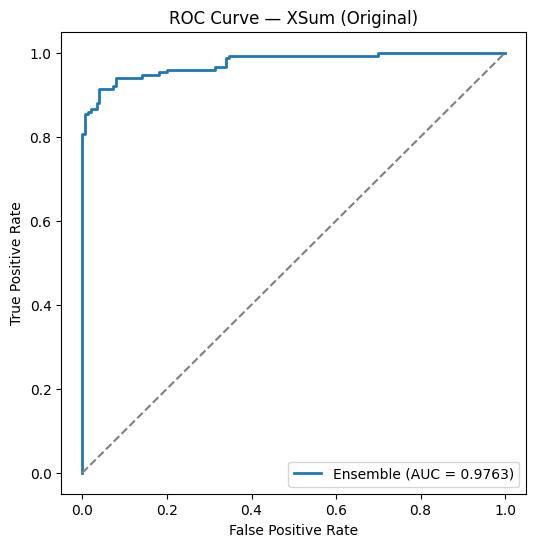

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def get_scores(path):
    with open(path) as f:
        d = json.load(f)
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(s):
    s = np.array(s)
    return (s - s.min()) / (s.max() - s.min())

lh, ll = get_scores('/content/drive/MyDrive/lastde_backup/xsum_gpt2_xl_white_colab.lastde_doubleplus.json')
fh, fl = get_scores('/content/drive/MyDrive/lastde_backup/xsum_gpt2_xl_white_colab.sampling_discrepancy.json')

labels = [0]*150 + [1]*150
ensemble = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2

fpr, tpr, _ = roc_curve(labels, ensemble)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Ensemble (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XSum (Original)')
plt.legend()
plt.savefig('/content/roc_curve_xsum.pdf', bbox_inches='tight')
plt.show()

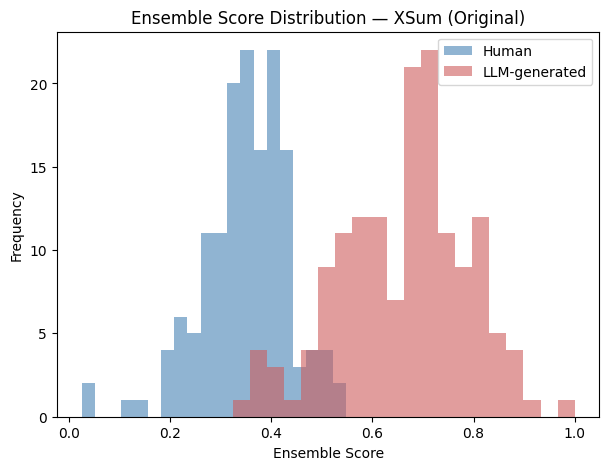

In [ ]:
human_scores = ensemble[:150]
llm_scores = ensemble[150:]

plt.figure(figsize=(7,5))
plt.hist(human_scores, bins=20, alpha=0.6, label='Human', color='steelblue')
plt.hist(llm_scores, bins=20, alpha=0.6, label='LLM-generated', color='indianred')
plt.xlabel('Ensemble Score')
plt.ylabel('Frequency')
plt.title('Ensemble Score Distribution — XSum (Original)')
plt.legend()
plt.savefig('/content/score_distribution_xsum.pdf', bbox_inches='tight')
plt.show()

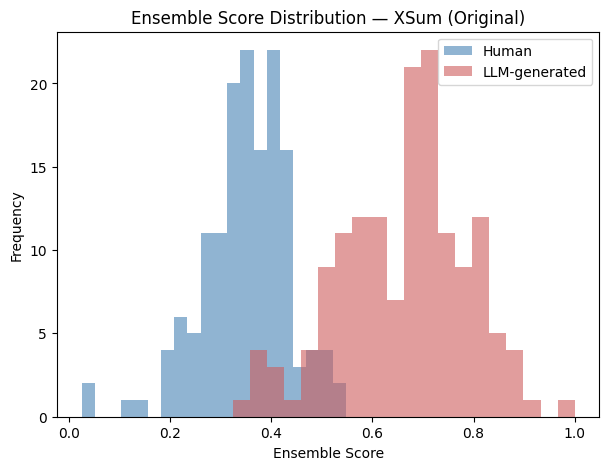

In [ ]:
human_scores = ensemble[:150]
llm_scores = ensemble[150:]

plt.figure(figsize=(7,5))
plt.hist(human_scores, bins=20, alpha=0.6, label='Human', color='steelblue')
plt.hist(llm_scores, bins=20, alpha=0.6, label='LLM-generated', color='indianred')
plt.xlabel('Ensemble Score')
plt.ylabel('Frequency')
plt.title('Ensemble Score Distribution — XSum (Original)')
plt.legend()
plt.savefig('/content/score_distribution_xsum.pdf', bbox_inches='tight')
plt.show()

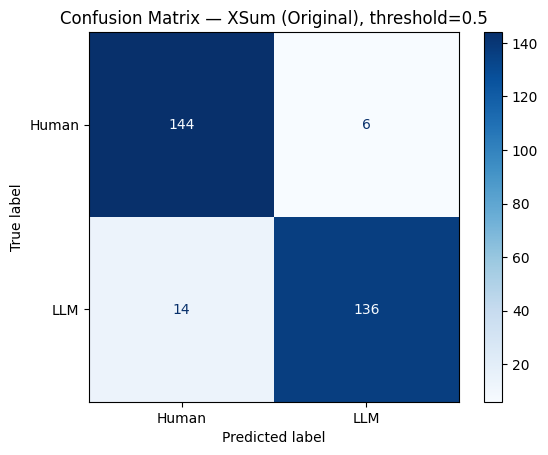

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = (ensemble > 0.5).astype(int)
cm = confusion_matrix(labels, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'LLM'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — XSum (Original), threshold=0.5')
plt.savefig('/content/confusion_matrix_xsum.pdf', bbox_inches='tight')
plt.show()

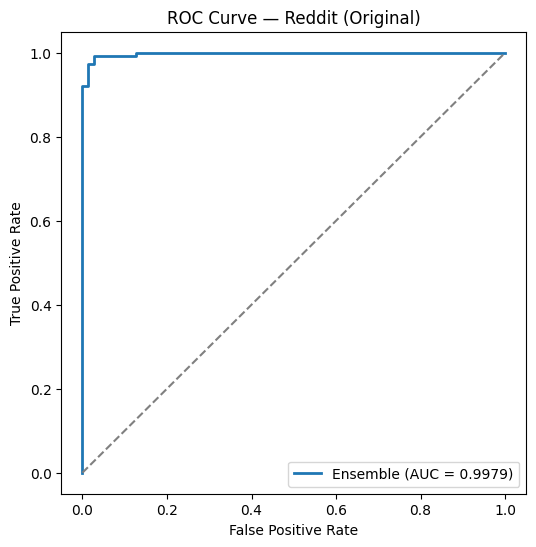

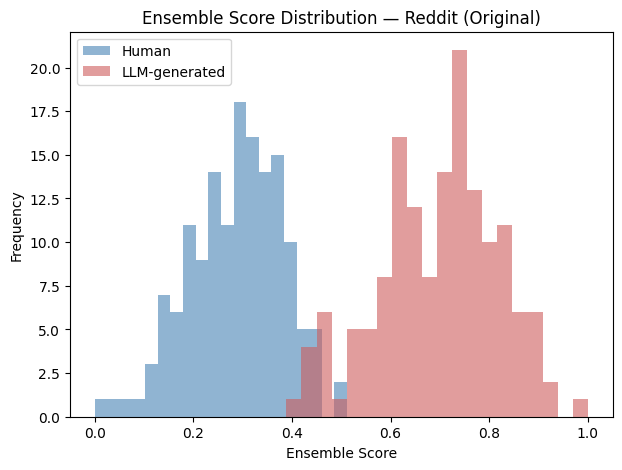

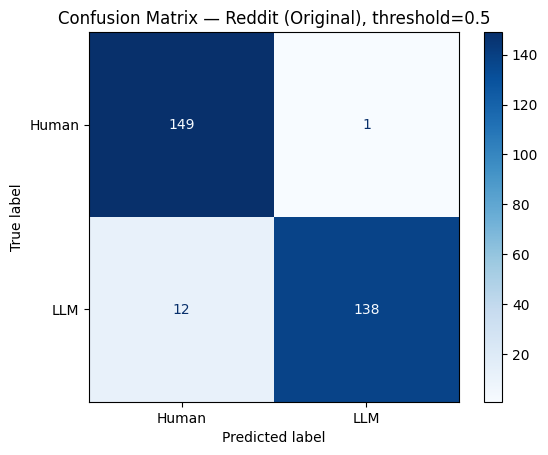

In [ ]:
lh, ll = get_scores('/content/drive/MyDrive/lastde_backup/reddit_gpt2_xl_white_colab.lastde_doubleplus.json')
fh, fl = get_scores('/content/drive/MyDrive/lastde_backup/reddit_gpt2_xl_white_colab.sampling_discrepancy.json')

labels = [0]*150 + [1]*150
ensemble = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2

# ROC curve
fpr, tpr, _ = roc_curve(labels, ensemble)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Ensemble (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Reddit (Original)')
plt.legend()
plt.savefig('/content/roc_curve_reddit.pdf', bbox_inches='tight')
plt.show()

# Score distribution histogram
human_scores = ensemble[:150]
llm_scores = ensemble[150:]

plt.figure(figsize=(7,5))
plt.hist(human_scores, bins=20, alpha=0.6, label='Human', color='steelblue')
plt.hist(llm_scores, bins=20, alpha=0.6, label='LLM-generated', color='indianred')
plt.xlabel('Ensemble Score')
plt.ylabel('Frequency')
plt.title('Ensemble Score Distribution — Reddit (Original)')
plt.legend()
plt.savefig('/content/score_distribution_reddit.pdf', bbox_inches='tight')
plt.show()

# Confusion matrix
predictions = (ensemble > 0.5).astype(int)
cm = confusion_matrix(labels, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'LLM'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Reddit (Original), threshold=0.5')
plt.savefig('/content/confusion_matrix_reddit.pdf', bbox_inches='tight')
plt.show()

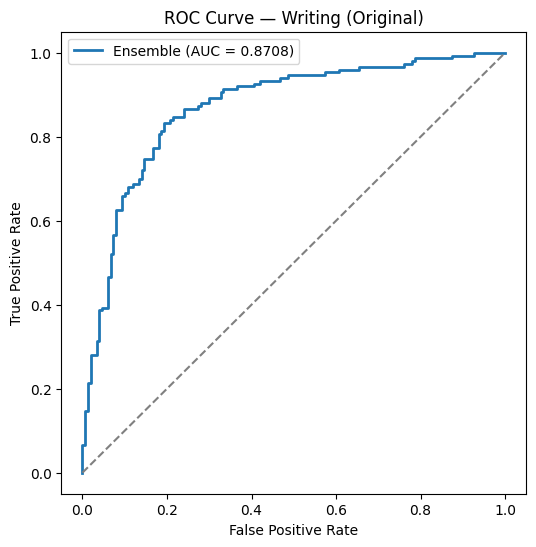

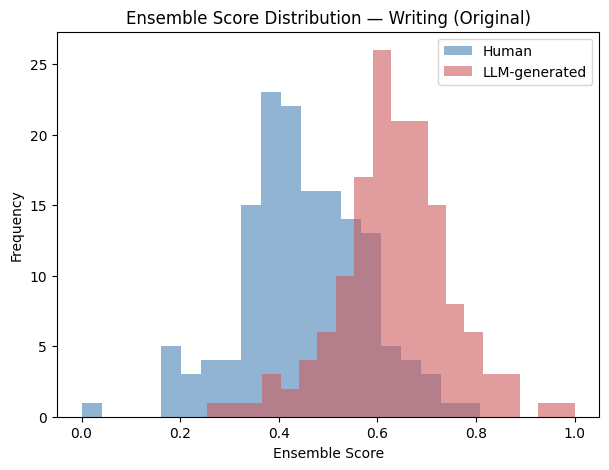

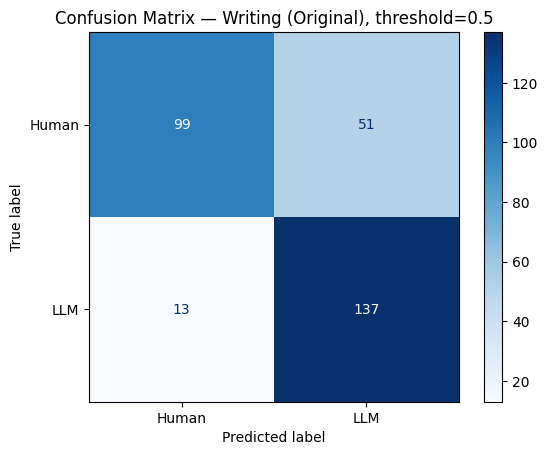

In [ ]:
lh, ll = get_scores('/content/drive/MyDrive/lastde_backup/writing_gpt2_xl_white_colab.lastde_doubleplus.json')
fh, fl = get_scores('/content/drive/MyDrive/lastde_backup/writing_gpt2_xl_white_colab.sampling_discrepancy.json')

labels = [0]*150 + [1]*150
ensemble = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2

# ROC curve
fpr, tpr, _ = roc_curve(labels, ensemble)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Ensemble (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Writing (Original)')
plt.legend()
plt.savefig('/content/roc_curve_writing.pdf', bbox_inches='tight')
plt.show()

# Score distribution histogram
human_scores = ensemble[:150]
llm_scores = ensemble[150:]

plt.figure(figsize=(7,5))
plt.hist(human_scores, bins=20, alpha=0.6, label='Human', color='steelblue')
plt.hist(llm_scores, bins=20, alpha=0.6, label='LLM-generated', color='indianred')
plt.xlabel('Ensemble Score')
plt.ylabel('Frequency')
plt.title('Ensemble Score Distribution — Writing (Original)')
plt.legend()
plt.savefig('/content/score_distribution_writing.pdf', bbox_inches='tight')
plt.show()

# Confusion matrix
predictions = (ensemble > 0.5).astype(int)
cm = confusion_matrix(labels, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'LLM'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Writing (Original), threshold=0.5')
plt.savefig('/content/confusion_matrix_writing.pdf', bbox_inches='tight')
plt.show()

In [ ]:
lh, ll = get_scores('/content/drive/MyDrive/lastde_backup/hlpc_xsum_gpt2_xl_white_colab.lastde_doubleplus.json')
fh, fl = get_scores('/content/drive/MyDrive/lastde_backup/hlpc_xsum_gpt2_xl_white_colab.sampling_discrepancy.json')

print(f"Lastde++ human count: {len(lh)}")
print(f"Lastde++ LLM count:   {len(ll)}")
print(f"Fast-DetectGPT human count: {len(fh)}")
print(f"Fast-DetectGPT LLM count:   {len(fl)}")

Lastde++ human count: 150
Lastde++ LLM count:   150
Fast-DetectGPT human count: 150
Fast-DetectGPT LLM count:   150


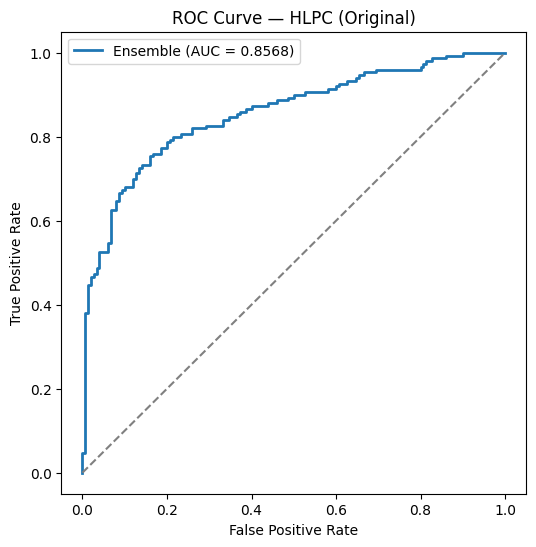

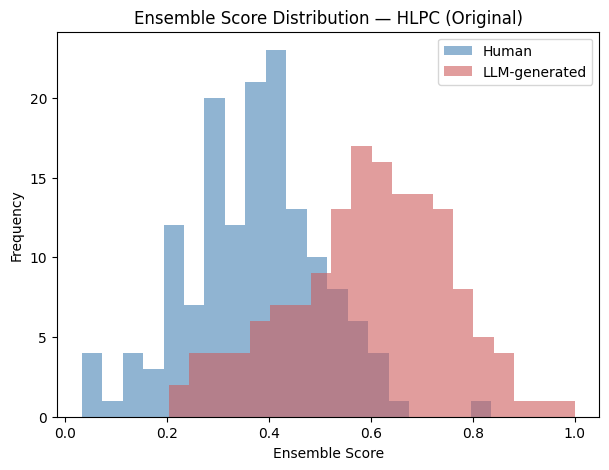

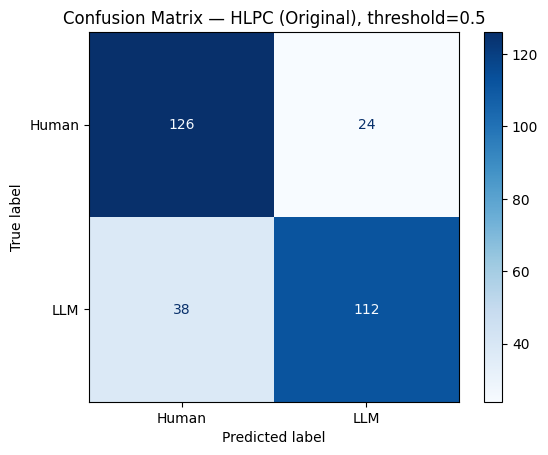

In [ ]:
lh, ll = get_scores('/content/drive/MyDrive/lastde_backup/hlpc_xsum_gpt2_xl_white_colab.lastde_doubleplus.json')
fh, fl = get_scores('/content/drive/MyDrive/lastde_backup/hlpc_xsum_gpt2_xl_white_colab.sampling_discrepancy.json')

labels = [0]*150 + [1]*150
ensemble = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2

# ROC curve
fpr, tpr, _ = roc_curve(labels, ensemble)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Ensemble (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — HLPC (Original)')
plt.legend()
plt.savefig('/content/roc_curve_hlpc.pdf', bbox_inches='tight')
plt.show()

# Score distribution histogram
human_scores = ensemble[:150]
llm_scores = ensemble[150:]

plt.figure(figsize=(7,5))
plt.hist(human_scores, bins=20, alpha=0.6, label='Human', color='steelblue')
plt.hist(llm_scores, bins=20, alpha=0.6, label='LLM-generated', color='indianred')
plt.xlabel('Ensemble Score')
plt.ylabel('Frequency')
plt.title('Ensemble Score Distribution — HLPC (Original)')
plt.legend()
plt.savefig('/content/score_distribution_hlpc.pdf', bbox_inches='tight')
plt.show()

# Confusion matrix
predictions = (ensemble > 0.5).astype(int)
cm = confusion_matrix(labels, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'LLM'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — HLPC (Original), threshold=0.5')
plt.savefig('/content/confusion_matrix_hlpc.pdf', bbox_inches='tight')
plt.show()

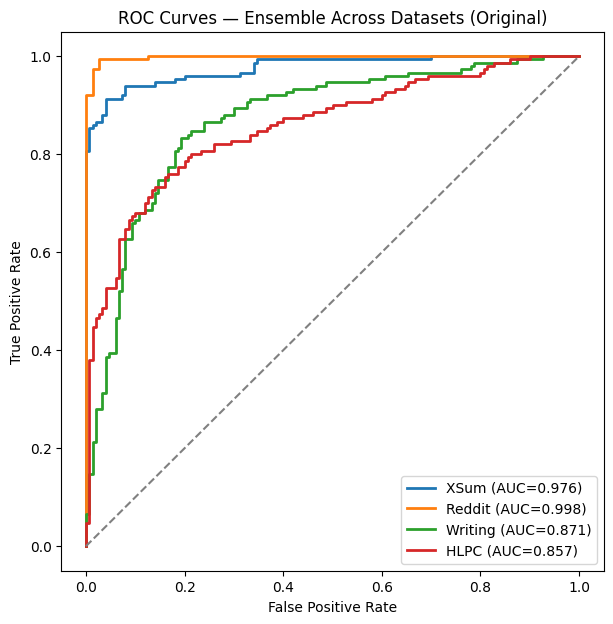

In [ ]:
plt.figure(figsize=(7,7))
for label, lastde_file, fdgpt_file in [
    ('XSum', 'xsum_gpt2_xl_white_colab', 'xsum_gpt2_xl_white_colab'),
    ('Reddit', 'reddit_gpt2_xl_white_colab', 'reddit_gpt2_xl_white_colab'),
    ('Writing', 'writing_gpt2_xl_white_colab', 'writing_gpt2_xl_white_colab'),
    ('HLPC', 'hlpc_xsum_gpt2_xl_white_colab', 'hlpc_xsum_gpt2_xl_white_colab'),
]:
    lh, ll = get_scores(f'/content/drive/MyDrive/lastde_backup/{lastde_file}.lastde_doubleplus.json')
    fh, fl = get_scores(f'/content/drive/MyDrive/lastde_backup/{fdgpt_file}.sampling_discrepancy.json')
    n = len(lh)
    labs = [0]*n + [1]*n
    ens = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2
    fpr, tpr, _ = roc_curve(labs, ens)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC={roc_auc:.3f})', linewidth=2)

plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Ensemble Across Datasets (Original)')
plt.legend()
plt.savefig('/content/roc_curve_combined.pdf', bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
backup_dir = '/content/drive/MyDrive/lastde_backup'
print(f"Backup folder exists: {os.path.exists(backup_dir)}")

if os.path.exists(backup_dir):
    print("\nContents:")
    for f in sorted(os.listdir(backup_dir)):
        print(f"  {f}")

Mounted at /content/drive
Backup folder exists: True

Contents:
  detectrl_arxiv_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_arxiv_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_length120_colab.lastde_doubleplus.json
  detectrl_length120_colab.sampling_discrepancy.json
  detectrl_length20_colab.sampling_discrepancy.json
  detectrl_length60_colab.lastde_doubleplus.json
  detectrl_length60_colab.sampling_discrepancy.json
  detectrl_paraphrased_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_paraphrased_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_writingprompt_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_writingprompt_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_xsum_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_xsum_gpt2_xl_colab.sampling_discrepancy.json
  detectrl_yelp_gpt2_xl_colab.lastde_doubleplus.json
  detectrl_yelp_gpt2_xl_colab.sampling_discrepancy.json
  evobench_harmful_claude_colab.sampling_discrepancy.json
  evobench_harmful_claude_filtered_colab.la

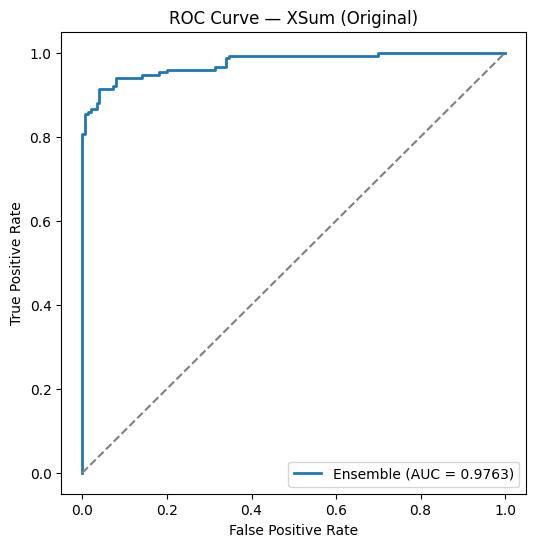

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def get_scores(path):
    with open(path) as f:
        d = json.load(f)
    r = d['raw_results']
    return [x['original_crit'] for x in r], [x['sampled_crit'] for x in r]

def norm(s):
    s = np.array(s)
    return (s - s.min()) / (s.max() - s.min())

lh, ll = get_scores('/content/drive/MyDrive/lastde_backup/xsum_gpt2_xl_white_colab.lastde_doubleplus.json')
fh, fl = get_scores('/content/drive/MyDrive/lastde_backup/xsum_gpt2_xl_white_colab.sampling_discrepancy.json')

labels = [0]*150 + [1]*150
ensemble = (norm(np.array(lh+ll)) + norm(np.array(fh+fl))) / 2

fpr, tpr, _ = roc_curve(labels, ensemble)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Ensemble (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XSum (Original)')
plt.legend()
plt.savefig('/content/roc_curve_xsum.pdf', bbox_inches='tight')
plt.show()

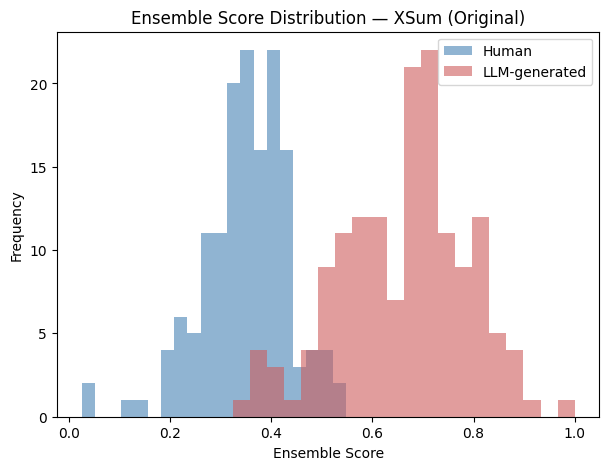

In [ ]:
human_scores = ensemble[:150]
llm_scores = ensemble[150:]

plt.figure(figsize=(7,5))
plt.hist(human_scores, bins=20, alpha=0.6, label='Human', color='steelblue')
plt.hist(llm_scores, bins=20, alpha=0.6, label='LLM-generated', color='indianred')
plt.xlabel('Ensemble Score')
plt.ylabel('Frequency')
plt.title('Ensemble Score Distribution — XSum (Original)')
plt.legend()
plt.savefig('/content/score_distribution_xsum.pdf', bbox_inches='tight')
plt.show()

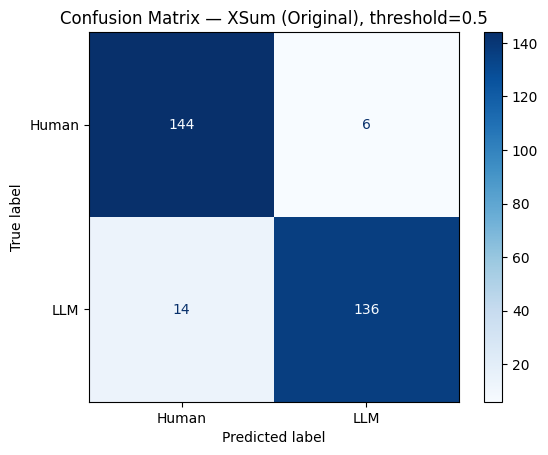

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = (ensemble > 0.5).astype(int)
cm = confusion_matrix(labels, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'LLM'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — XSum (Original), threshold=0.5')
plt.savefig('/content/confusion_matrix_xsum.pdf', bbox_inches='tight')
plt.show()

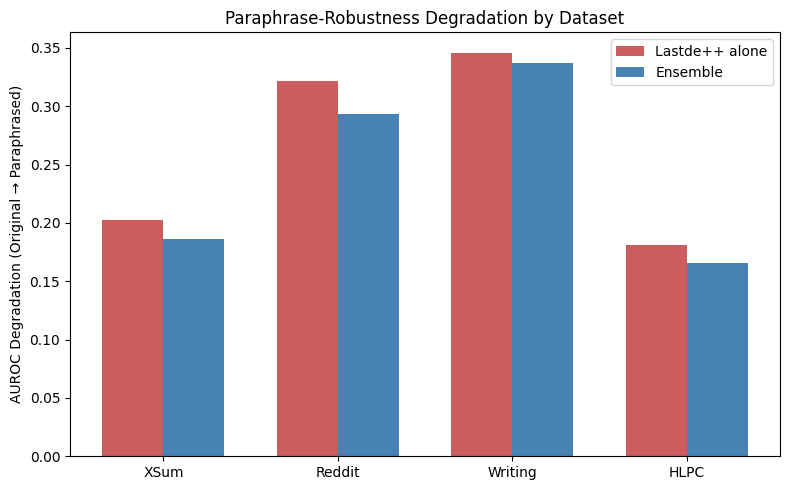

Delta values:
  XSum: Lastde++ Δ=0.2026, Ensemble Δ=0.1859
  Reddit: Lastde++ Δ=0.3216, Ensemble Δ=0.2936
  Writing: Lastde++ Δ=0.3460, Ensemble Δ=0.3372
  HLPC: Lastde++ Δ=0.1808, Ensemble Δ=0.1656


In [ ]:
# Using verified numbers from your Results table (only datasets with true original/paraphrased pairs)
datasets = ['XSum', 'Reddit', 'Writing', 'HLPC']
lastde_orig = [0.9589, 0.9955, 0.8869, 0.8021]
lastde_para = [0.7563, 0.6739, 0.5409, 0.6213]
ensemble_orig = [0.9763, 0.9979, 0.8708, 0.8568]
ensemble_para = [0.7904, 0.7043, 0.5336, 0.6912]

lastde_delta = [o - p for o, p in zip(lastde_orig, lastde_para)]
ensemble_delta = [o - p for o, p in zip(ensemble_orig, ensemble_para)]

x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, lastde_delta, width, label='Lastde++ alone', color='indianred')
plt.bar(x + width/2, ensemble_delta, width, label='Ensemble', color='steelblue')
plt.xticks(x, datasets)
plt.ylabel('AUROC Degradation (Original → Paraphrased)')
plt.title('Paraphrase-Robustness Degradation by Dataset')
plt.legend()
plt.tight_layout()
plt.savefig('/content/degradation_delta_chart.pdf', bbox_inches='tight')
plt.show()

print("Delta values:")
for d, ld, ed in zip(datasets, lastde_delta, ensemble_delta):
    print(f"  {d}: Lastde++ Δ={ld:.4f}, Ensemble Δ={ed:.4f}")

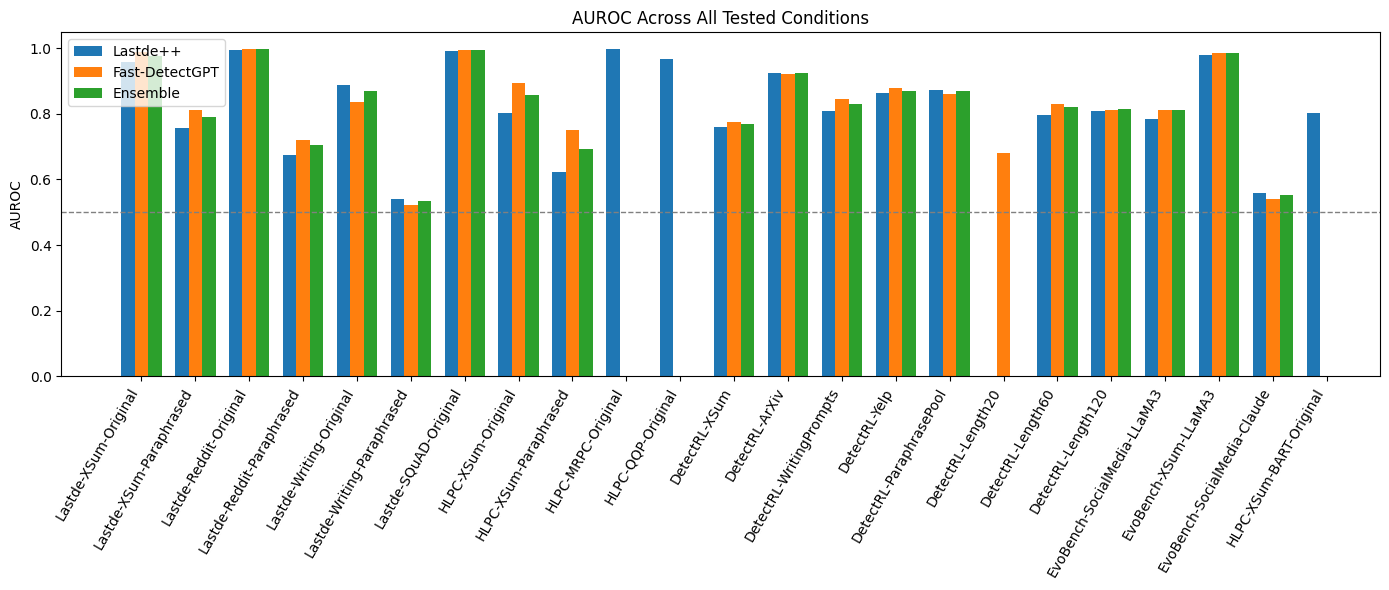

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/lastde_backup/results_summary.csv')
df_numeric = df[df['Ensemble AUROC'] != 'N/A'].copy()
df_numeric['Ensemble AUROC'] = df_numeric['Ensemble AUROC'].astype(float)
df_numeric['Lastde++ AUROC'] = pd.to_numeric(df_numeric['Lastde++ AUROC'], errors='coerce')
df_numeric['Fast-DetectGPT AUROC'] = pd.to_numeric(df_numeric['Fast-DetectGPT AUROC'], errors='coerce')

fig, ax = plt.subplots(figsize=(14,6))
x = np.arange(len(df_numeric))
width = 0.25

ax.bar(x - width, df_numeric['Lastde++ AUROC'], width, label='Lastde++')
ax.bar(x, df_numeric['Fast-DetectGPT AUROC'], width, label='Fast-DetectGPT')
ax.bar(x + width, df_numeric['Ensemble AUROC'], width, label='Ensemble')

ax.set_xticks(x)
ax.set_xticklabels(df_numeric['Condition'], rotation=60, ha='right')
ax.set_ylabel('AUROC')
ax.set_title('AUROC Across All Tested Conditions')
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('/content/overall_auroc_summary.pdf', bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files

figure_files = [
    'roc_curve_xsum.pdf',
    'score_distribution_xsum.pdf',
    'confusion_matrix_xsum.pdf',
    'degradation_delta_chart.pdf',
    'overall_auroc_summary.pdf'
]

for f in figure_files:
    files.download(f'/content/{f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "figure.dpi": 300,
    "savefig.dpi": 300
})

def get_scores(path):
    with open(path) as f:
        d = json.load(f)
    r = d["raw_results"]
    return (
        [x["original_crit"] for x in r],
        [x["sampled_crit"] for x in r]
    )

def normalize(x):
    x = np.asarray(x)
    return (x - x.min()) / (x.max() - x.min())

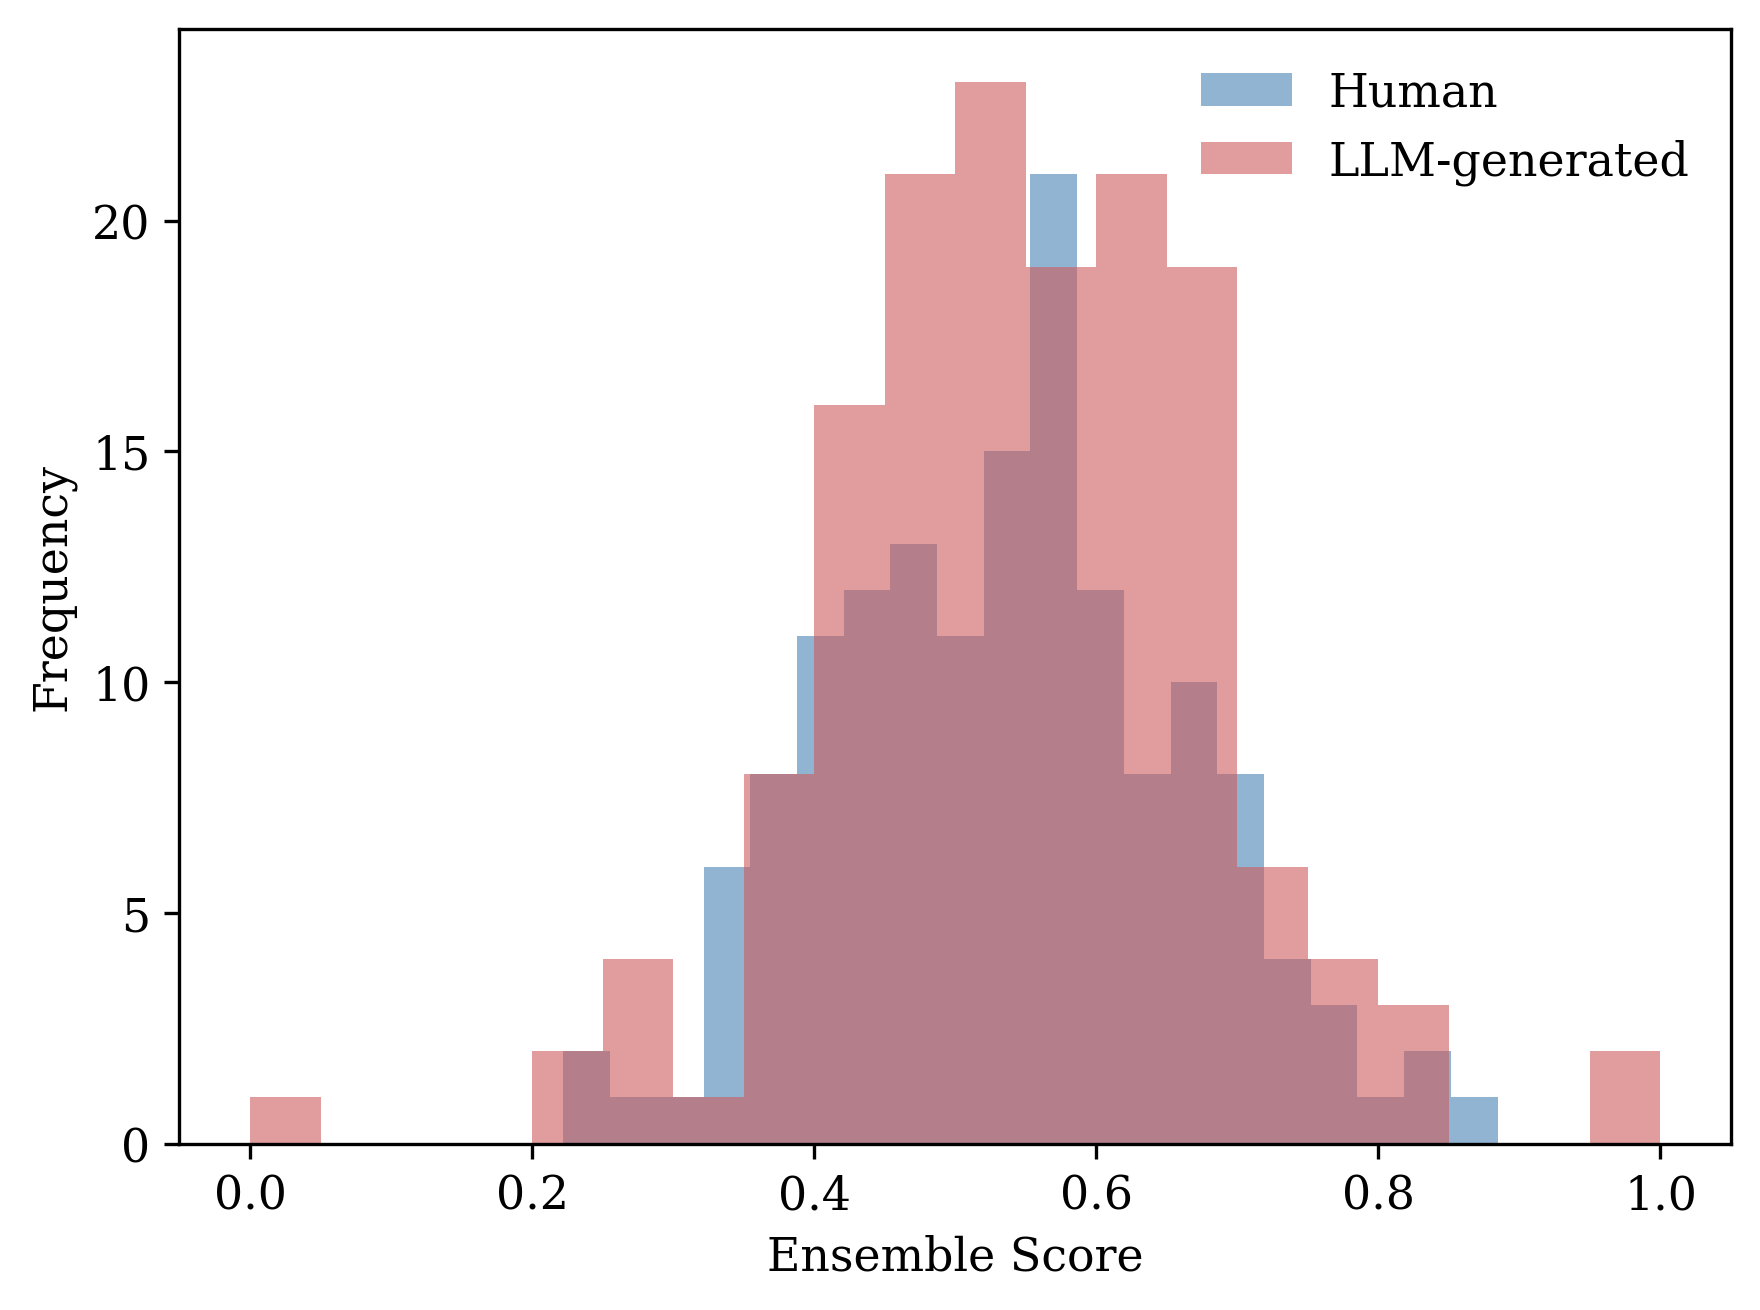

In [ ]:
base = "/content/drive/MyDrive/lastde_backup"

lastde_human, lastde_llm = get_scores(
    f"{base}/writing_gpt2_xl_paraphrased_colab.lastde_doubleplus.json"
)

fdgpt_human, fdgpt_llm = get_scores(
    f"{base}/writing_gpt2_xl_paraphrased_colab.sampling_discrepancy.json"
)

lastde_scores = normalize(np.array(lastde_human + lastde_llm))
fdgpt_scores = normalize(np.array(fdgpt_human + fdgpt_llm))

ensemble_scores = (lastde_scores + fdgpt_scores) / 2

n = len(lastde_human)

human_scores = ensemble_scores[:n]
llm_scores = ensemble_scores[n:]

plt.figure(figsize=(6,4.5))

plt.hist(
    human_scores,
    bins=20,
    alpha=0.6,
    label="Human",
    color="steelblue"
)

plt.hist(
    llm_scores,
    bins=20,
    alpha=0.6,
    label="LLM-generated",
    color="indianred"
)

plt.xlabel("Ensemble Score")
plt.ylabel("Frequency")
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "/content/score_distribution_writing_paraphrased.pdf",
    bbox_inches="tight"
)

plt.show()

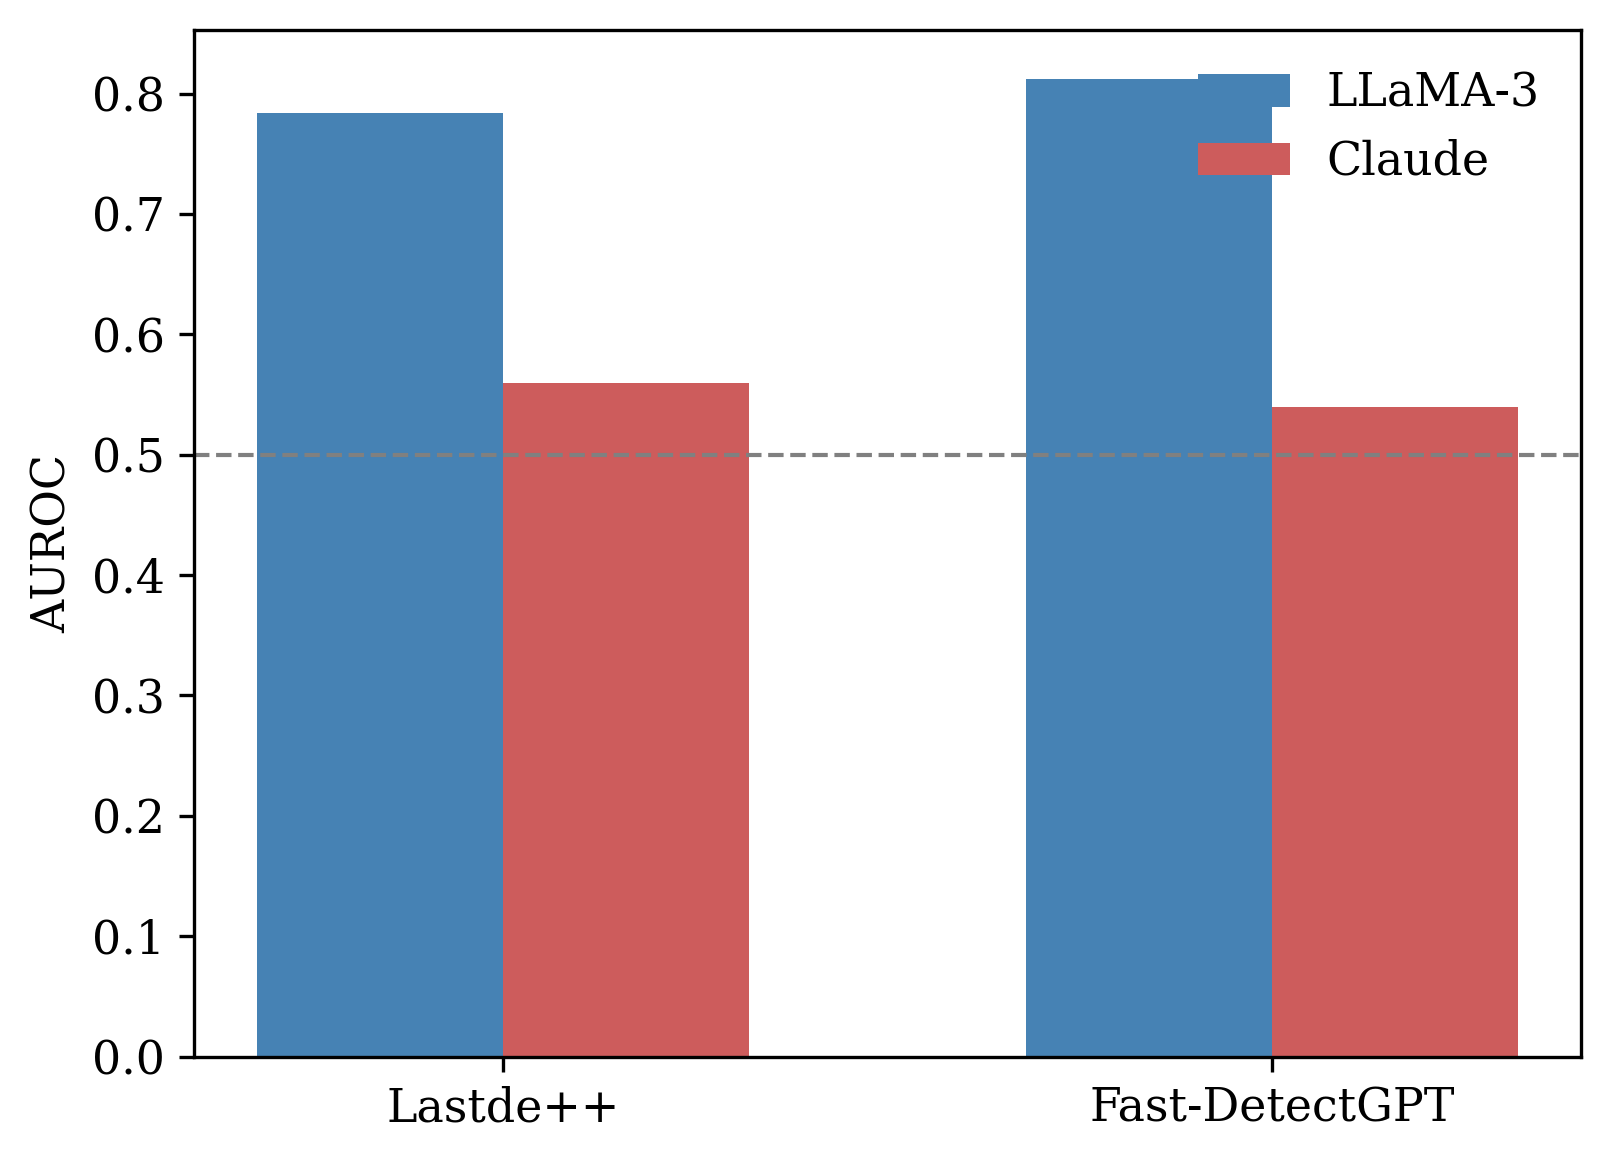

In [ ]:
base = "/content/drive/MyDrive/lastde_backup"

# LLaMA-3
lastde_human_l, lastde_llm_l = get_scores(
    f"{base}/evobench_harmful_filtered_colab.lastde_doubleplus.json"
)

fdgpt_human_l, fdgpt_llm_l = get_scores(
    f"{base}/evobench_harmful_filtered_colab.sampling_discrepancy.json"
)

labels_l = [0] * len(lastde_human_l) + [1] * len(lastde_llm_l)

auroc_lastde_llama = roc_auc_score(
    labels_l,
    lastde_human_l + lastde_llm_l
)

auroc_fdgpt_llama = roc_auc_score(
    labels_l,
    fdgpt_human_l + fdgpt_llm_l
)

# Claude
lastde_human_c, lastde_llm_c = get_scores(
    f"{base}/evobench_harmful_claude_filtered_colab.lastde_doubleplus.json"
)

fdgpt_human_c, fdgpt_llm_c = get_scores(
    f"{base}/evobench_harmful_claude_filtered_colab.sampling_discrepancy.json"
)

labels_c = [0] * len(lastde_human_c) + [1] * len(lastde_llm_c)

auroc_lastde_claude = roc_auc_score(
    labels_c,
    lastde_human_c + lastde_llm_c
)

auroc_fdgpt_claude = roc_auc_score(
    labels_c,
    fdgpt_human_c + fdgpt_llm_c
)

methods = ["Lastde++", "Fast-DetectGPT"]

llama_scores = [
    auroc_lastde_llama,
    auroc_fdgpt_llama
]

claude_scores = [
    auroc_lastde_claude,
    auroc_fdgpt_claude
]

x = np.arange(len(methods))
width = 0.32

plt.figure(figsize=(5.5, 4))

plt.bar(
    x - width/2,
    llama_scores,
    width,
    label="LLaMA-3",
    color="steelblue"
)

plt.bar(
    x + width/2,
    claude_scores,
    width,
    label="Claude",
    color="indianred"
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    color="gray"
)

plt.xticks(x, methods)
plt.ylabel("AUROC")
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "/content/generator_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "evobench" in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/lastde_backup/evobench_harmful_filtered_colab.lastde_doubleplus.json
/content/drive/MyDrive/lastde_backup/evobench_harmful_filtered_colab.sampling_discrepancy.json
/content/drive/MyDrive/lastde_backup/evobench_harmful_llama3_gpt2_xl_colab.sampling_discrepancy.json
/content/drive/MyDrive/lastde_backup/evobench_xsum_llama3_colab.lastde_doubleplus.json
/content/drive/MyDrive/lastde_backup/evobench_xsum_llama3_colab.sampling_discrepancy.json
/content/drive/MyDrive/lastde_backup/evobench_harmful_claude_colab.sampling_discrepancy.json
/content/drive/MyDrive/lastde_backup/evobench_harmful_claude_filtered_colab.lastde_doubleplus.json
/content/drive/MyDrive/lastde_backup/evobench_harmful_claude_filtered_colab.sampling_discrepancy.json


In [ ]:
from google.colab import files

files.download("/content/score_distribution_writing_paraphrased.pdf")
files.download("/content/generator_comparison.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

path = "/content/drive/MyDrive/lastde_backup/evobench_harmful_claude_filtered_colab.lastde_doubleplus.json"

with open(path) as f:
    data = json.load(f)

print(data.keys())

dict_keys(['name', 'info', 'predictions', 'raw_results', 'metrics', 'pr_metrics', 'loss'])


In [ ]:
import json

path = "/content/drive/MyDrive/lastde_backup/evobench_harmful_claude_filtered_colab.lastde_doubleplus.json"

with open(path) as f:
    data = json.load(f)

print(data["info"])

{'n_samples': 146}


In [ ]:
print(data["name"])

lastde_doubleplus_threshold


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

folder = "/content/drive/MyDrive/lastde_backup"

for root, dirs, files in os.walk(folder):
    for file in files:
        print(os.path.join(root, file))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/lastde_backup/xsum_gpt2_xl_white_colab.lastde_doubleplus.json
/content/drive/MyDrive/lastde_backup/xsum_gpt2_xl_white_colab.sampling_discrepancy.json
/content/drive/MyDrive/lastde_backup/paraphrased_xsum_300.json
/content/drive/MyDrive/lastde_backup/xsum_gpt2_xl_paraphrased_colab.lastde_doubleplus.json
/content/drive/MyDrive/lastde_backup/xsum_gpt2_xl_paraphrased_colab.sampling_discrepancy.json
/content/drive/MyDrive/lastde_backup/reddit_gpt2_xl_white_colab.lastde_doubleplus.json
/content/drive/MyDrive/lastde_backup/reddit_gpt2_xl_white_colab.sampling_discrepancy.json
/content/drive/MyDrive/lastde_backup/paraphrased_reddit_300.json
/content/drive/MyDrive/lastde_backup/reddit_gpt2_xl_paraphrased_colab.lastde_doubleplus.json
/content/drive/MyDrive/lastde_backup/reddit_gpt2_xl_paraphrased_colab.sampling_discrepancy.json
/content/drive/MyDr

In [ ]:
import json

file = "/content/drive/MyDrive/lastde_backup/xsum_gpt2_xl_white_colab.lastde_doubleplus.json"

with open(file, "r") as f:
    data = json.load(f)

print(type(data))

if isinstance(data, dict):
    print("Keys:", data.keys())
    print("\nFirst item/value:")
    for k, v in data.items():
        print(k, "=>", str(v)[:500])
        break

elif isinstance(data, list):
    print("Number of items:", len(data))
    print("\nFirst item:")
    print(data[0])

<class 'dict'>
Keys: dict_keys(['name', 'info', 'predictions', 'raw_results', 'metrics', 'pr_metrics', 'loss'])

First item/value:
name => lastde_doubleplus_threshold


In [ ]:
for key in ["predictions", "raw_results", "metrics", "pr_metrics", "loss"]:
    print("\n" + "="*50)
    print(key)
    print("="*50)

    value = data[key]
    print("Type:", type(value))

    if isinstance(value, dict):
        print("Keys:", value.keys())
    elif isinstance(value, list):
        print("Length:", len(value))
        if len(value) > 0:
            print("First item:", value[0])
    else:
        print("Value:", str(value)[:1000])


predictions
Type: <class 'dict'>
Keys: dict_keys(['real', 'samples'])

raw_results
Type: <class 'list'>
Length: 150
First item: {'original': 'Spain\'s Christmas lottery, known as "El Gordo" or "the fat one", is a national event. It has been going since 1812 and an estimated three-quarters of Spaniards and thousands of foreigners play each year. The odds are good - around a million people walk away with cash prizes - and El Gordo is the world\'s biggest lottery in financial terms. It handed out 2.5bn euros last Christmas. Unlike other lotteries, players do not choose numbers. They buy a ticket with a 5-digit number on and anyone who has that ticket when the the numbers are called - or, more accurately,sung out by schoolchildrenat a televised event in Madrid - wins a share of the prize. Because of the nature of the system, tickets in a series are often sold by the same vendor, meaning the winners usually come from the same towns. The draw is always held just before Christmas to offer pe

In [ ]:
print("=== predictions['real'] ===")
print(type(data["predictions"]["real"]))
print(str(data["predictions"]["real"])[:2000])

print("\n=== predictions['samples'] ===")
print(type(data["predictions"]["samples"]))
print(str(data["predictions"]["samples"])[:2000])

=== predictions['real'] ===
<class 'list'>
[0.4024088382720947, 0.5359394550323486, 1.2953240871429443, 0.4299298822879791, 0.7366131544113159, -1.0154255628585815, 0.7089047431945801, 1.341126561164856, -1.1026248931884766, 2.4931716918945312, 0.43250611424446106, -0.37990495562553406, 0.277529239654541, -0.3197936713695526, 1.0654414892196655, 0.11103271692991257, -0.823091447353363, 0.2877560257911682, -1.2398862838745117, 0.31009557843208313, 1.1767771244049072, 2.7137444019317627, 1.015092134475708, -0.6535904407501221, -0.4311146140098572, 1.250502347946167, -1.0201822519302368, 0.3047032654285431, 0.3214166462421417, -0.6321697235107422, -0.22330859303474426, -0.04365147650241852, 0.3169393539428711, 0.8124285340309143, 0.17364592850208282, -0.9858818650245667, 0.5769719481468201, 1.2028104066848755, 1.0234920978546143, 0.1578536331653595, 1.1692503690719604, -0.44766172766685486, 1.7069169282913208, 0.4827900826931, 0.3828974962234497, 1.1444758176803589, -1.0121400356292725, 0

In [ ]:
import json

path = "/content/drive/MyDrive/lastde_backup/xsum_gpt2_xl_white_colab.lastde_doubleplus.json"

with open(path, "r") as f:
    data = json.load(f)

print("=== Saved metrics ===")
print(data["metrics"])

print("\n=== Saved PR metrics ===")
print(data["pr_metrics"])

print("\n=== Score information ===")
real = data["predictions"]["real"]
samples = data["predictions"]["samples"]

print("Human samples:", len(real))
print("LLM samples:", len(samples))

print("Human score range:", min(real), "to", max(real))
print("LLM score range:", min(samples), "to", max(samples))

=== Saved metrics ===
{'roc_auc': 0.9588888888888889, 'fpr': [0.0, 0.0, 0.0, 0.013333333333333334, 0.013333333333333334, 0.02, 0.02, 0.04, 0.04, 0.04666666666666667, 0.04666666666666667, 0.05333333333333334, 0.05333333333333334, 0.06, 0.06, 0.06666666666666667, 0.06666666666666667, 0.09333333333333334, 0.09333333333333334, 0.23333333333333334, 0.23333333333333334, 0.24666666666666667, 0.24666666666666667, 0.25333333333333335, 0.25333333333333335, 0.34, 0.34, 0.41333333333333333, 0.41333333333333333, 0.4666666666666667, 0.4666666666666667, 0.54, 0.54, 0.5866666666666667, 0.5866666666666667, 0.5933333333333334, 0.5933333333333334, 0.6066666666666667, 0.6066666666666667, 0.8, 0.8, 1.0], 'tpr': [0.0, 0.006666666666666667, 0.72, 0.72, 0.78, 0.78, 0.8133333333333334, 0.8133333333333334, 0.86, 0.86, 0.8866666666666667, 0.8866666666666667, 0.8933333333333333, 0.8933333333333333, 0.9066666666666666, 0.9066666666666666, 0.92, 0.92, 0.9266666666666666, 0.9266666666666666, 0.9333333333333333, 0.93

In [ ]:
import json
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

# --------------------------------------------------
# Load saved Lastde++ result
# --------------------------------------------------

file_path = "/content/drive/MyDrive/lastde_backup/xsum_gpt2_xl_white_colab.lastde_doubleplus.json"

with open(file_path, "r") as f:
    data = json.load(f)

real_scores = np.array(data["predictions"]["real"], dtype=float)
llm_scores = np.array(data["predictions"]["samples"], dtype=float)

# Human = 0
# LLM = 1
y_true = np.concatenate([
    np.zeros(len(real_scores)),
    np.ones(len(llm_scores))
])

scores = np.concatenate([
    real_scores,
    llm_scores
])

print("Human samples:", len(real_scores))
print("LLM samples:", len(llm_scores))
print("Total samples:", len(y_true))

# --------------------------------------------------
# Find threshold that gives the BEST F1
# --------------------------------------------------

thresholds = np.unique(scores)

best_f1 = -1
best_threshold = None
best_precision = None
best_recall = None
best_accuracy = None

for threshold in thresholds:

    # Higher score = more likely LLM
    y_pred = (scores >= threshold).astype(int)

    precision = precision_score(
        y_true, y_pred, zero_division=0
    )

    recall = recall_score(
        y_true, y_pred, zero_division=0
    )

    f1 = f1_score(
        y_true, y_pred, zero_division=0
    )

    accuracy = accuracy_score(
        y_true, y_pred
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_precision = precision
        best_recall = recall
        best_accuracy = accuracy

# --------------------------------------------------
# Results
# --------------------------------------------------

print("\n==============================")
print("BEST THRESHOLD RESULTS")
print("==============================")

print(f"Threshold : {best_threshold:.6f}")
print(f"Precision : {best_precision:.6f}")
print(f"Recall    : {best_recall:.6f}")
print(f"F1 Score  : {best_f1:.6f}")
print(f"Accuracy  : {best_accuracy:.6f}")

# --------------------------------------------------
# Confusion matrix
# --------------------------------------------------

y_pred_best = (scores >= best_threshold).astype(int)

cm = confusion_matrix(y_true, y_pred_best)

print("\nConfusion Matrix:")
print(cm)

print("\nTN =", cm[0, 0])
print("FP =", cm[0, 1])
print("FN =", cm[1, 0])
print("TP =", cm[1, 1])

Human samples: 150
LLM samples: 150
Total samples: 300

BEST THRESHOLD RESULTS
Threshold : 1.685437
Precision : 0.932432
Recall    : 0.920000
F1 Score  : 0.926174
Accuracy  : 0.926667

Confusion Matrix:
[[140  10]
 [ 12 138]]

TN = 140
FP = 10
FN = 12
TP = 138
